In [ ]:
#импортируем необходимые библиотеки для обработки данных
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer


import scipy

In [ ]:
# Названия таблиц и пояснения к ним

# Таблицы с данными (сначала с пропусками, потом заполненные)
#data_healthy
#data_1_stage
#data_2_stage
#data_3_stage

# Объединённая таблица
#data_glaucoma
#data_glaucoma_after_input
#data_glaucoma_all

# Описательная статистика
#describe_data_healthy
#describe_data_1_stage
#describe_data_2_stage
#describe_data_3_stage

# Агрегированная таблица со средними значениями
#table_agg

# Вспомогательная таблица для заполнения медианой
#median_imputer

# Загрузка подготовленной таблицы

In [ ]:
#загружаем имеющиеся данные
excel_reader=pd.ExcelFile('/content/drive/MyDrive/prepare_data.xlsx')

В таблице с данными 4 листа. Выделим их для удобства работы в отдельные таблицы.

In [ ]:
print(excel_reader.sheet_names)

['healthy', '1_stage', '2_stage', '3_stage']


In [ ]:
data_healthy=excel_reader.parse('healthy')

In [ ]:
#data_healthy.head(11)

In [ ]:
data_1_stage=excel_reader.parse('1_stage')

In [ ]:
#data_1_stage

In [ ]:
data_2_stage=excel_reader.parse('2_stage')

In [ ]:
#data_2_stage

In [ ]:
data_3_stage=excel_reader.parse('3_stage')

In [ ]:
#data_3_stage

# Задача 2. Анализ соответствия выборочных данных нормальному распределению

Имеются 4 таблицы данных без пропусков:
- data_healthy - здоровые пациенты
- data_1_stage - больные с 1 стадией
- data_2_stage - больные со 2 стадией
- data_3_stage - больные с 3 стадией



---



In [ ]:
#median_imputer.isnull().sum()

## Здоровые пациенты

Проверим на нормальность данные здоровых пациентов

### Возраст

<ipython-input-455-ebb2d6acb0b8>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['возраст'], hist=True, kde=True,


<Axes: xlabel='возраст', ylabel='Density'>

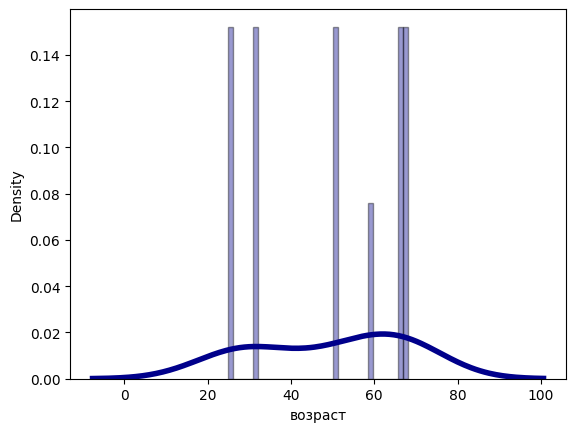

In [ ]:
sns.distplot(data_healthy['возраст'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['возраст']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.846, p-value=0.038
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['возраст']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=4.313, p-value=0.116
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Величина внутриглазного давления

<ipython-input-458-5b15a994553a>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['величина внутриглазного давления'], hist=True, kde=True,


<Axes: xlabel='величина внутриглазного давления', ylabel='Density'>

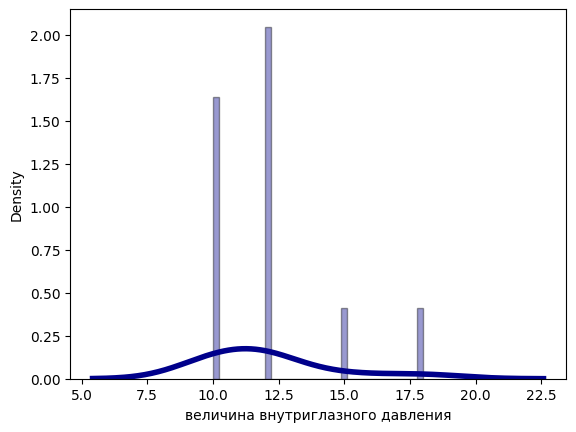

In [ ]:
sns.distplot(data_healthy['величина внутриглазного давления'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['величина внутриглазного давления']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.776, p-value=0.005
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['величина внутриглазного давления']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=8.377, p-value=0.015
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ВГД, корригированного на коэффициент ригидности



<ipython-input-461-78a90380a3c4>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['ВГД, корригированного на коэффициент ригидности'], hist=True, kde=True,


<Axes: xlabel='ВГД, корригированного на коэффициент ригидности', ylabel='Density'>

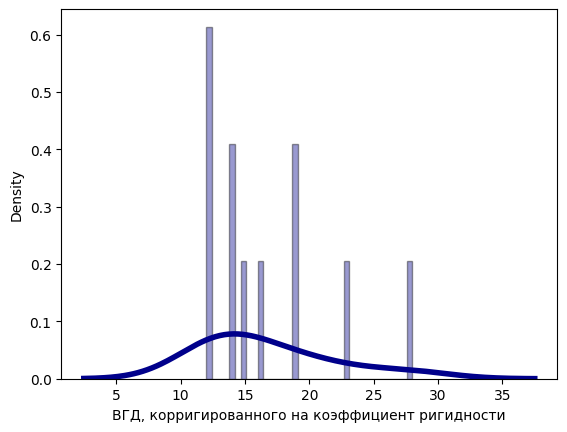

In [ ]:
sns.distplot(data_healthy['ВГД, корригированного на коэффициент ригидности'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['ВГД, корригированного на коэффициент ригидности']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.863, p-value=0.064
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['ВГД, корригированного на коэффициент ригидности']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=4.232, p-value=0.121
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Коэффициент ригидности склеральной капсулы глаза

<ipython-input-464-64e4770e4139>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['Коэфф ригидности склеральн капсулы глаза'], hist=True, kde=True,


<Axes: xlabel='Коэфф ригидности склеральн капсулы глаза', ylabel='Density'>

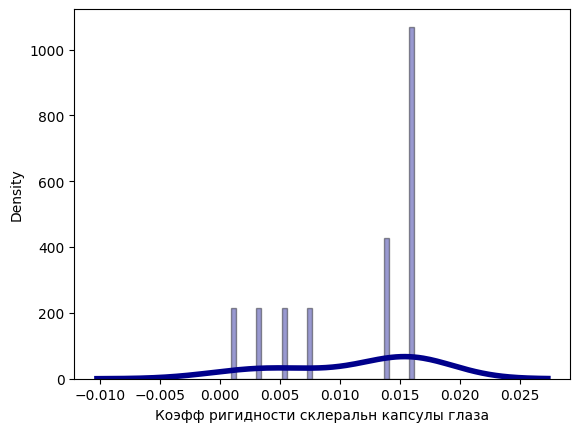

In [ ]:
sns.distplot(data_healthy['Коэфф ригидности склеральн капсулы глаза'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['Коэфф ригидности склеральн капсулы глаза']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.786, p-value=0.006
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['Коэфф ригидности склеральн капсулы глаза']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=2.578, p-value=0.276
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Роговично-компенсированное ВГД

<ipython-input-467-befa02cc5092>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['Роговично-компенсированное ВГД'], hist=True, kde=True,


<Axes: xlabel='Роговично-компенсированное ВГД', ylabel='Density'>

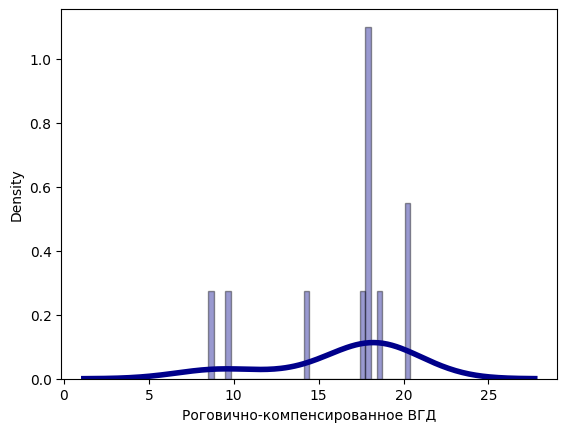

In [ ]:
sns.distplot(data_healthy['Роговично-компенсированное ВГД'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['Роговично-компенсированное ВГД']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.794, p-value=0.008
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['Роговично-компенсированное ВГД']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=4.501, p-value=0.105
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ВГД по Гольдману

<ipython-input-470-6e298cce1d7e>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['ВГД по Гольдману'], hist=True, kde=True,


<Axes: xlabel='ВГД по Гольдману', ylabel='Density'>

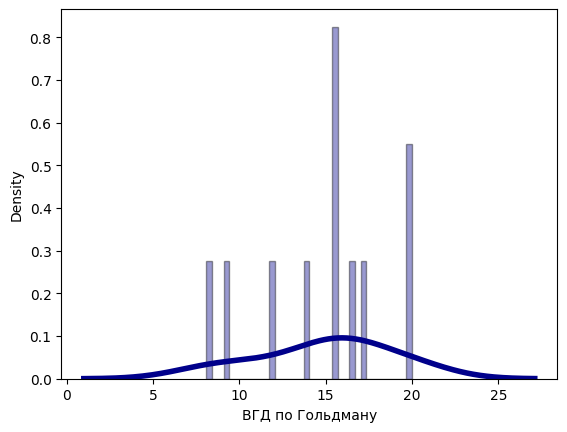

In [ ]:
sns.distplot(data_healthy['ВГД по Гольдману'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['ВГД по Гольдману']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.935, p-value=0.464
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['ВГД по Гольдману']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.616, p-value=0.735
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Фактор резистентности роговицы

<ipython-input-473-f3faa90e4a0f>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['Фактор резистентности роговицы'], hist=True, kde=True,


<Axes: xlabel='Фактор резистентности роговицы', ylabel='Density'>

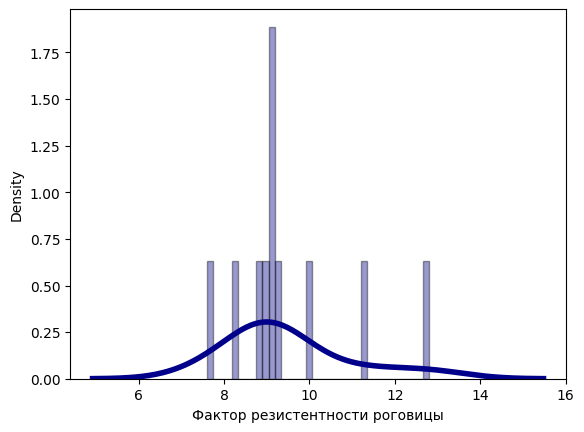

In [ ]:
sns.distplot(data_healthy['Фактор резистентности роговицы'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['Фактор резистентности роговицы']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.862, p-value=0.062
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['Фактор резистентности роговицы']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=6.438, p-value=0.040
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### КГ

<ipython-input-476-2eeb14b2c8ac>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['КГ'], hist=True, kde=True,


<Axes: xlabel='КГ', ylabel='Density'>

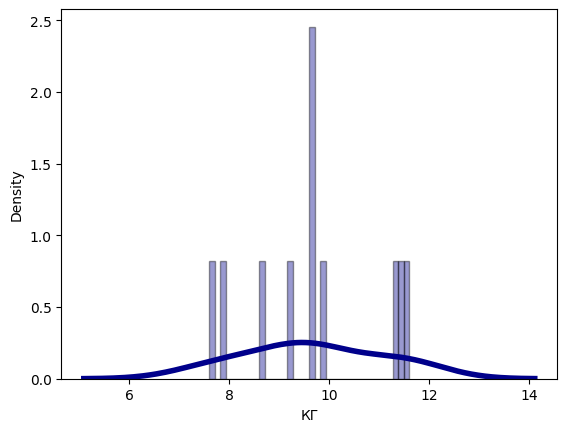

In [ ]:
sns.distplot(data_healthy['КГ'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['КГ']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.927, p-value=0.384
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['КГ']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.457, p-value=0.796
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ЦТР

<ipython-input-479-b97ffbb4affd>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['ЦТР'], hist=True, kde=True,


<Axes: xlabel='ЦТР', ylabel='Density'>

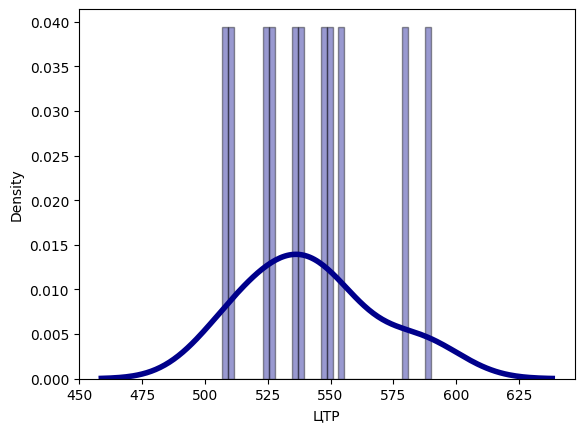

In [ ]:
sns.distplot(data_healthy['ЦТР'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['ЦТР']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.949, p-value=0.627
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['ЦТР']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.820, p-value=0.663
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### РП

<ipython-input-482-b368280d82e9>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['РП'], hist=True, kde=True,


<Axes: xlabel='РП', ylabel='Density'>

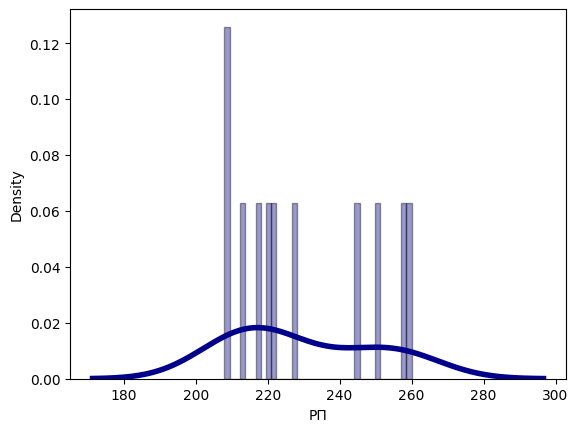

In [ ]:
sns.distplot(data_healthy['РП'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['РП']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.878, p-value=0.099
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['РП']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=2.742, p-value=0.254
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ГлРП

<ipython-input-485-133fe9ebd6ff>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['ГлРП'], hist=True, kde=True,


<Axes: xlabel='ГлРП', ylabel='Density'>

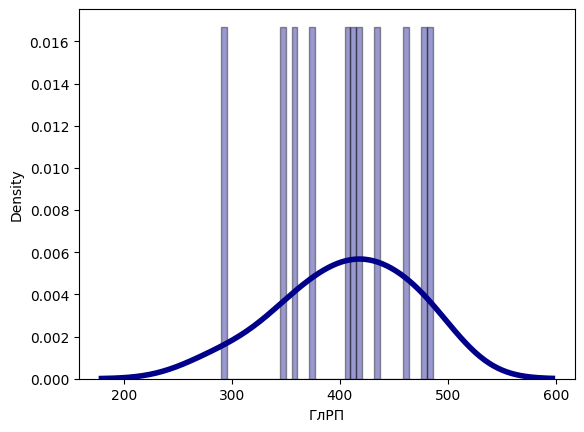

In [ ]:
sns.distplot(data_healthy['ГлРП'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['ГлРП']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.965, p-value=0.837
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['ГлРП']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.604, p-value=0.739
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)


### gamma Ш

<ipython-input-488-9466a507eb48>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['gamma Ш'], hist=True, kde=True,


<Axes: xlabel='gamma Ш', ylabel='Density'>

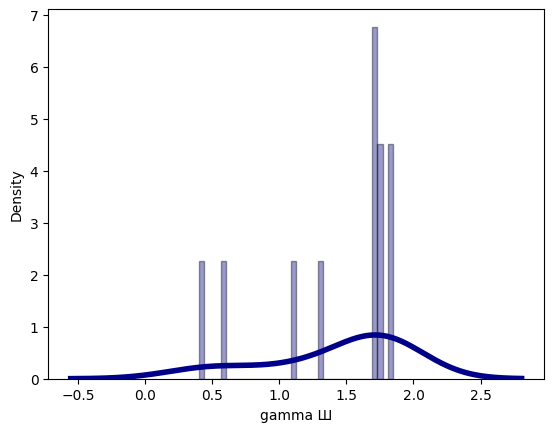

In [ ]:
sns.distplot(data_healthy['gamma Ш'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['gamma Ш']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.780, p-value=0.005
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['gamma Ш']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=3.757, p-value=0.153
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---










---








### Efrid

<ipython-input-491-865001bc625e>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['Efrid'], hist=True, kde=True,


<Axes: xlabel='Efrid', ylabel='Density'>

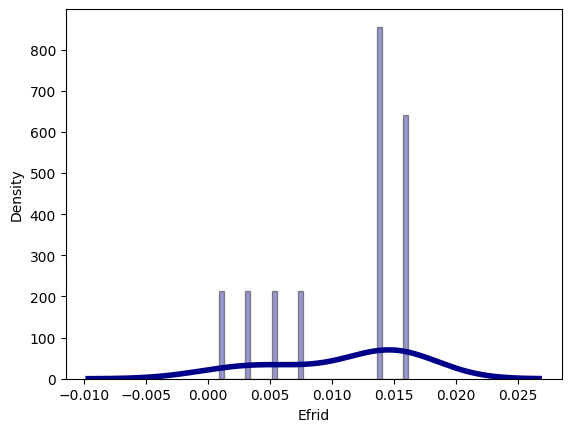

In [ ]:
sns.distplot(data_healthy['Efrid'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['Efrid']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.824, p-value=0.019
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['Efrid']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=2.285, p-value=0.319
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### SVL

<ipython-input-494-c470acd1a761>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['SVL'], hist=True, kde=True,


<Axes: xlabel='SVL', ylabel='Density'>

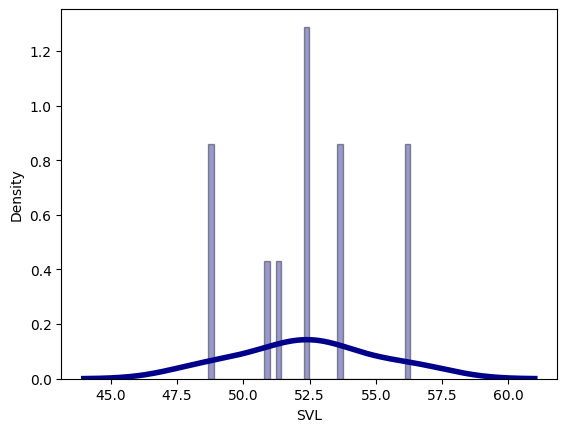

In [ ]:
sns.distplot(data_healthy['SVL'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['SVL']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.928, p-value=0.390
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['SVL']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.026, p-value=0.987
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### DVL

<ipython-input-497-44661ec4f43f>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['DVL'], hist=True, kde=True,


<Axes: xlabel='DVL', ylabel='Density'>

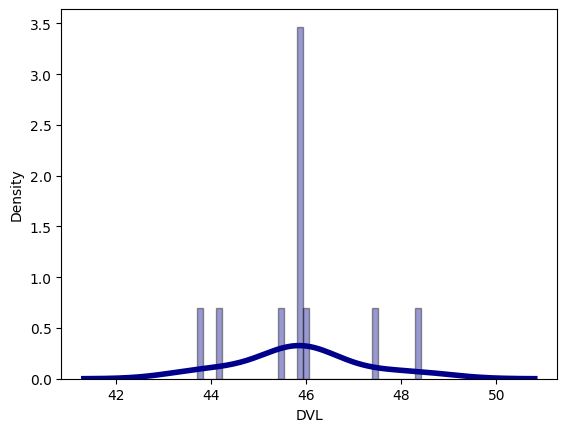

In [ ]:
sns.distplot(data_healthy['DVL'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['DVL']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.889, p-value=0.134
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['DVL']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.123, p-value=0.570
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### РИ (рео. индекс) мОм

<ipython-input-500-f456c3d5f34a>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['РИ (рео.индекс) мОм'], hist=True, kde=True,


<Axes: xlabel='РИ (рео.индекс) мОм', ylabel='Density'>

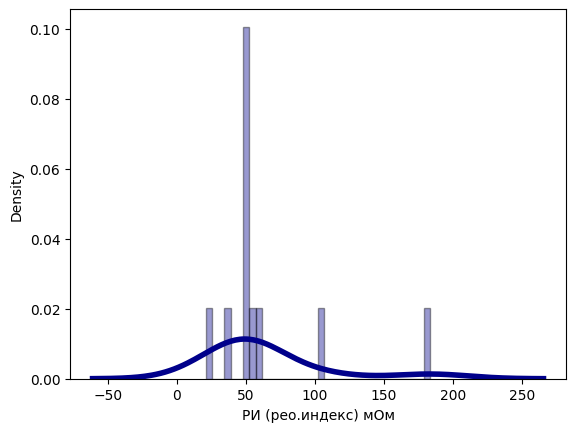

In [ ]:
sns.distplot(data_healthy['РИ (рео.индекс) мОм'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['РИ (рео.индекс) мОм']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.688, p-value=0.000
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['РИ (рео.индекс) мОм']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=17.994, p-value=0.000
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ПМН (макс. нап)

<ipython-input-503-01e54adf4b89>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['ПМН (макс.нап)'], hist=True, kde=True,


<Axes: xlabel='ПМН (макс.нап)', ylabel='Density'>

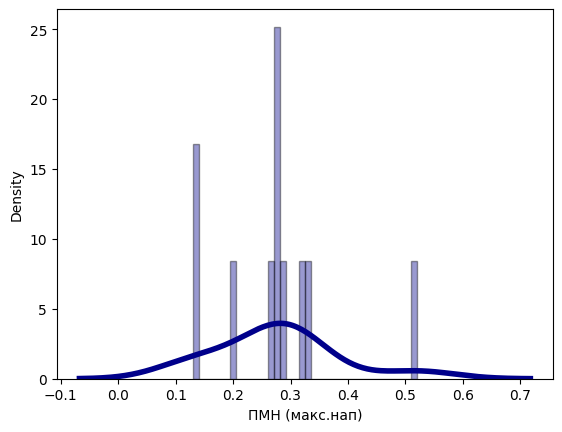

In [ ]:
sns.distplot(data_healthy['ПМН (макс.нап)'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['ПМН (макс.нап)']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.876, p-value=0.092
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['ПМН (макс.нап)']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=4.289, p-value=0.117
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ПМУ (мод.упр.)

<ipython-input-506-ce54ca1341e6>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['ПМУ (мод.упр.)'], hist=True, kde=True,


<Axes: xlabel='ПМУ (мод.упр.)', ylabel='Density'>

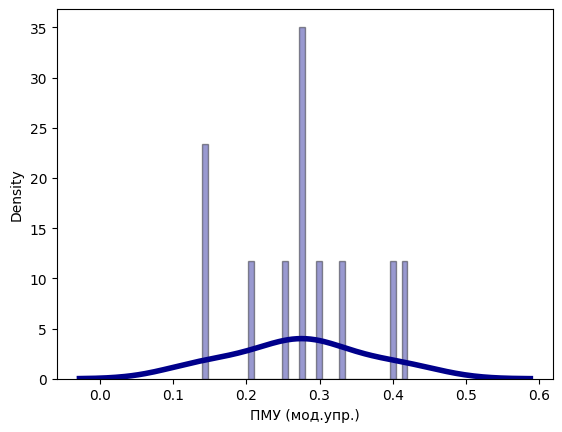

In [ ]:
sns.distplot(data_healthy['ПМУ (мод.упр.)'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['ПМУ (мод.упр.)']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.942, p-value=0.548
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['ПМУ (мод.упр.)']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.018, p-value=0.991
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Z баз. (отн.)

<ipython-input-509-680159cf6938>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['Z баз.(отн.))'], hist=True, kde=True,


<Axes: xlabel='Z баз.(отн.))', ylabel='Density'>

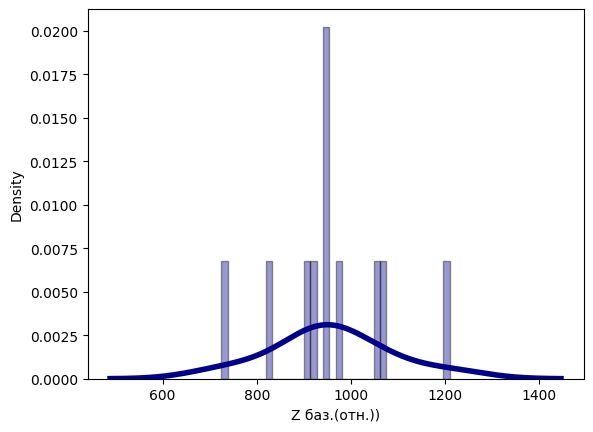

In [ ]:
sns.distplot(data_healthy['Z баз.(отн.))'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['Z баз.(отн.))']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.957, p-value=0.735
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['Z баз.(отн.))']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.052, p-value=0.591
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Z баз. (мОм)

<ipython-input-512-e44658970b6e>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['Z баз.(мОм)'], hist=True, kde=True,


<Axes: xlabel='Z баз.(мОм)', ylabel='Density'>

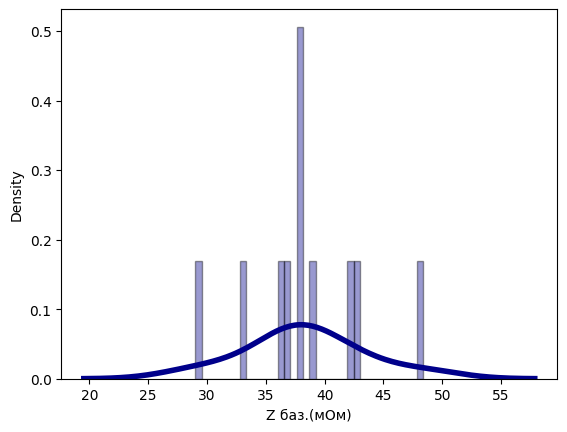

In [ ]:
sns.distplot(data_healthy['Z баз.(мОм)'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['Z баз.(мОм)']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.957, p-value=0.735
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['Z баз.(мОм)']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.052, p-value=0.591
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### УОК (уд. объем) мкл

<ipython-input-515-a99d9b646a94>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_healthy['УОК (уд.объем) мкл'], hist=True, kde=True,


<Axes: xlabel='УОК (уд.объем) мкл', ylabel='Density'>

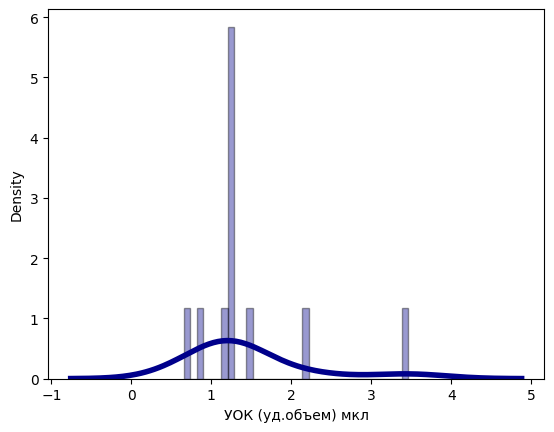

In [ ]:
sns.distplot(data_healthy['УОК (уд.объем) мкл'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_healthy['УОК (уд.объем) мкл']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.741, p-value=0.002
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_healthy['УОК (уд.объем) мкл']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=14.840, p-value=0.001
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=11 observations were given.
  return hypotest_fun_in(*args, **kwds)


## Пациенты с 1й стадией заболевания

Проверим на нормальность данные пациентов с 1й стадией заболевания

### Возраст

<ipython-input-518-a46132ecd4e1>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['возраст'], hist=True, kde=True,


<Axes: xlabel='возраст', ylabel='Density'>

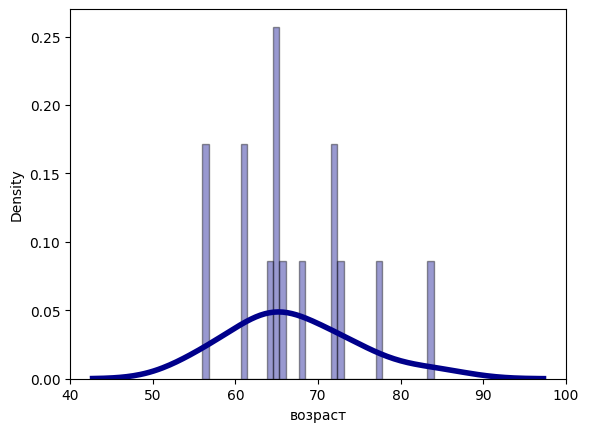

In [ ]:
sns.distplot(data_1_stage['возраст'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['возраст']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.953, p-value=0.569
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['возраст']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.513, p-value=0.469
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Величина внутриглазного давления

<ipython-input-521-de1bb62e6b9a>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['величина внутриглазного давления'], hist=True, kde=True,


<Axes: xlabel='величина внутриглазного давления', ylabel='Density'>

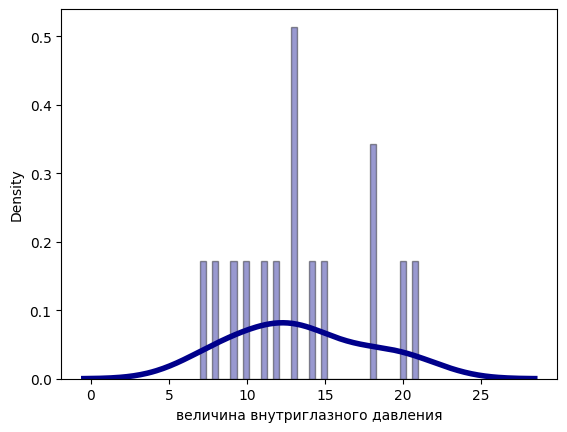

In [ ]:
sns.distplot(data_1_stage['величина внутриглазного давления'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['величина внутриглазного давления']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.957, p-value=0.637
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['величина внутриглазного давления']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.801, p-value=0.670
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ВГД, корригированного на коэффициент ригидности



<ipython-input-524-fb65aa990680>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['ВГД, корригированного на коэффициент ригидности'], hist=True, kde=True,


<Axes: xlabel='ВГД, корригированного на коэффициент ригидности', ylabel='Density'>

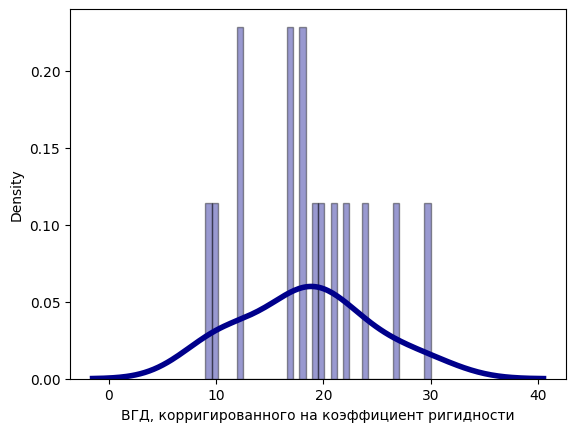

In [ ]:
sns.distplot(data_1_stage['ВГД, корригированного на коэффициент ригидности'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['ВГД, корригированного на коэффициент ригидности']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.967, p-value=0.813
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['ВГД, корригированного на коэффициент ригидности']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.131, p-value=0.937
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Коэффициент ригидности склеральной капсулы глаза

<ipython-input-527-2c6f36521ef2>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['Коэфф ригидности склеральн капсулы глаза'], hist=True, kde=True,


<Axes: xlabel='Коэфф ригидности склеральн капсулы глаза', ylabel='Density'>

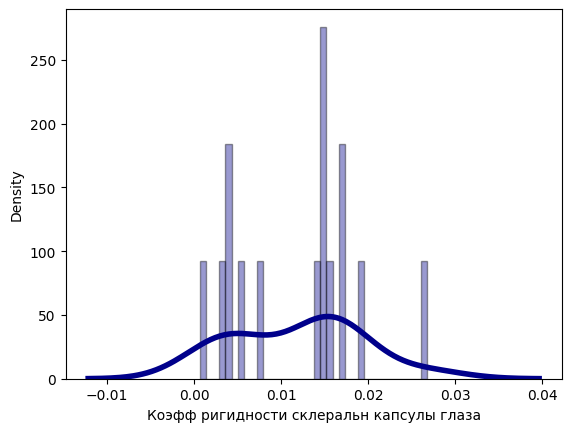

In [ ]:
sns.distplot(data_1_stage['Коэфф ригидности склеральн капсулы глаза'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['Коэфф ригидности склеральн капсулы глаза']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.920, p-value=0.191
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['Коэфф ригидности склеральн капсулы глаза']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.224, p-value=0.894
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Роговично-компенсированное ВГД

<ipython-input-530-279d9d8a743f>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['Роговично-компенсированное ВГД'], hist=True, kde=True,


<Axes: xlabel='Роговично-компенсированное ВГД', ylabel='Density'>

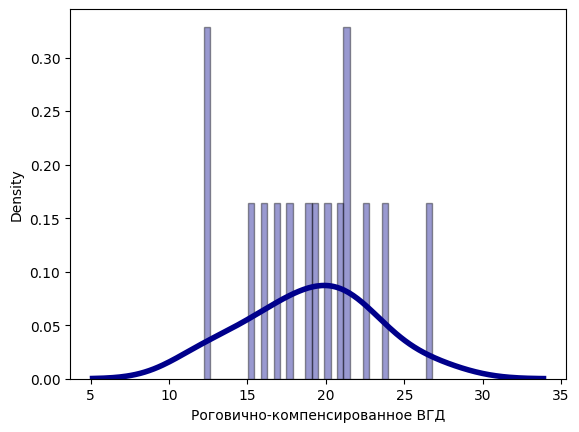

In [ ]:
sns.distplot(data_1_stage['Роговично-компенсированное ВГД'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['Роговично-компенсированное ВГД']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.979, p-value=0.965
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['Роговично-компенсированное ВГД']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.008, p-value=0.996
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ВГД по Гольдману

<ipython-input-533-ccecdc394726>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['ВГД по Гольдману'], hist=True, kde=True,


<Axes: xlabel='ВГД по Гольдману', ylabel='Density'>

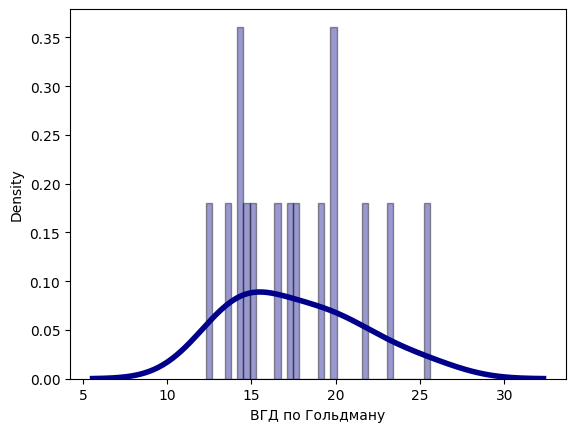

In [ ]:
sns.distplot(data_1_stage['ВГД по Гольдману'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['ВГД по Гольдману']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.952, p-value=0.555
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['ВГД по Гольдману']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.135, p-value=0.567
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Фактор резистентности роговицы

<ipython-input-536-34d1b0b70fbb>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['Фактор резистентности роговицы'], hist=True, kde=True,


<Axes: xlabel='Фактор резистентности роговицы', ylabel='Density'>

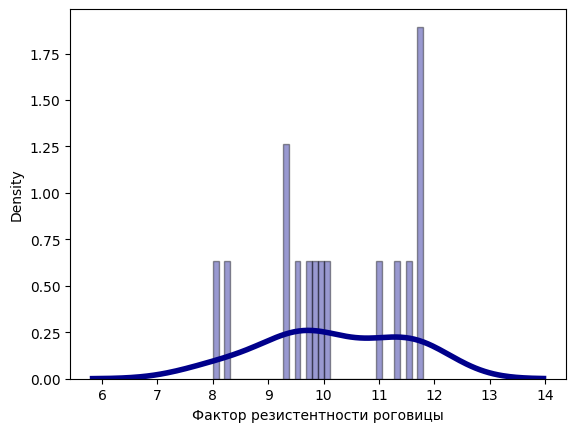

In [ ]:
sns.distplot(data_1_stage['Фактор резистентности роговицы'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['Фактор резистентности роговицы']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.921, p-value=0.199
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['Фактор резистентности роговицы']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.277, p-value=0.528
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### КГ

<ipython-input-539-493a5572dd03>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['КГ'], hist=True, kde=True,


<Axes: xlabel='КГ', ylabel='Density'>

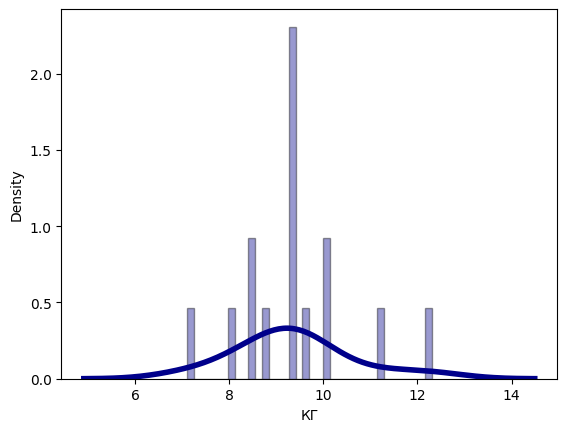

In [ ]:
sns.distplot(data_1_stage['КГ'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['КГ']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.942, p-value=0.405
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['КГ']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=3.121, p-value=0.210
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ЦТР

<ipython-input-542-a4709c55575b>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['ЦТР'], hist=True, kde=True,


<Axes: xlabel='ЦТР', ylabel='Density'>

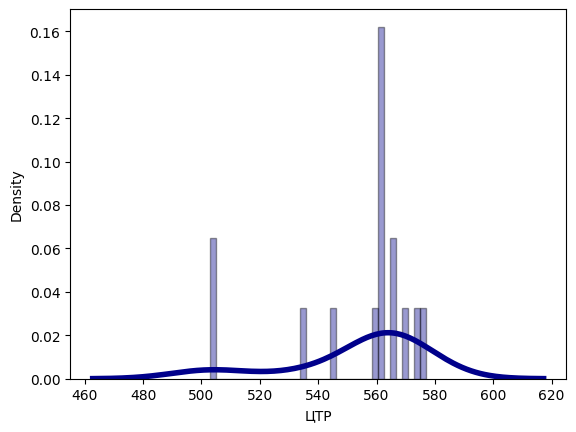

In [ ]:
sns.distplot(data_1_stage['ЦТР'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['ЦТР']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.751, p-value=0.001
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['ЦТР']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=8.872, p-value=0.012
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### РП

<ipython-input-545-04e8e0b51172>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['РП'], hist=True, kde=True,


<Axes: xlabel='РП', ylabel='Density'>

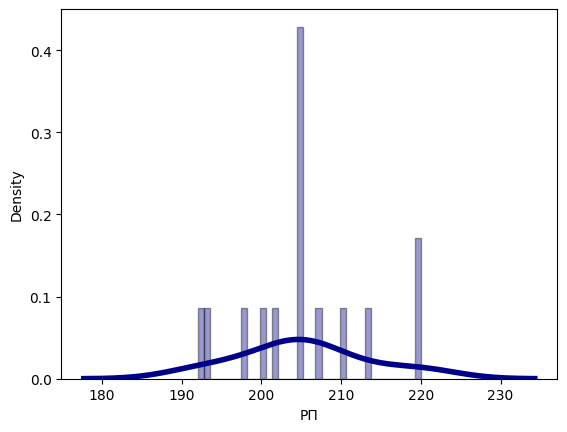

In [ ]:
sns.distplot(data_1_stage['РП'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['РП']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.938, p-value=0.353
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['РП']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.375, p-value=0.829
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ГлРП

<ipython-input-548-bda9f069481b>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['ГлРП'], hist=True, kde=True,


<Axes: xlabel='ГлРП', ylabel='Density'>

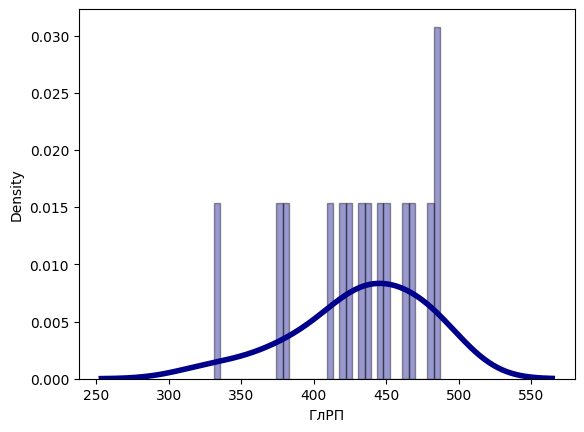

In [ ]:
sns.distplot(data_1_stage['ГлРП'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['ГлРП']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.936, p-value=0.340
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['ГлРП']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=2.617, p-value=0.270
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)


### gamma Ш

<ipython-input-551-7e3ef4026494>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['gamma Ш'], hist=True, kde=True,


<Axes: xlabel='gamma Ш', ylabel='Density'>

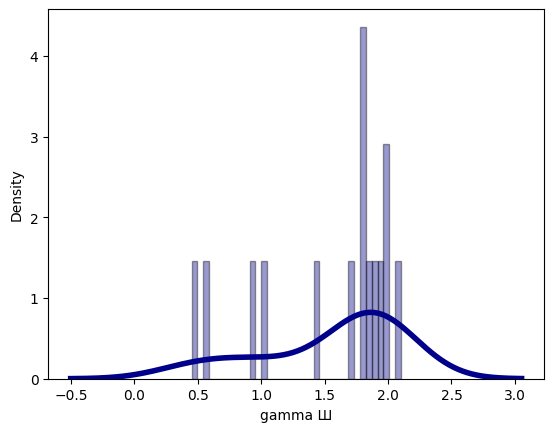

In [ ]:
sns.distplot(data_1_stage['gamma Ш'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['gamma Ш']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.815, p-value=0.006
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['gamma Ш']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=3.700, p-value=0.157
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---










---








### Efrid

<ipython-input-554-688c2649f78a>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['Efrid'], hist=True, kde=True,


<Axes: xlabel='Efrid', ylabel='Density'>

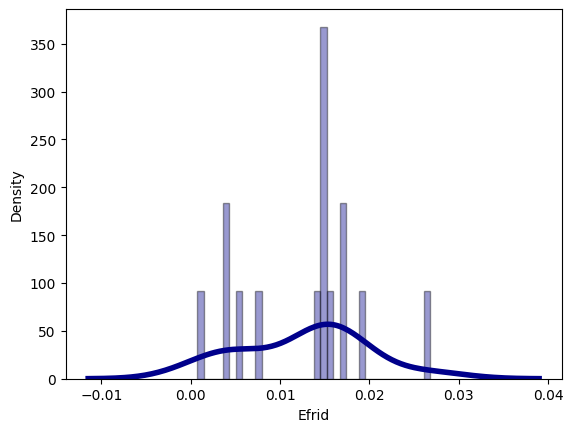

In [ ]:
sns.distplot(data_1_stage['Efrid'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['Efrid']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.917, p-value=0.175
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['Efrid']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.017, p-value=0.992
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### SVL

<ipython-input-557-3cc2acb80886>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['SVL'], hist=True, kde=True,


<Axes: xlabel='SVL', ylabel='Density'>

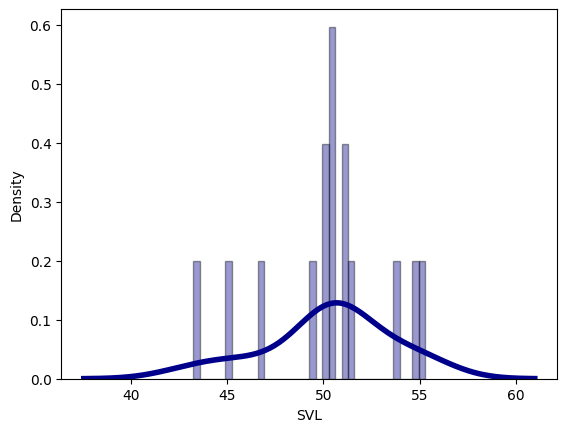

In [ ]:
sns.distplot(data_1_stage['SVL'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['SVL']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.920, p-value=0.196
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['SVL']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.798, p-value=0.407
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### DVL

<ipython-input-560-6028932ce58b>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['DVL'], hist=True, kde=True,


<Axes: xlabel='DVL', ylabel='Density'>

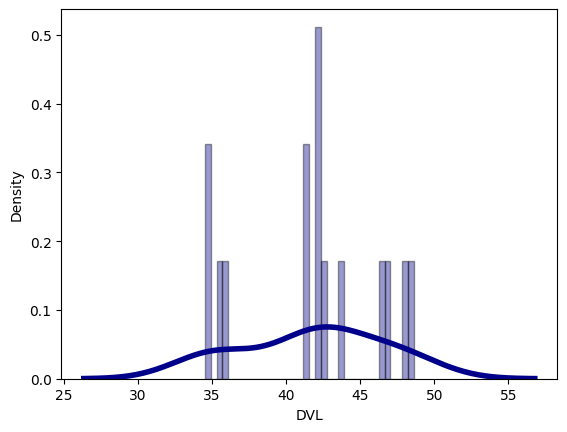

In [ ]:
sns.distplot(data_1_stage['DVL'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['DVL']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.912, p-value=0.143
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['DVL']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.210, p-value=0.546
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### РИ (рео. индекс) мОм

<ipython-input-563-1add5282239c>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['РИ (рео.индекс) мОм'], hist=True, kde=True,


<Axes: xlabel='РИ (рео.индекс) мОм', ylabel='Density'>

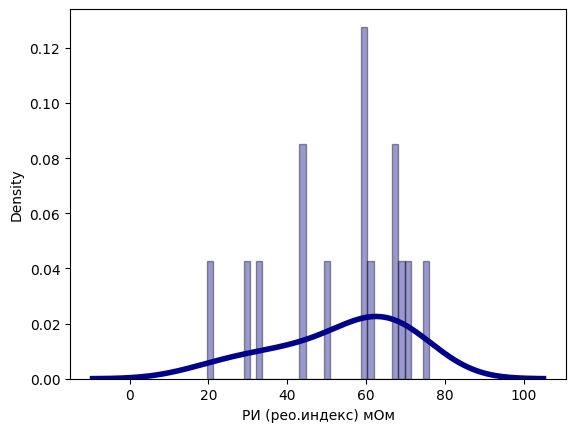

In [ ]:
sns.distplot(data_1_stage['РИ (рео.индекс) мОм'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['РИ (рео.индекс) мОм']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.929, p-value=0.268
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['РИ (рео.индекс) мОм']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.672, p-value=0.433
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ПМН (макс. нап)

<ipython-input-566-56fe971c0bbd>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['ПМН (макс.нап)'], hist=True, kde=True,


<Axes: xlabel='ПМН (макс.нап)', ylabel='Density'>

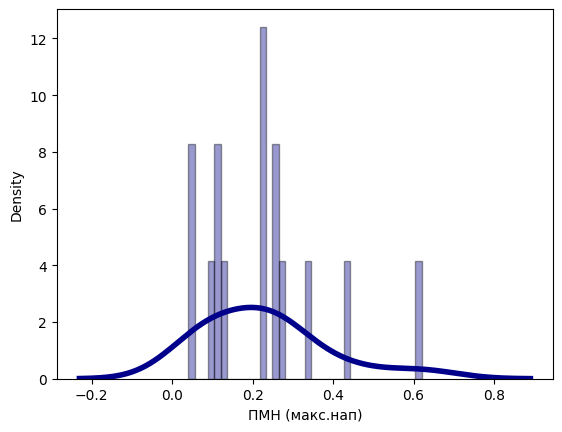

In [ ]:
sns.distplot(data_1_stage['ПМН (макс.нап)'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['ПМН (макс.нап)']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.897, p-value=0.086
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['ПМН (макс.нап)']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=6.246, p-value=0.044
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ПМУ (мод.упр.)

<ipython-input-569-5b26ee228155>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['ПМУ (мод.упр.)'], hist=True, kde=True,


<Axes: xlabel='ПМУ (мод.упр.)', ylabel='Density'>

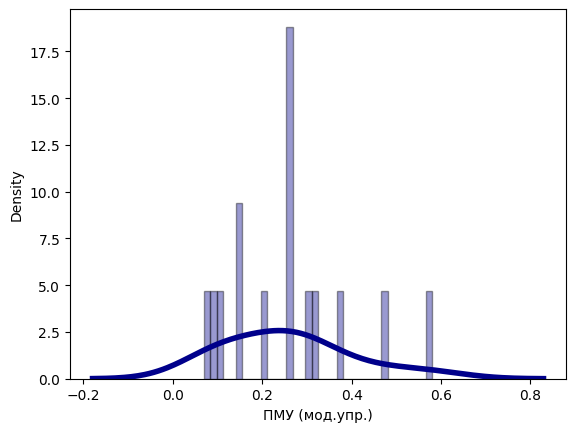

In [ ]:
sns.distplot(data_1_stage['ПМУ (мод.упр.)'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['ПМУ (мод.упр.)']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.937, p-value=0.345
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['ПМУ (мод.упр.)']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=2.315, p-value=0.314
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Z баз. (отн.)

<ipython-input-572-7c67e77312dc>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['Z баз.(отн.))'], hist=True, kde=True,


<Axes: xlabel='Z баз.(отн.))', ylabel='Density'>

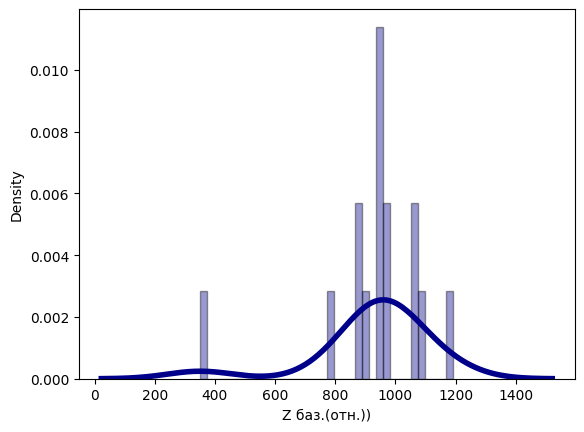

In [ ]:
sns.distplot(data_1_stage['Z баз.(отн.))'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['Z баз.(отн.))']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.793, p-value=0.003
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['Z баз.(отн.))']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)


Statistics=19.597, p-value=0.000
Отклонить гипотезу о нормальности




---








### Z баз. (мОм)

<ipython-input-575-7f879aa4e95c>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['Z баз.(мОм)'], hist=True, kde=True,


<Axes: xlabel='Z баз.(мОм)', ylabel='Density'>

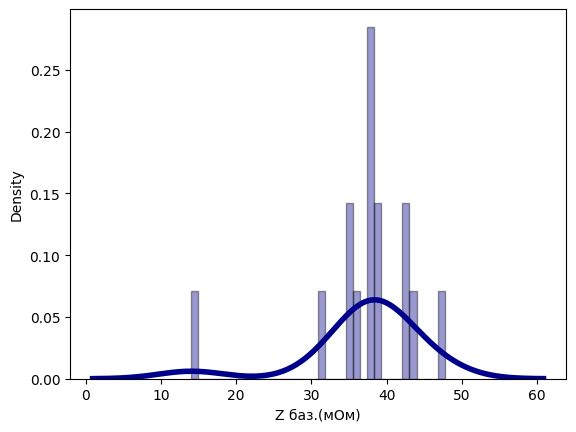

In [ ]:
sns.distplot(data_1_stage['Z баз.(мОм)'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['Z баз.(мОм)']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.793, p-value=0.003
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['Z баз.(мОм)']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=19.597, p-value=0.000
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### УОК (уд. объем) мкл

<ipython-input-578-fa8c3913db66>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_1_stage['УОК (уд.объем) мкл'], hist=True, kde=True,


<Axes: xlabel='УОК (уд.объем) мкл', ylabel='Density'>

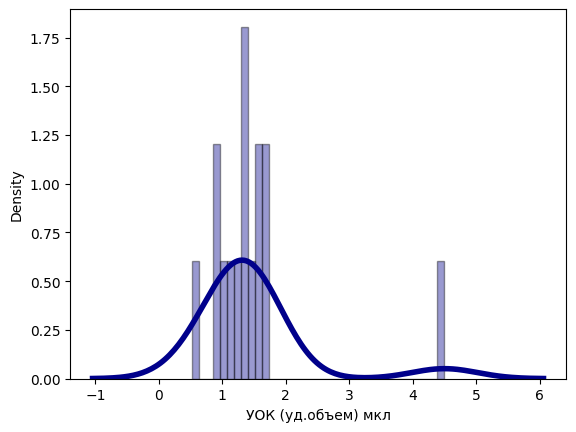

In [ ]:
sns.distplot(data_1_stage['УОК (уд.объем) мкл'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_1_stage['УОК (уд.объем) мкл']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.637, p-value=0.000
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_1_stage['УОК (уд.объем) мкл']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=30.653, p-value=0.000
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)


## Пациенты со 2й стадией заболевания

Проверим на нормальность данные пациентов со 2й стадией заболевания

### Возраст

<ipython-input-581-32ab434012fe>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['возраст'], hist=True, kde=True,


<Axes: xlabel='возраст', ylabel='Density'>

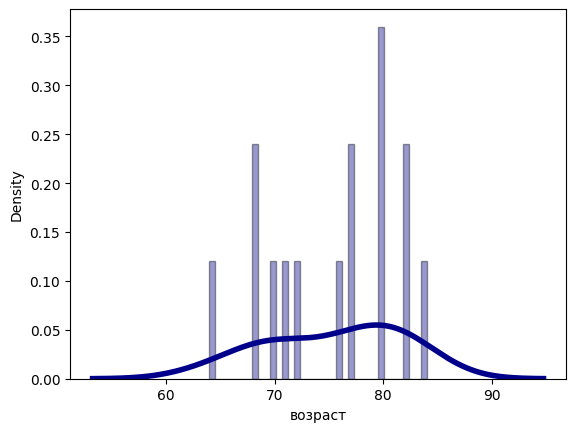

In [ ]:
sns.distplot(data_2_stage['возраст'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['возраст']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.936, p-value=0.335
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['возраст']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.836, p-value=0.399
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Величина внутриглазного давления

<ipython-input-584-baa1c87dd17f>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['величина внутриглазного давления'], hist=True, kde=True,


<Axes: xlabel='величина внутриглазного давления', ylabel='Density'>

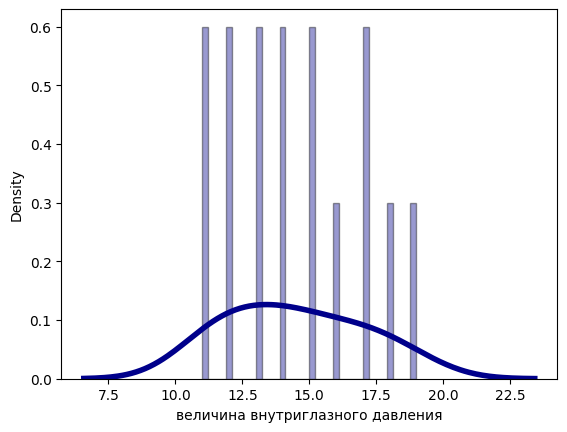

In [ ]:
sns.distplot(data_2_stage['величина внутриглазного давления'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['величина внутриглазного давления']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.953, p-value=0.570
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['величина внутриглазного давления']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.255, p-value=0.534
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ВГД, корригированного на коэффициент ригидности



<ipython-input-587-c7d618295f5d>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['ВГД, корригированного на коэффициент ригидности'], hist=True, kde=True,


<Axes: xlabel='ВГД, корригированного на коэффициент ригидности', ylabel='Density'>

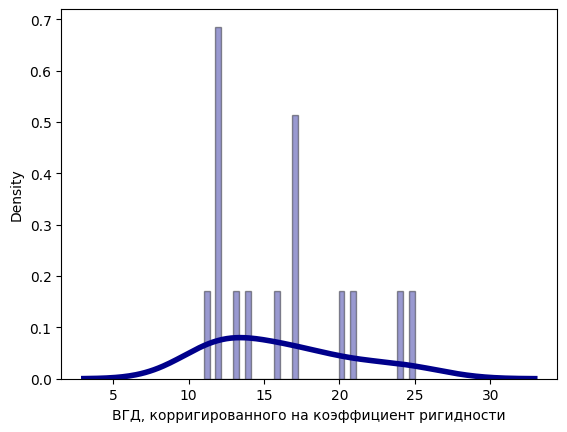

In [ ]:
sns.distplot(data_2_stage['ВГД, корригированного на коэффициент ригидности'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['ВГД, корригированного на коэффициент ригидности']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.891, p-value=0.069
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['ВГД, корригированного на коэффициент ригидности']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.847, p-value=0.397
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Коэффициент ригидности склеральной капсулы глаза

<ipython-input-590-ca93c962d174>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['Коэфф ригидности склеральн капсулы глаза'], hist=True, kde=True,


<Axes: xlabel='Коэфф ригидности склеральн капсулы глаза', ylabel='Density'>

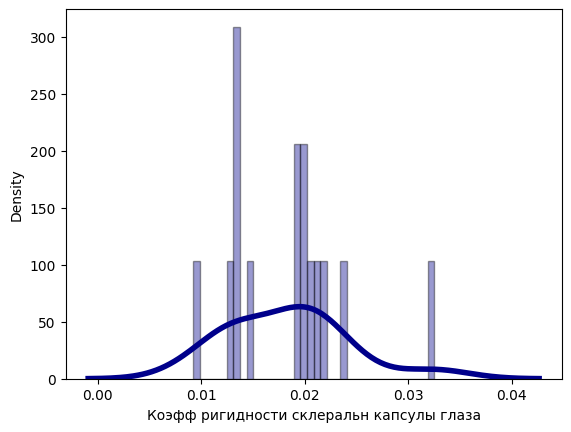

In [ ]:
sns.distplot(data_2_stage['Коэфф ригидности склеральн капсулы глаза'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['Коэфф ригидности склеральн капсулы глаза']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.925, p-value=0.231
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['Коэфф ригидности склеральн капсулы глаза']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=3.284, p-value=0.194
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Роговично-компенсированное ВГД

<ipython-input-593-1a6cb091e9a2>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['Роговично-компенсированное ВГД'], hist=True, kde=True,


<Axes: xlabel='Роговично-компенсированное ВГД', ylabel='Density'>

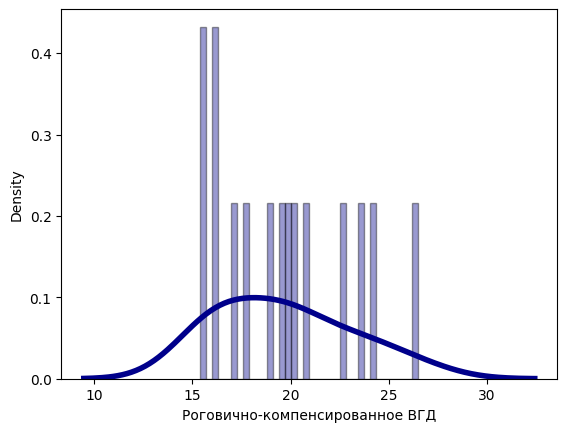

In [ ]:
sns.distplot(data_2_stage['Роговично-компенсированное ВГД'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['Роговично-компенсированное ВГД']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.939, p-value=0.375
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['Роговично-компенсированное ВГД']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.161, p-value=0.560
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ВГД по Гольдману

<ipython-input-596-0b55d4f1b3f3>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['ВГД по Гольдману'], hist=True, kde=True,


<Axes: xlabel='ВГД по Гольдману', ylabel='Density'>

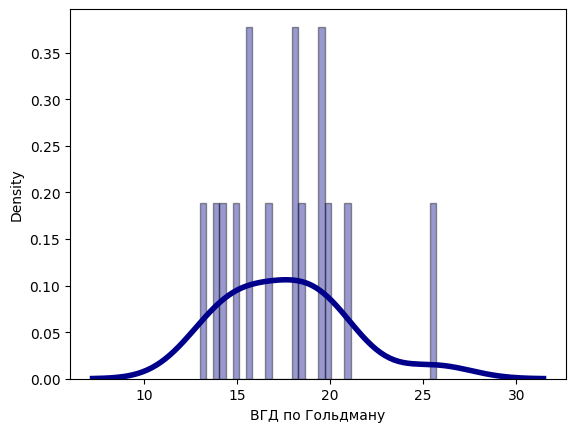

In [ ]:
sns.distplot(data_2_stage['ВГД по Гольдману'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['ВГД по Гольдману']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.942, p-value=0.413
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['ВГД по Гольдману']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=3.470, p-value=0.176
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Фактор резистентности роговицы

<ipython-input-599-f9c59a87b4c1>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['Фактор резистентности роговицы'], hist=True, kde=True,


<Axes: xlabel='Фактор резистентности роговицы', ylabel='Density'>

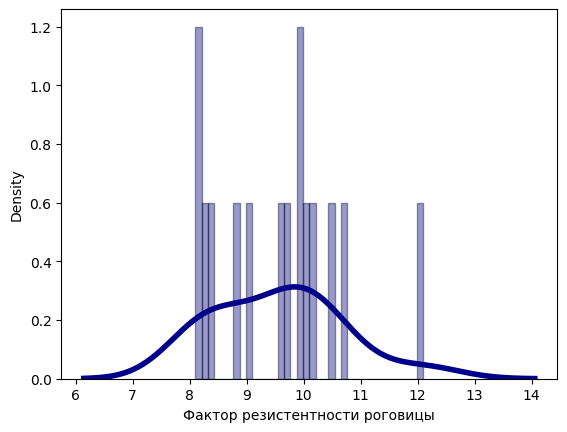

In [ ]:
sns.distplot(data_2_stage['Фактор резистентности роговицы'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['Фактор резистентности роговицы']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.938, p-value=0.361
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['Фактор резистентности роговицы']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.161, p-value=0.560
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### КГ

<ipython-input-602-a3a76b47673f>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['КГ'], hist=True, kde=True,


<Axes: xlabel='КГ', ylabel='Density'>

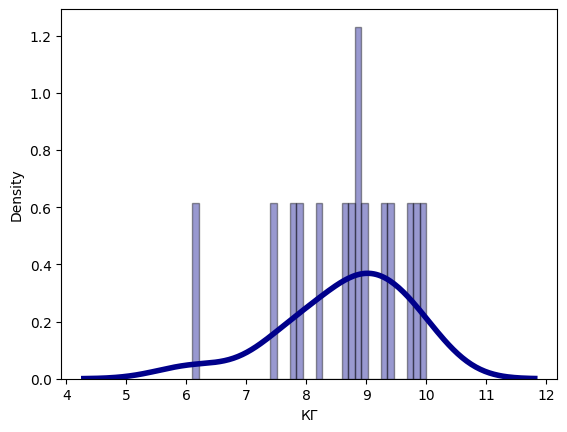

In [ ]:
sns.distplot(data_2_stage['КГ'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['КГ']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.932, p-value=0.292
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['КГ']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=4.502, p-value=0.105
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ЦТР

<ipython-input-605-e88052d6fad4>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['ЦТР'], hist=True, kde=True,


<Axes: xlabel='ЦТР', ylabel='Density'>

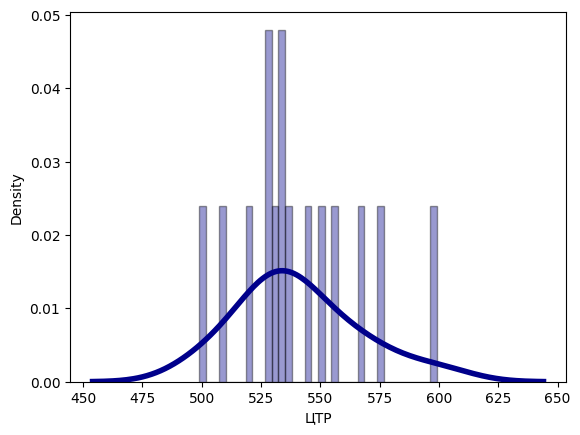

In [ ]:
sns.distplot(data_2_stage['ЦТР'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['ЦТР']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.964, p-value=0.768
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['ЦТР']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=2.066, p-value=0.356
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### РП

<ipython-input-608-234f9445db49>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['РП'], hist=True, kde=True,


<Axes: xlabel='РП', ylabel='Density'>

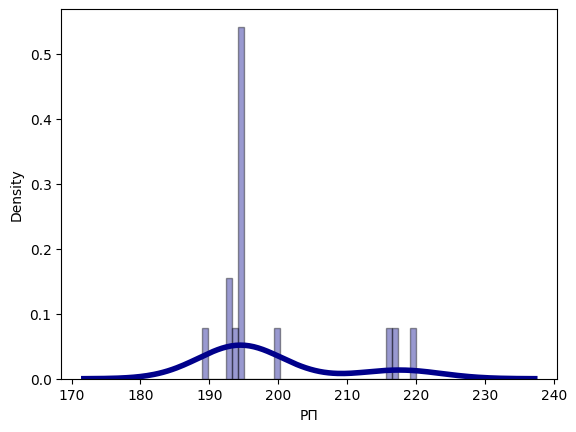

In [ ]:
sns.distplot(data_2_stage['РП'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['РП']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.694, p-value=0.000
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['РП']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=6.701, p-value=0.035
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ГлРП

<ipython-input-611-6fe08ab9b1eb>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['ГлРП'], hist=True, kde=True,


<Axes: xlabel='ГлРП', ylabel='Density'>

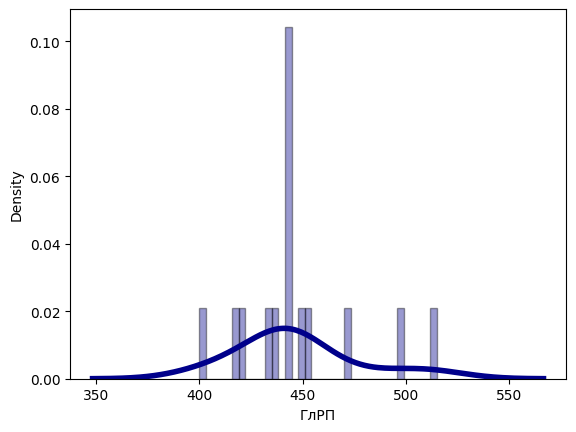

In [ ]:
sns.distplot(data_2_stage['ГлРП'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['ГлРП']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.896, p-value=0.082
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['ГлРП']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=4.401, p-value=0.111
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)


### gamma Ш

<ipython-input-614-5465096ab696>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['gamma Ш'], hist=True, kde=True,


<Axes: xlabel='gamma Ш', ylabel='Density'>

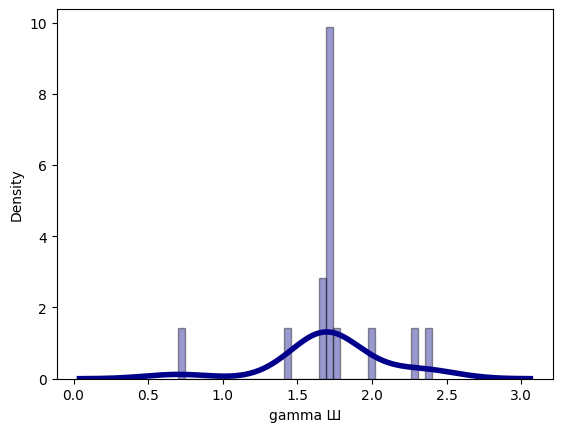

In [ ]:
sns.distplot(data_2_stage['gamma Ш'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['gamma Ш']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.796, p-value=0.003
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['gamma Ш']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=7.665, p-value=0.022
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---










---








### Efrid

<ipython-input-617-850da428336c>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['Efrid'], hist=True, kde=True,


<Axes: xlabel='Efrid', ylabel='Density'>

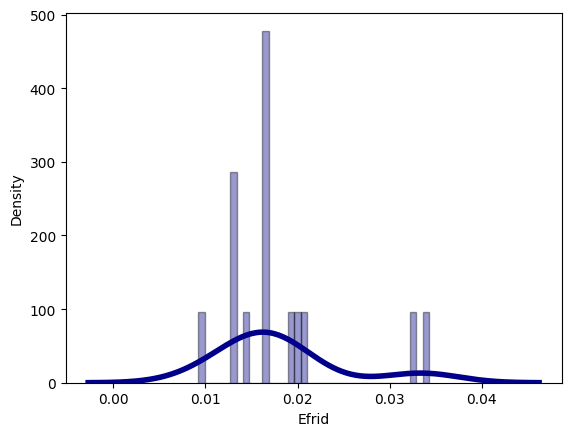

In [ ]:
sns.distplot(data_2_stage['Efrid'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['Efrid']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.815, p-value=0.006
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['Efrid']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=8.939, p-value=0.011
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### SVL

<ipython-input-620-46f49139602d>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['SVL'], hist=True, kde=True,


<Axes: xlabel='SVL', ylabel='Density'>

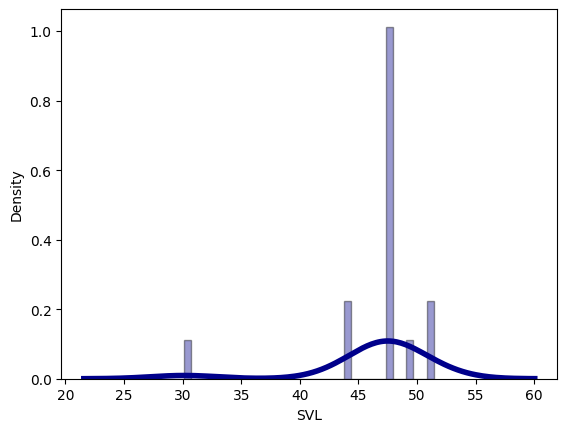

In [ ]:
sns.distplot(data_2_stage['SVL'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['SVL']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.625, p-value=0.000
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['SVL']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=28.661, p-value=0.000
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### DVL

<ipython-input-623-aa5ed0f2e470>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['DVL'], hist=True, kde=True,


<Axes: xlabel='DVL', ylabel='Density'>

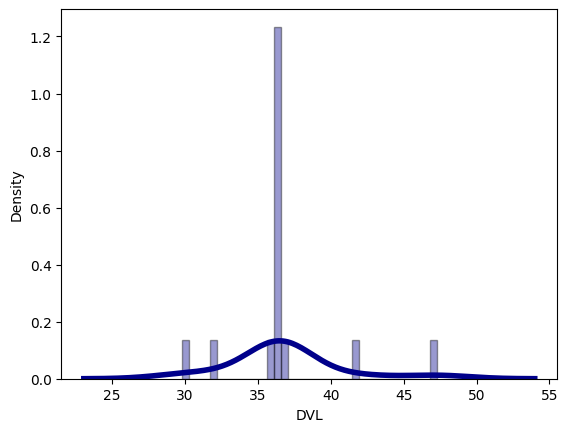

In [ ]:
sns.distplot(data_2_stage['DVL'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['DVL']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.747, p-value=0.001
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['DVL']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=9.579, p-value=0.008
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### РИ (рео. индекс) мОм

<ipython-input-626-07aa63f05b1c>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['РИ (рео.индекс) мОм'], hist=True, kde=True,


<Axes: xlabel='РИ (рео.индекс) мОм', ylabel='Density'>

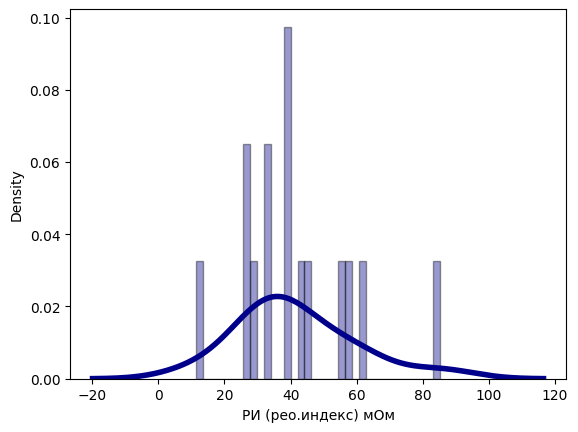

In [ ]:
sns.distplot(data_2_stage['РИ (рео.индекс) мОм'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['РИ (рео.индекс) мОм']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.940, p-value=0.376
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['РИ (рео.индекс) мОм']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=4.132, p-value=0.127
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ПМН (макс. нап)

<ipython-input-629-56a95047acb5>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['ПМН (макс.нап)'], hist=True, kde=True,


<Axes: xlabel='ПМН (макс.нап)', ylabel='Density'>

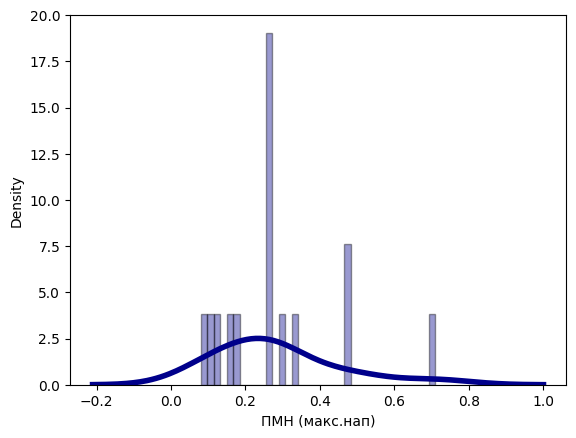

In [ ]:
sns.distplot(data_2_stage['ПМН (макс.нап)'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['ПМН (макс.нап)']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.880, p-value=0.047
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['ПМН (макс.нап)']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=7.048, p-value=0.029
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ПМУ (мод.упр.)

<ipython-input-632-8f3cf69fe230>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['ПМУ (мод.упр.)'], hist=True, kde=True,


<Axes: xlabel='ПМУ (мод.упр.)', ylabel='Density'>

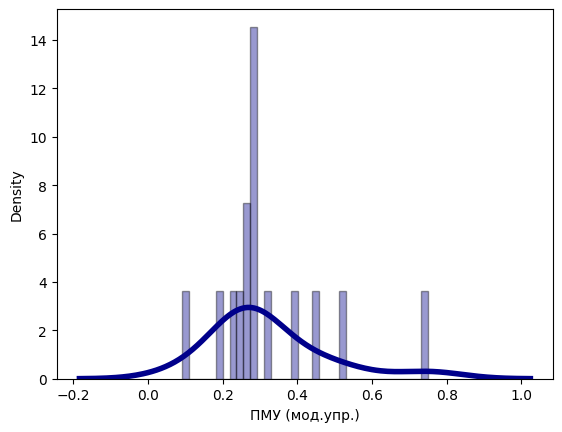

In [ ]:
sns.distplot(data_2_stage['ПМУ (мод.упр.)'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['ПМУ (мод.упр.)']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.849, p-value=0.017
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['ПМУ (мод.упр.)']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=11.015, p-value=0.004
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Z баз. (отн.)

<ipython-input-635-5dc94f98e898>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['Z баз.(отн.))'], hist=True, kde=True,


<Axes: xlabel='Z баз.(отн.))', ylabel='Density'>

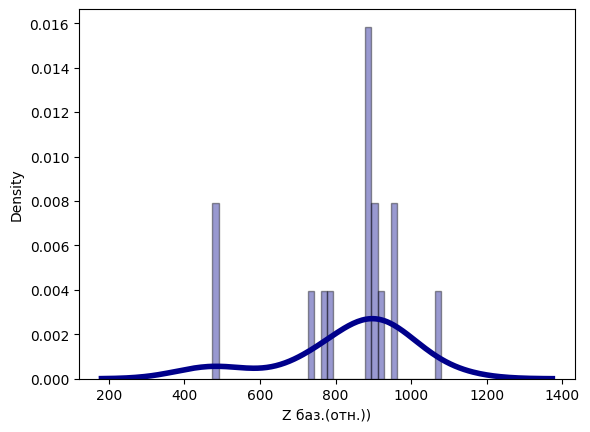

In [ ]:
sns.distplot(data_2_stage['Z баз.(отн.))'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['Z баз.(отн.))']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.835, p-value=0.011
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['Z баз.(отн.))']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=6.269, p-value=0.044
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Z баз. (мОм)

<ipython-input-638-47a102590f41>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['Z баз.(мОм)'], hist=True, kde=True,


<Axes: xlabel='Z баз.(мОм)', ylabel='Density'>

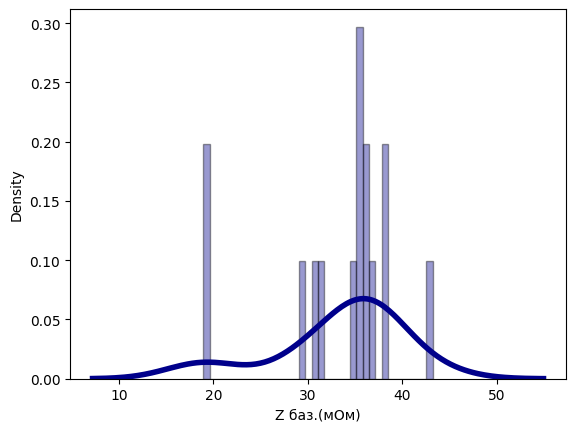

In [ ]:
sns.distplot(data_2_stage['Z баз.(мОм)'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['Z баз.(мОм)']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.835, p-value=0.011
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['Z баз.(мОм)']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=6.269, p-value=0.044
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### УОК (уд. объем) мкл

<ipython-input-641-dab54c8374e7>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2_stage['УОК (уд.объем) мкл'], hist=True, kde=True,


<Axes: xlabel='УОК (уд.объем) мкл', ylabel='Density'>

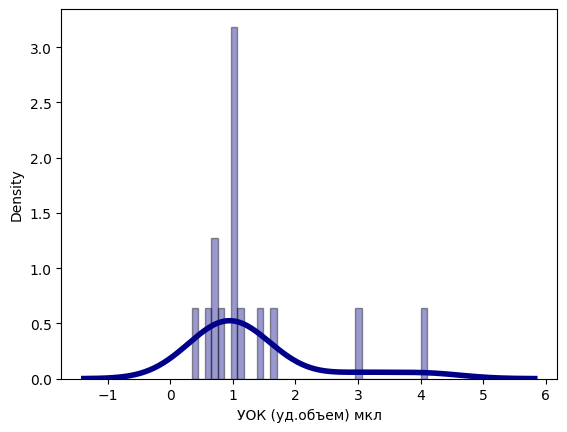

In [ ]:
sns.distplot(data_2_stage['УОК (уд.объем) мкл'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_2_stage['УОК (уд.объем) мкл']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.726, p-value=0.000
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_2_stage['УОК (уд.объем) мкл']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=17.051, p-value=0.000
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)


## Пациенты с 3й стадией заболевания

Проверим на нормальность данные пациентов с 3й стадией заболевания

### Возраст

<ipython-input-644-71d7032f0aeb>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['возраст'], hist=True, kde=True,


<Axes: xlabel='возраст', ylabel='Density'>

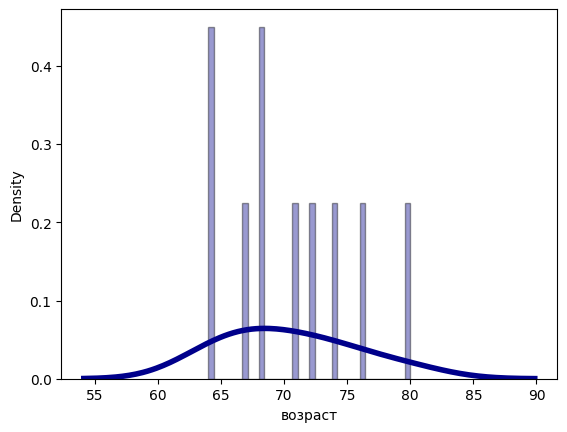

In [ ]:
sns.distplot(data_3_stage['возраст'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['возраст']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.950, p-value=0.671
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['возраст']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.614, p-value=0.736
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Величина внутриглазного давления

<ipython-input-647-d9469df688bd>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['величина внутриглазного давления'], hist=True, kde=True,


<Axes: xlabel='величина внутриглазного давления', ylabel='Density'>

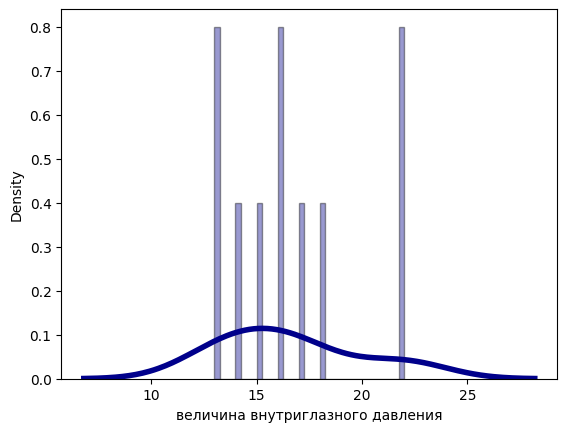

In [ ]:
sns.distplot(data_3_stage['величина внутриглазного давления'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['величина внутриглазного давления']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.883, p-value=0.142
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['величина внутриглазного давления']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.426, p-value=0.490
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ВГД, корригированного на коэффициент ригидности



<ipython-input-650-5e2a9f092264>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['ВГД, корригированного на коэффициент ригидности'], hist=True, kde=True,


<Axes: xlabel='ВГД, корригированного на коэффициент ригидности', ylabel='Density'>

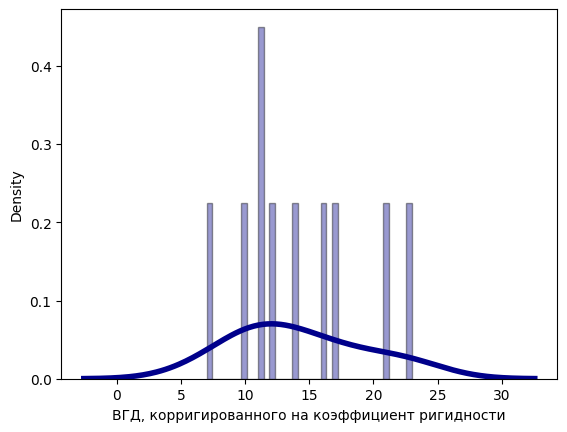

In [ ]:
sns.distplot(data_3_stage['ВГД, корригированного на коэффициент ригидности'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['ВГД, корригированного на коэффициент ригидности']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.951, p-value=0.683
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['ВГД, корригированного на коэффициент ригидности']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.708, p-value=0.702
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Коэффициент ригидности склеральной капсулы глаза

<ipython-input-653-2dbaf0d0f7b3>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['Коэфф ригидности склеральн капсулы глаза'], hist=True, kde=True,


<Axes: xlabel='Коэфф ригидности склеральн капсулы глаза', ylabel='Density'>

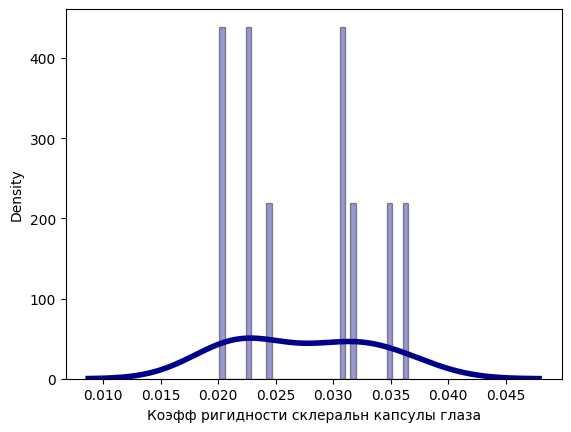

In [ ]:
sns.distplot(data_3_stage['Коэфф ригидности склеральн капсулы глаза'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['Коэфф ригидности склеральн капсулы глаза']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.904, p-value=0.244
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['Коэфф ригидности склеральн капсулы глаза']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=2.602, p-value=0.272
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Роговично-компенсированное ВГД

<ipython-input-656-8e1471d323f1>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['Роговично-компенсированное ВГД'], hist=True, kde=True,


<Axes: xlabel='Роговично-компенсированное ВГД', ylabel='Density'>

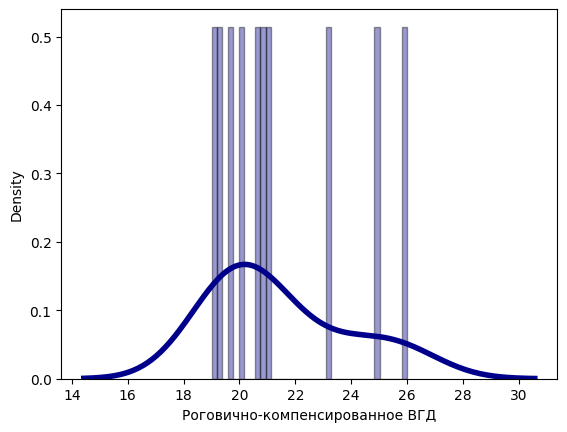

In [ ]:
sns.distplot(data_3_stage['Роговично-компенсированное ВГД'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['Роговично-компенсированное ВГД']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.864, p-value=0.086
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['Роговично-компенсированное ВГД']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=2.311, p-value=0.315
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ВГД по Гольдману

<ipython-input-659-cb027aac6d0e>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['ВГД по Гольдману'], hist=True, kde=True,


<Axes: xlabel='ВГД по Гольдману', ylabel='Density'>

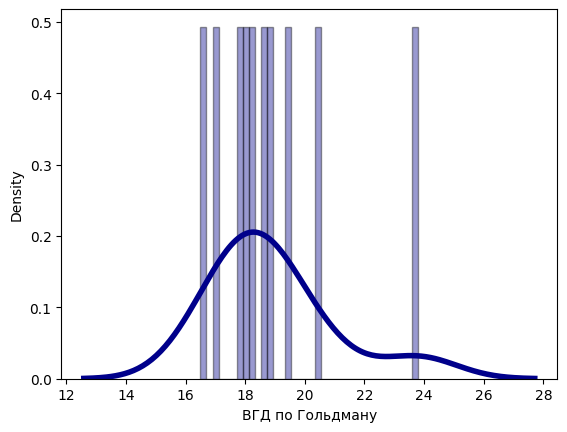

In [ ]:
sns.distplot(data_3_stage['ВГД по Гольдману'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['ВГД по Гольдману']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.874, p-value=0.112
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['ВГД по Гольдману']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=8.765, p-value=0.012
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Фактор резистентности роговицы

<ipython-input-662-bab464e78f35>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['Фактор резистентности роговицы'], hist=True, kde=True,


<Axes: xlabel='Фактор резистентности роговицы', ylabel='Density'>

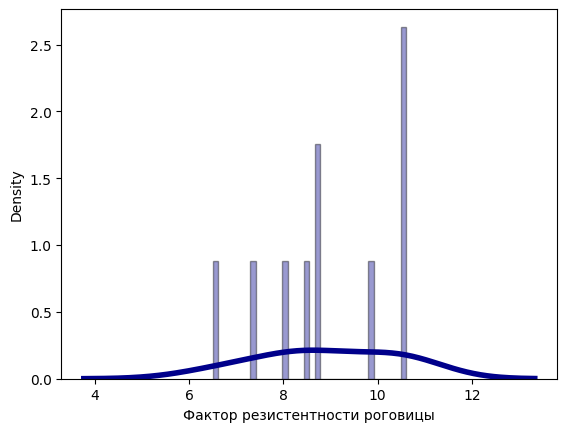

In [ ]:
sns.distplot(data_3_stage['Фактор резистентности роговицы'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['Фактор резистентности роговицы']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.919, p-value=0.349
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['Фактор резистентности роговицы']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.786, p-value=0.675
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### КГ

<ipython-input-665-5133419e5a09>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['КГ'], hist=True, kde=True,


<Axes: xlabel='КГ', ylabel='Density'>

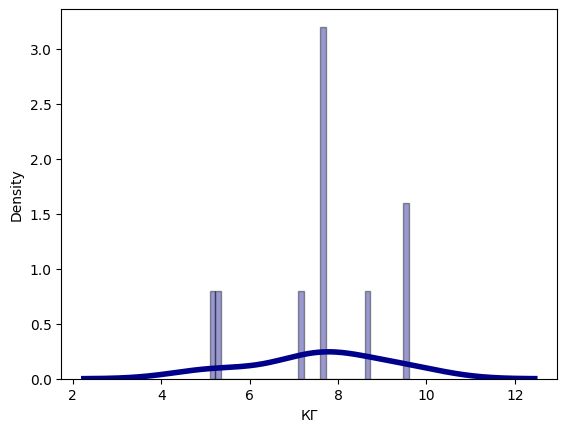

In [ ]:
sns.distplot(data_3_stage['КГ'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['КГ']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.906, p-value=0.256
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['КГ']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.437, p-value=0.804
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ЦТР

<ipython-input-668-449a47005b5e>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['ЦТР'], hist=True, kde=True,


<Axes: xlabel='ЦТР', ylabel='Density'>

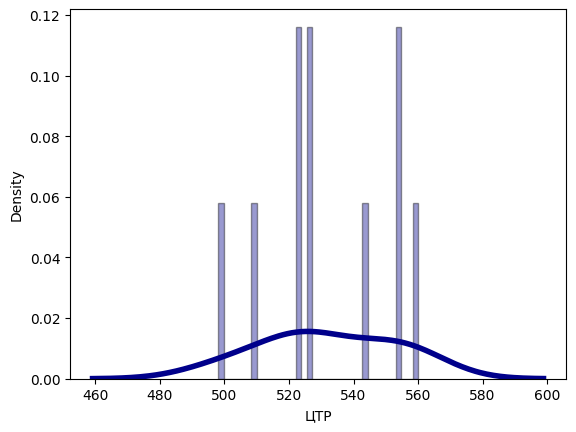

In [ ]:
sns.distplot(data_3_stage['ЦТР'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['ЦТР']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.936, p-value=0.514
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['ЦТР']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.564, p-value=0.754
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### РП

<ipython-input-671-66b9207cb78c>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['РП'], hist=True, kde=True,


<Axes: xlabel='РП', ylabel='Density'>

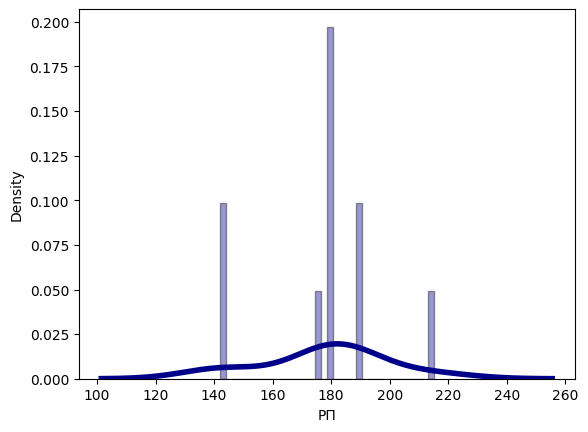

In [ ]:
sns.distplot(data_3_stage['РП'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['РП']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.872, p-value=0.107
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['РП']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.888, p-value=0.641
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ГлРП

<ipython-input-674-d58541a41216>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['ГлРП'], hist=True, kde=True,


<Axes: xlabel='ГлРП', ylabel='Density'>

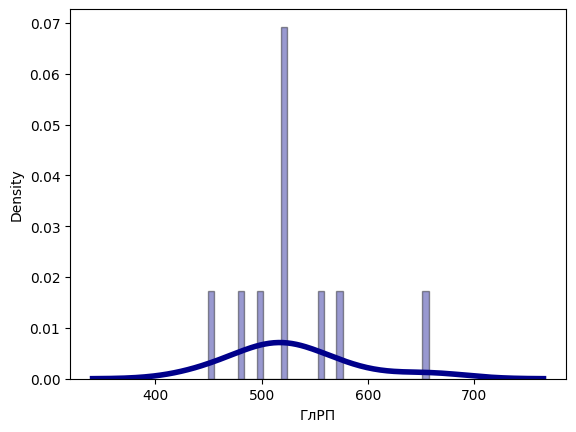

In [ ]:
sns.distplot(data_3_stage['ГлРП'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['ГлРП']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.908, p-value=0.265
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['ГлРП']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=4.860, p-value=0.088
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


### gamma Ш

<ipython-input-677-de0386c4e7e5>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['gamma Ш'], hist=True, kde=True,


<Axes: xlabel='gamma Ш', ylabel='Density'>

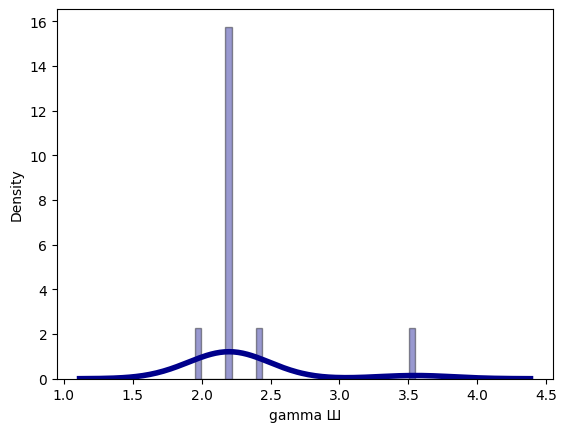

In [ ]:
sns.distplot(data_3_stage['gamma Ш'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['gamma Ш']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.551, p-value=0.000
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['gamma Ш']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=24.228, p-value=0.000
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---










---








### Efrid

<ipython-input-680-1fdf524a17a5>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['Efrid'], hist=True, kde=True,


<Axes: xlabel='Efrid', ylabel='Density'>

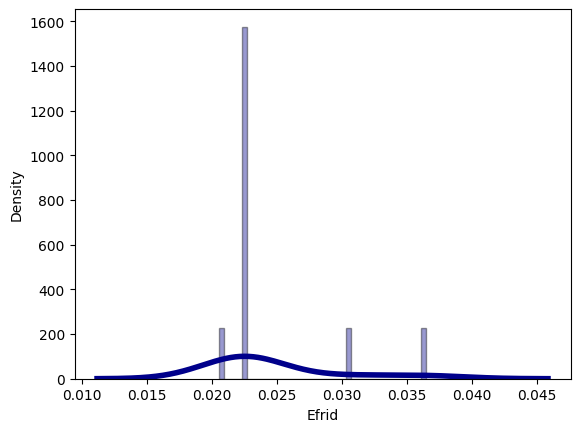

In [ ]:
sns.distplot(data_3_stage['Efrid'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['Efrid']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.632, p-value=0.000
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['Efrid']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=11.890, p-value=0.003
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### SVL

<ipython-input-683-881a3b8a616f>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['SVL'], hist=True, kde=True,


<Axes: xlabel='SVL', ylabel='Density'>

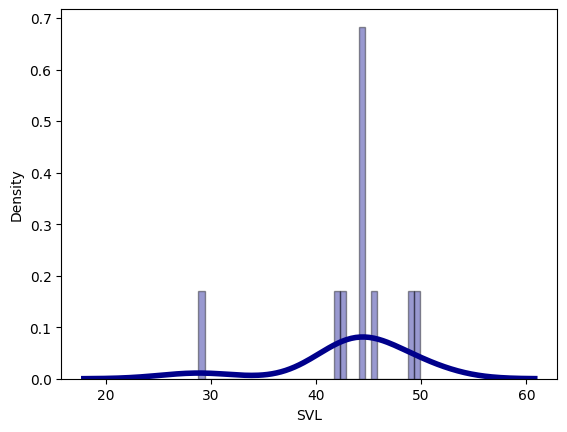

In [ ]:
sns.distplot(data_3_stage['SVL'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['SVL']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.761, p-value=0.005
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['SVL']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=14.232, p-value=0.001
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### DVL

<ipython-input-686-e85b6a5b8c88>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['DVL'], hist=True, kde=True,


<Axes: xlabel='DVL', ylabel='Density'>

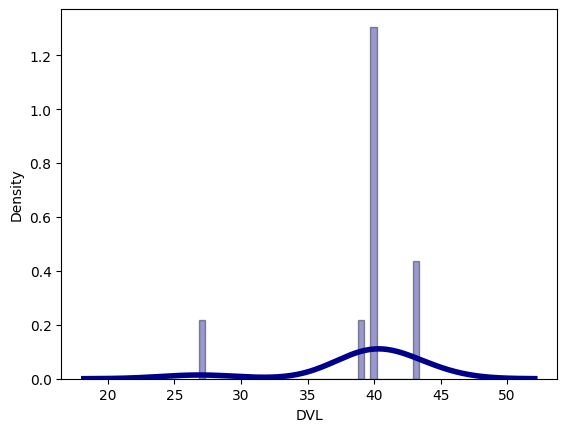

In [ ]:
sns.distplot(data_3_stage['DVL'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['DVL']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.634, p-value=0.000
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['DVL']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=20.800, p-value=0.000
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### РИ (рео. индекс) мОм

<ipython-input-689-499c29a774e0>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['РИ (рео.индекс) мОм'], hist=True, kde=True,


<Axes: xlabel='РИ (рео.индекс) мОм', ylabel='Density'>

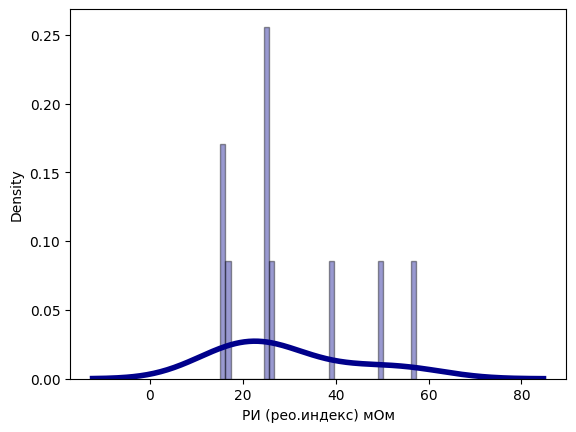

In [ ]:
sns.distplot(data_3_stage['РИ (рео.индекс) мОм'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['РИ (рео.индекс) мОм']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.860, p-value=0.077
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['РИ (рео.индекс) мОм']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=2.187, p-value=0.335
Принять гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ПМН (макс. нап)

<ipython-input-692-7c704f5767c2>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['ПМН (макс.нап)'], hist=True, kde=True,


<Axes: xlabel='ПМН (макс.нап)', ylabel='Density'>

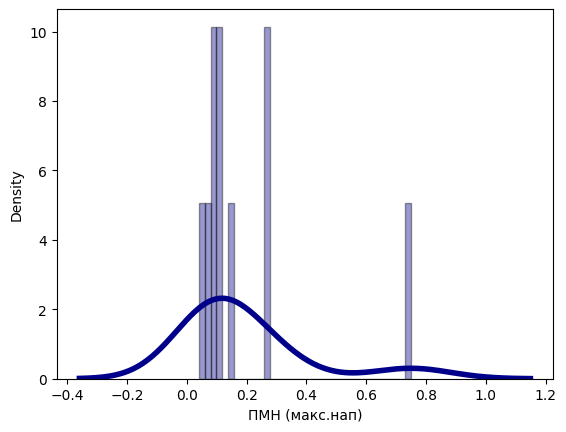

In [ ]:
sns.distplot(data_3_stage['ПМН (макс.нап)'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['ПМН (макс.нап)']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.680, p-value=0.001
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['ПМН (макс.нап)']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=18.736, p-value=0.000
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### ПМУ (мод.упр.)

<ipython-input-695-1bdb7d4d6f4b>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['ПМУ (мод.упр.)'], hist=True, kde=True,


<Axes: xlabel='ПМУ (мод.упр.)', ylabel='Density'>

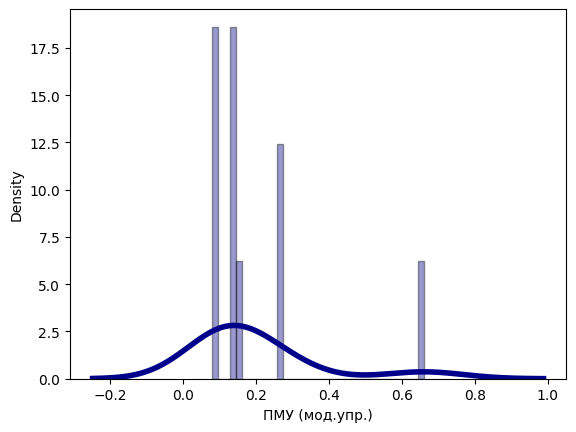

In [ ]:
sns.distplot(data_3_stage['ПМУ (мод.упр.)'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['ПМУ (мод.упр.)']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.678, p-value=0.000
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['ПМУ (мод.упр.)']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=18.966, p-value=0.000
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Z баз. (отн.)

<ipython-input-698-19254dbe6f8f>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['Z баз.(отн.))'], hist=True, kde=True,


<Axes: xlabel='Z баз.(отн.))', ylabel='Density'>

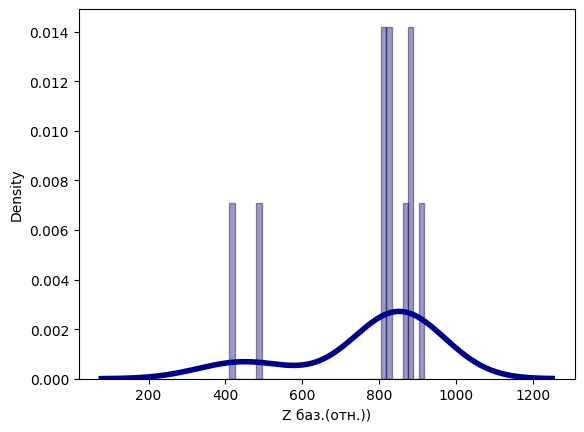

In [ ]:
sns.distplot(data_3_stage['Z баз.(отн.))'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['Z баз.(отн.))']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.714, p-value=0.001
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['Z баз.(отн.))']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=6.528, p-value=0.038
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### Z баз. (мОм)

<ipython-input-701-fc95fb252ac8>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['Z баз.(мОм)'], hist=True, kde=True,


<Axes: xlabel='Z баз.(мОм)', ylabel='Density'>

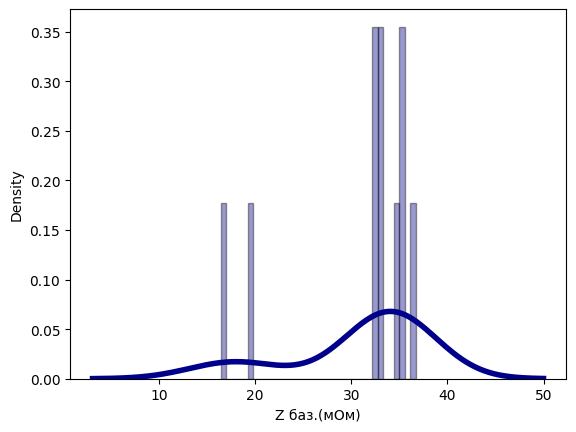

In [ ]:
sns.distplot(data_3_stage['Z баз.(мОм)'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['Z баз.(мОм)']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.714, p-value=0.001
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['Z баз.(мОм)']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=6.528, p-value=0.038
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)




---








### УОК (уд. объем) мкл

<ipython-input-704-e2289fd502b4>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_3_stage['УОК (уд.объем) мкл'], hist=True, kde=True,


<Axes: xlabel='УОК (уд.объем) мкл', ylabel='Density'>

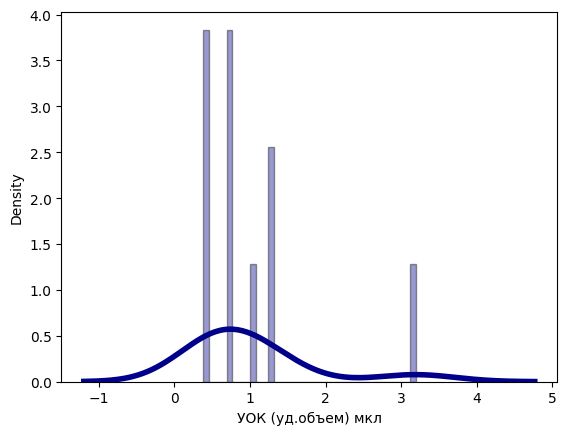

In [ ]:
sns.distplot(data_3_stage['УОК (уд.объем) мкл'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_3_stage['УОК (уд.объем) мкл']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.716, p-value=0.001
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_3_stage['УОК (уд.объем) мкл']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=17.604, p-value=0.000
Отклонить гипотезу о нормальности


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


## Все пациенты

Проверим на нормальность данные всех пациентов

In [ ]:
#объединим все таблицы
data_glaucoma_all=pd.concat([data_healthy, data_1_stage, data_2_stage, data_3_stage], axis=0)

In [ ]:
data_glaucoma_all

,Фамилия,возраст,стадия,величина внутриглазного давления,"ВГД, корригированного на коэффициент ригидности",Коэфф ригидности склеральн капсулы глаза,Роговично-компенсированное ВГД,ВГД по Гольдману,Фактор резистентности роговицы,КГ,...,gamma Ш,Efrid,SVL,DVL,РИ (рео.индекс) мОм,ПМН (макс.нап),ПМУ (мод.упр.),Z баз.(отн.)),Z баз.(мОм),УОК (уд.объем) мкл
0,уланкина,25,0,10,12,0.0162,9.70,9.40,9.30,11.3,...,1.75,0.0162,56.300000,46.030000,49.650,0.27,0.250,979,39.16,1.157570
1,степанова,26,0,12,15,0.0162,18.50,19.90,12.80,11.6,...,1.85,0.0162,50.960000,44.210000,51.555,0.28,0.275,948,37.92,1.252867
2,кудасов,32,0,10,12,0.0162,14.30,12.00,8.30,9.2,...,1.70,0.0138,53.580000,47.400000,102.330,0.13,0.140,1060,42.40,2.203474
3,Иванов,32,0,10,12,0.0162,17.60,13.90,7.60,7.6,...,1.70,0.0138,56.297266,45.462070,58.430,0.20,0.210,1063,42.52,1.254623
4,гладих,68,0,10,14,0.0138,20.10,17.20,8.80,7.9,...,1.75,0.0138,48.680000,45.880000,20.970,0.13,0.140,725,29.00,0.660193
5,мыздриков,59,0,12,14,0.0161,8.50,8.10,9.10,11.4,...,1.85,0.0161,53.560000,48.420000,35.500,0.52,0.420,917,36.68,0.883629
6,Савинова,66,0,15,23,0.0076,17.80,15.60,9.10,9.6,...,1.30,0.0076,48.710000,45.880000,49.880,0.29,0.300,910,36.40,1.251111
7,Иванов,66,0,12,16,0.0140,17.80,15.60,9.10,9.6,...,1.70,0.0140,52.440000,45.880000,53.230,0.32,0.330,822,32.88,1.478071
8,Мациева,68,0,18,28,0.0052,20.40,20.00,11.30,9.9,...,1.10,0.0052,51.320000,43.700000,51.555,0.28,0.275,948,37.92,1.252867
9,Булат,51,0,12,19,0.0031,17.80,16.50,10.00,9.6,...,0.60,0.0031,52.440000,45.880000,183.500,0.33,0.400,1210,48.40,3.461477


### Возраст

<ipython-input-709-f0d2bc141fa8>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['возраст'], hist=True, kde=True,


<Axes: xlabel='возраст', ylabel='Density'>

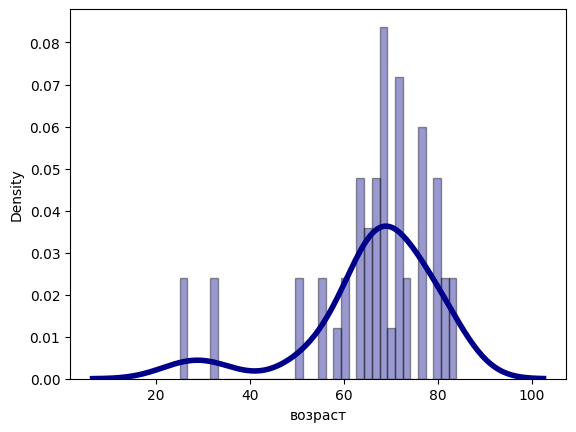

In [ ]:
sns.distplot(data_glaucoma_all['возраст'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['возраст']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.840, p-value=0.000
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['возраст']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=22.674, p-value=0.000
Отклонить гипотезу о нормальности




---








### Величина внутриглазного давления

<ipython-input-712-783dfb2660ec>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['величина внутриглазного давления'], hist=True, kde=True,


<Axes: xlabel='величина внутриглазного давления', ylabel='Density'>

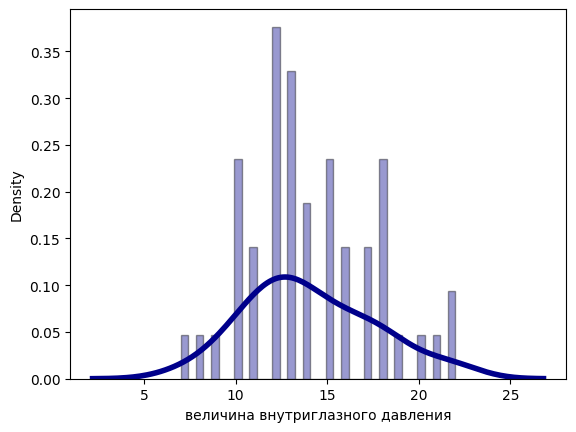

In [ ]:
sns.distplot(data_glaucoma_all['величина внутриглазного давления'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['величина внутриглазного давления']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.971, p-value=0.242
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['величина внутриглазного давления']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.589, p-value=0.452
Принять гипотезу о нормальности




---








### ВГД, корригированного на коэффициент ригидности



<ipython-input-715-5475ef1d4e2c>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['ВГД, корригированного на коэффициент ригидности'], hist=True, kde=True,


<Axes: xlabel='ВГД, корригированного на коэффициент ригидности', ylabel='Density'>

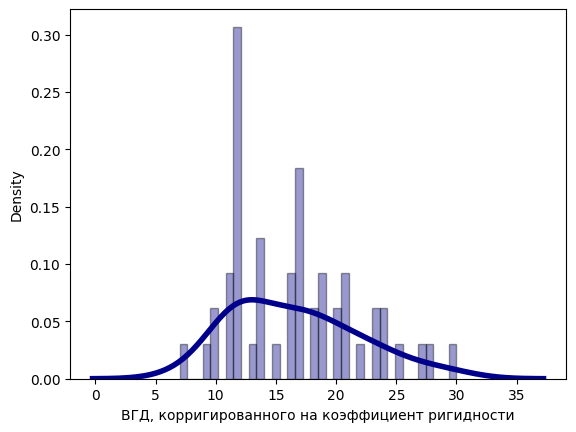

In [ ]:
sns.distplot(data_glaucoma_all['ВГД, корригированного на коэффициент ригидности'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['ВГД, корригированного на коэффициент ригидности']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.956, p-value=0.057
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['ВГД, корригированного на коэффициент ригидности']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=3.056, p-value=0.217
Принять гипотезу о нормальности




---








### Коэффициент ригидности склеральной капсулы глаза

<ipython-input-718-ffc1148cd9a6>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['Коэфф ригидности склеральн капсулы глаза'], hist=True, kde=True,


<Axes: xlabel='Коэфф ригидности склеральн капсулы глаза', ylabel='Density'>

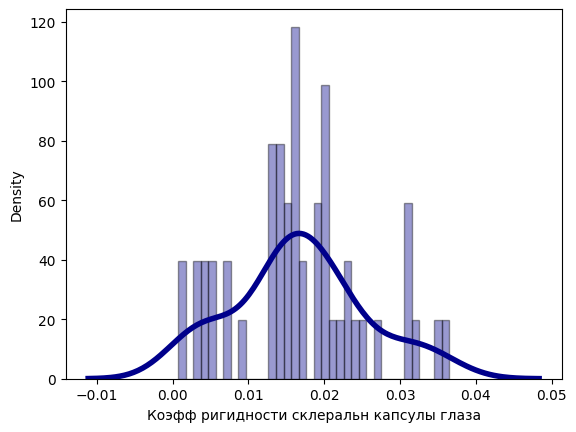

In [ ]:
sns.distplot(data_glaucoma_all['Коэфф ригидности склеральн капсулы глаза'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['Коэфф ригидности склеральн капсулы глаза']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.967, p-value=0.170
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['Коэфф ригидности склеральн капсулы глаза']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.404, p-value=0.817
Принять гипотезу о нормальности




---








### Роговично-компенсированное ВГД

<ipython-input-721-5843869e868b>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['Роговично-компенсированное ВГД'], hist=True, kde=True,


<Axes: xlabel='Роговично-компенсированное ВГД', ylabel='Density'>

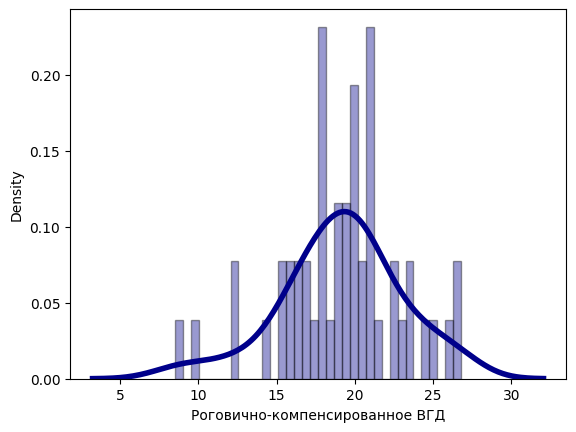

In [ ]:
sns.distplot(data_glaucoma_all['Роговично-компенсированное ВГД'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['Роговично-компенсированное ВГД']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.974, p-value=0.321
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['Роговично-компенсированное ВГД']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=3.064, p-value=0.216
Принять гипотезу о нормальности




---








### ВГД по Гольдману

<ipython-input-724-217d8865aea7>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['ВГД по Гольдману'], hist=True, kde=True,


<Axes: xlabel='ВГД по Гольдману', ylabel='Density'>

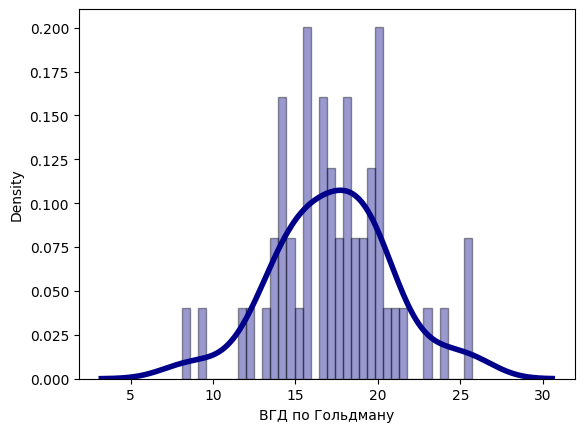

In [ ]:
sns.distplot(data_glaucoma_all['ВГД по Гольдману'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['ВГД по Гольдману']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.984, p-value=0.704
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['ВГД по Гольдману']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.070, p-value=0.586
Принять гипотезу о нормальности




---








### Фактор резистентности роговицы

<ipython-input-727-b10f0674164d>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['Фактор резистентности роговицы'], hist=True, kde=True,


<Axes: xlabel='Фактор резистентности роговицы', ylabel='Density'>

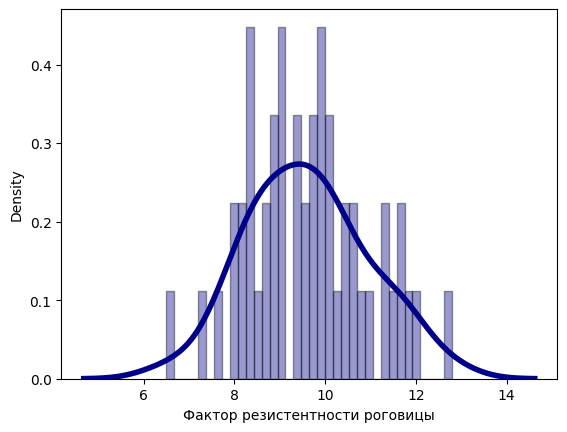

In [ ]:
sns.distplot(data_glaucoma_all['Фактор резистентности роговицы'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['Фактор резистентности роговицы']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.989, p-value=0.921
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['Фактор резистентности роговицы']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.416, p-value=0.812
Принять гипотезу о нормальности




---








### КГ

<ipython-input-730-70b3e0aefb49>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['КГ'], hist=True, kde=True,


<Axes: xlabel='КГ', ylabel='Density'>

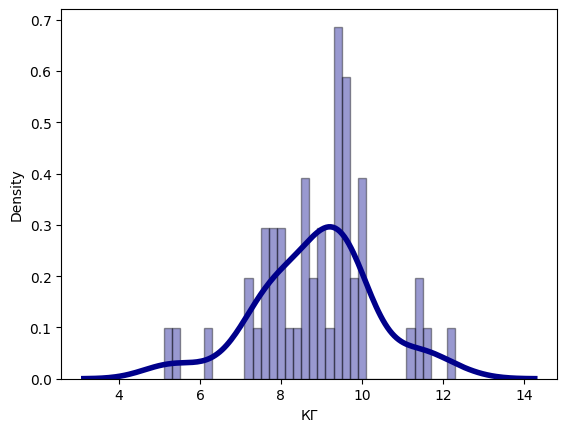

In [ ]:
sns.distplot(data_glaucoma_all['КГ'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['КГ']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.967, p-value=0.166
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['КГ']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=2.259, p-value=0.323
Принять гипотезу о нормальности




---








### ЦТР

<ipython-input-733-7b6b00e29f6b>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['ЦТР'], hist=True, kde=True,


<Axes: xlabel='ЦТР', ylabel='Density'>

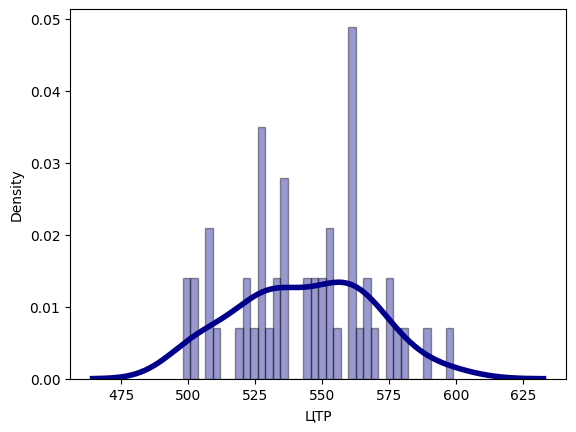

In [ ]:
sns.distplot(data_glaucoma_all['ЦТР'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['ЦТР']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.978, p-value=0.458
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['ЦТР']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.397, p-value=0.497
Принять гипотезу о нормальности




---








### РП

<ipython-input-736-b6a641766e54>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['РП'], hist=True, kde=True,


<Axes: xlabel='РП', ylabel='Density'>

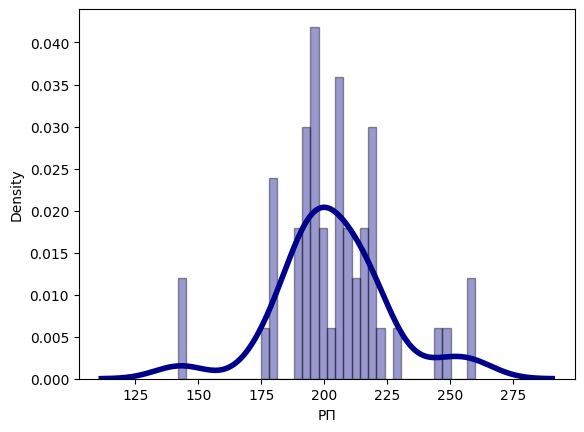

In [ ]:
sns.distplot(data_glaucoma_all['РП'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['РП']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.934, p-value=0.007
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['РП']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=4.660, p-value=0.097
Принять гипотезу о нормальности




---








### ГлРП

<ipython-input-739-9b6a400edfe1>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['ГлРП'], hist=True, kde=True,


<Axes: xlabel='ГлРП', ylabel='Density'>

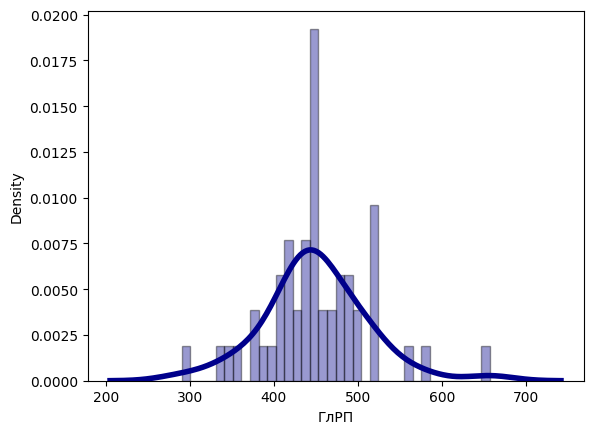

In [ ]:
sns.distplot(data_glaucoma_all['ГлРП'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['ГлРП']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.965, p-value=0.137
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['ГлРП']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=6.576, p-value=0.037
Отклонить гипотезу о нормальности


### gamma Ш

<ipython-input-742-1c77d68868f0>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['gamma Ш'], hist=True, kde=True,


<Axes: xlabel='gamma Ш', ylabel='Density'>

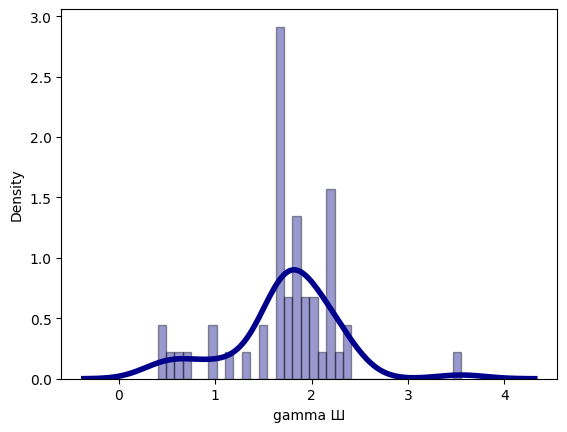

In [ ]:
sns.distplot(data_glaucoma_all['gamma Ш'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['gamma Ш']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.895, p-value=0.000
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['gamma Ш']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=5.866, p-value=0.053
Принять гипотезу о нормальности




---










---








### Efrid

<ipython-input-745-4731306f7f42>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['Efrid'], hist=True, kde=True,


<Axes: xlabel='Efrid', ylabel='Density'>

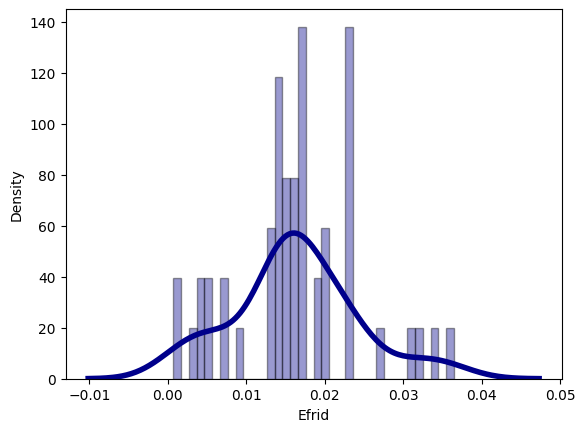

In [ ]:
sns.distplot(data_glaucoma_all['Efrid'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['Efrid']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.955, p-value=0.053
Принять гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['Efrid']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.557, p-value=0.459
Принять гипотезу о нормальности




---








### SVL

<ipython-input-748-5f5e85b5e12f>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['SVL'], hist=True, kde=True,


<Axes: xlabel='SVL', ylabel='Density'>

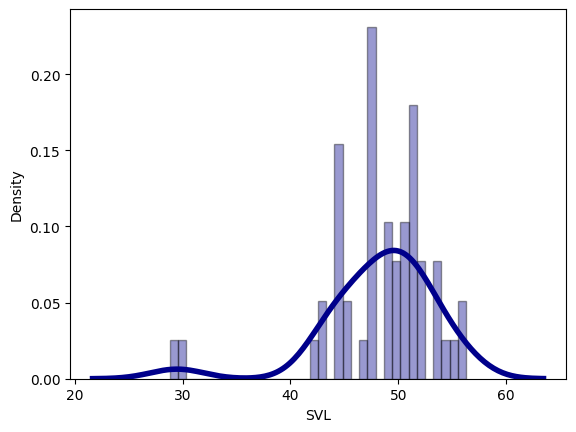

In [ ]:
sns.distplot(data_glaucoma_all['SVL'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['SVL']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.861, p-value=0.000
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['SVL']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=28.872, p-value=0.000
Отклонить гипотезу о нормальности




---








### DVL

<ipython-input-751-0130d445d8d3>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['DVL'], hist=True, kde=True,


<Axes: xlabel='DVL', ylabel='Density'>

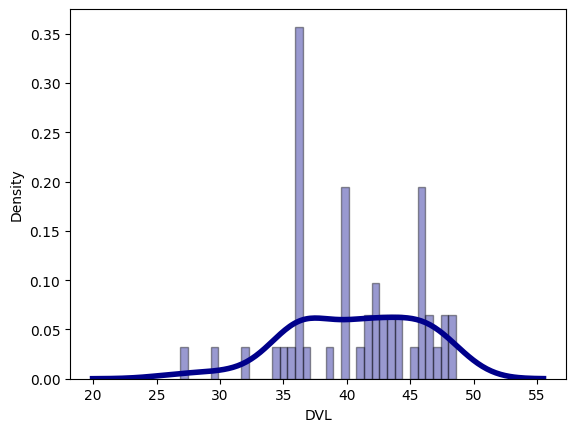

In [ ]:
sns.distplot(data_glaucoma_all['DVL'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['DVL']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.952, p-value=0.040
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['DVL']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=1.727, p-value=0.422
Принять гипотезу о нормальности




---








### РИ (рео. индекс) мОм

<ipython-input-754-c0afc8057ce5>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['РИ (рео.индекс) мОм'], hist=True, kde=True,


<Axes: xlabel='РИ (рео.индекс) мОм', ylabel='Density'>

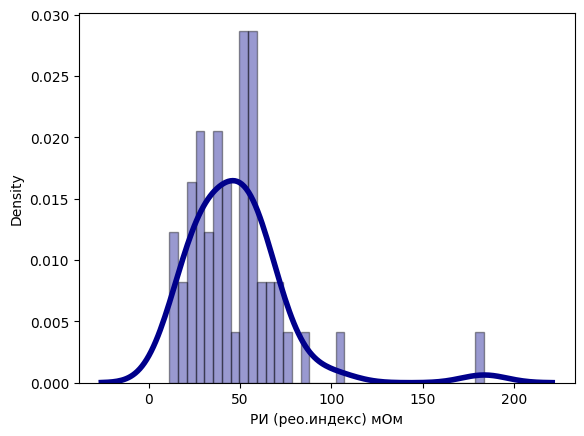

In [ ]:
sns.distplot(data_glaucoma_all['РИ (рео.индекс) мОм'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['РИ (рео.индекс) мОм']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.797, p-value=0.000
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['РИ (рео.индекс) мОм']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=50.439, p-value=0.000
Отклонить гипотезу о нормальности




---








### ПМН (макс. нап)

<ipython-input-757-939f0b639d83>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['ПМН (макс.нап)'], hist=True, kde=True,


<Axes: xlabel='ПМН (макс.нап)', ylabel='Density'>

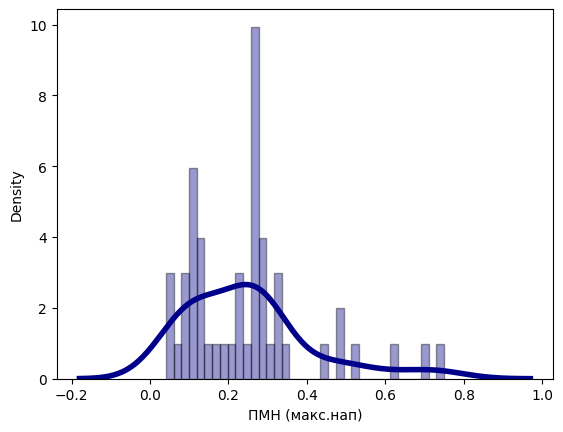

In [ ]:
sns.distplot(data_glaucoma_all['ПМН (макс.нап)'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['ПМН (макс.нап)']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.879, p-value=0.000
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['ПМН (макс.нап)']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=16.421, p-value=0.000
Отклонить гипотезу о нормальности




---








### ПМУ (мод.упр.)

<ipython-input-760-f2584c8a1941>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['ПМУ (мод.упр.)'], hist=True, kde=True,


<Axes: xlabel='ПМУ (мод.упр.)', ylabel='Density'>

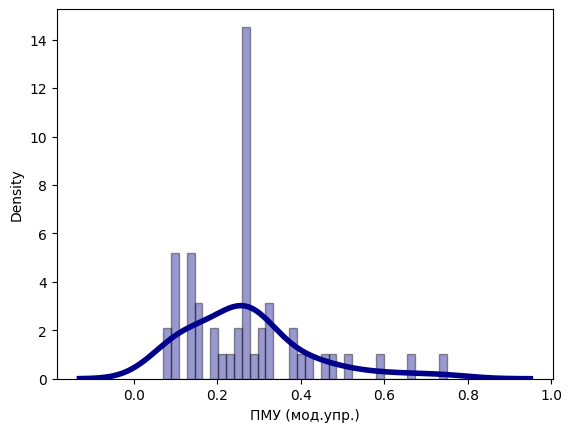

In [ ]:
sns.distplot(data_glaucoma_all['ПМУ (мод.упр.)'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['ПМУ (мод.упр.)']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.901, p-value=0.000
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['ПМУ (мод.упр.)']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=15.139, p-value=0.001
Отклонить гипотезу о нормальности




---








### Z баз. (отн.)

<ipython-input-763-50e130b6cbf3>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['Z баз.(отн.))'], hist=True, kde=True,


<Axes: xlabel='Z баз.(отн.))', ylabel='Density'>

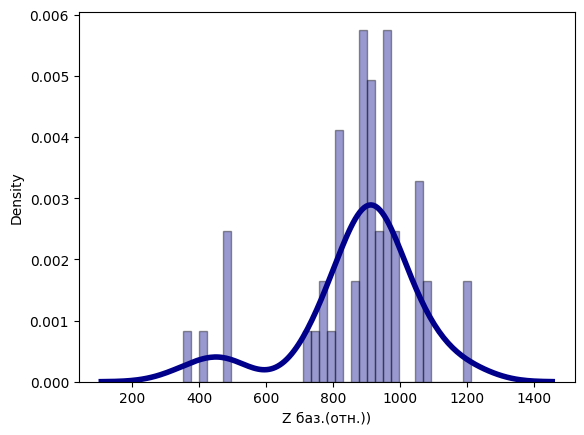

In [ ]:
sns.distplot(data_glaucoma_all['Z баз.(отн.))'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['Z баз.(отн.))']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.875, p-value=0.000
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['Z баз.(отн.))']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=15.538, p-value=0.000
Отклонить гипотезу о нормальности




---








### Z баз. (мОм)

<ipython-input-766-5826f2f08ecb>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['Z баз.(мОм)'], hist=True, kde=True,


<Axes: xlabel='Z баз.(мОм)', ylabel='Density'>

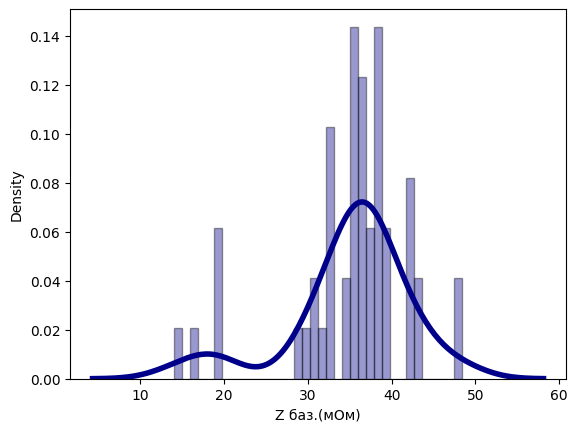

In [ ]:
sns.distplot(data_glaucoma_all['Z баз.(мОм)'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['Z баз.(мОм)']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.875, p-value=0.000
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['Z баз.(мОм)']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=15.538, p-value=0.000
Отклонить гипотезу о нормальности




---








### УОК (уд. объем) мкл

<ipython-input-769-3fc43bc8d2fe>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_glaucoma_all['УОК (уд.объем) мкл'], hist=True, kde=True,


<Axes: xlabel='УОК (уд.объем) мкл', ylabel='Density'>

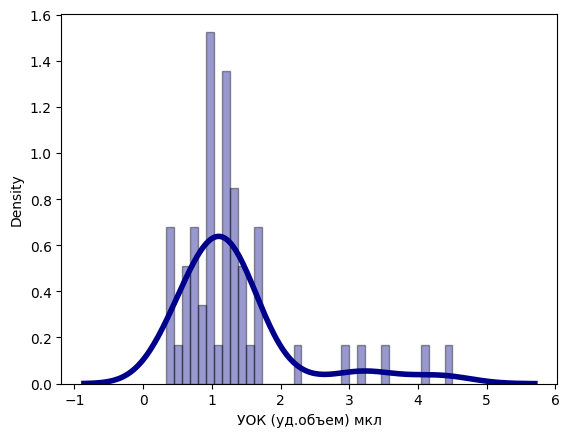

In [ ]:
sns.distplot(data_glaucoma_all['УОК (уд.объем) мкл'], hist=True, kde=True,
             bins=int(180/5), color = 'darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})

In [ ]:
stat, p = scipy.stats.shapiro(data_glaucoma_all['УОК (уд.объем) мкл']) # тест Шапиро-Уилк
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=0.764, p-value=0.000
Отклонить гипотезу о нормальности


In [ ]:
stat, p = scipy.stats.normaltest(data_glaucoma_all['УОК (уд.объем) мкл']) # Критерий согласия Пирсона
print('Statistics=%.3f, p-value=%.3f' % (stat, p))

alpha = 0.05
if p > alpha:
    print('Принять гипотезу о нормальности')
else:
    print('Отклонить гипотезу о нормальности')

Statistics=33.550, p-value=0.000
Отклонить гипотезу о нормальности




---








# Задача 3. Проверить наличие корреляций для объединенной группы пациентов (здоровые и все стадии ПОУГ) и для каждой группы в отдельности.

data_glaucoma_all - данные обо всех пациентах в одной таблице

In [ ]:
data_glaucoma_all

,Фамилия,возраст,стадия,величина внутриглазного давления,"ВГД, корригированного на коэффициент ригидности",Коэфф ригидности склеральн капсулы глаза,Роговично-компенсированное ВГД,ВГД по Гольдману,Фактор резистентности роговицы,КГ,...,gamma Ш,Efrid,SVL,DVL,РИ (рео.индекс) мОм,ПМН (макс.нап),ПМУ (мод.упр.),Z баз.(отн.)),Z баз.(мОм),УОК (уд.объем) мкл
0,уланкина,25,0,10,12,0.0162,9.70,9.40,9.30,11.3,...,1.75,0.0162,56.300000,46.030000,49.650,0.27,0.250,979,39.16,1.157570
1,степанова,26,0,12,15,0.0162,18.50,19.90,12.80,11.6,...,1.85,0.0162,50.960000,44.210000,51.555,0.28,0.275,948,37.92,1.252867
2,кудасов,32,0,10,12,0.0162,14.30,12.00,8.30,9.2,...,1.70,0.0138,53.580000,47.400000,102.330,0.13,0.140,1060,42.40,2.203474
3,Иванов,32,0,10,12,0.0162,17.60,13.90,7.60,7.6,...,1.70,0.0138,56.297266,45.462070,58.430,0.20,0.210,1063,42.52,1.254623
4,гладих,68,0,10,14,0.0138,20.10,17.20,8.80,7.9,...,1.75,0.0138,48.680000,45.880000,20.970,0.13,0.140,725,29.00,0.660193
5,мыздриков,59,0,12,14,0.0161,8.50,8.10,9.10,11.4,...,1.85,0.0161,53.560000,48.420000,35.500,0.52,0.420,917,36.68,0.883629
6,Савинова,66,0,15,23,0.0076,17.80,15.60,9.10,9.6,...,1.30,0.0076,48.710000,45.880000,49.880,0.29,0.300,910,36.40,1.251111
7,Иванов,66,0,12,16,0.0140,17.80,15.60,9.10,9.6,...,1.70,0.0140,52.440000,45.880000,53.230,0.32,0.330,822,32.88,1.478071
8,Мациева,68,0,18,28,0.0052,20.40,20.00,11.30,9.9,...,1.10,0.0052,51.320000,43.700000,51.555,0.28,0.275,948,37.92,1.252867
9,Булат,51,0,12,19,0.0031,17.80,16.50,10.00,9.6,...,0.60,0.0031,52.440000,45.880000,183.500,0.33,0.400,1210,48.40,3.461477


## Критерий Спирмена

Для корректного анализа удалим колонки с фамилией и со стадией

In [ ]:
data_all_for_corr=data_glaucoma_all.drop(columns=['Фамилия', 'стадия'])

In [ ]:
#data_all_for_corr

In [ ]:
glaucoma_all_corr = data_all_for_corr.corr(method='spearman')

In [ ]:
# Визуализация корреляционной матрицы
def plot_corr_matrix(corr_matrix, title):
    plt.figure(figsize=(15, 10))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", annot_kws={"size": 10}, cmap="coolwarm", cbar=True)
    plt.title(title)
    plt.show()

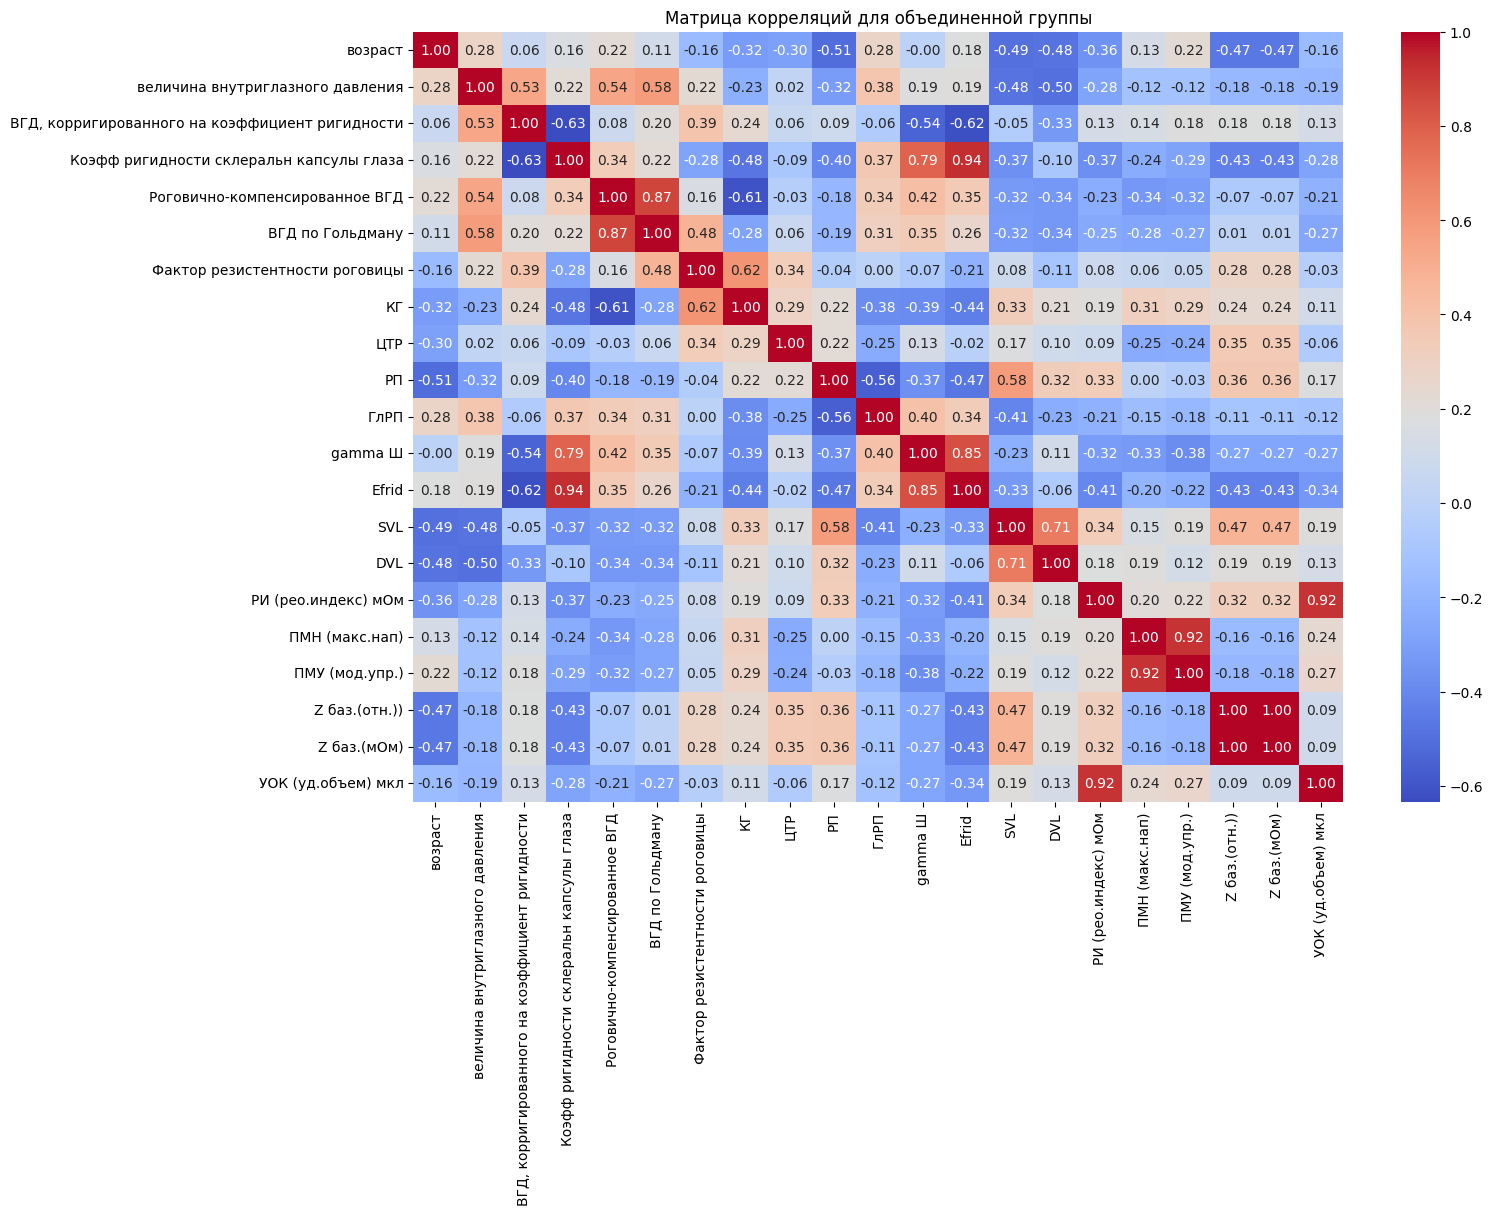

In [ ]:
# Построение матриц
plot_corr_matrix(glaucoma_all_corr, "Матрица корреляций для объединенной группы")

In [ ]:
# Отдельные группы
groups = data_glaucoma_all['стадия'].unique()
group_corrs = {}

In [ ]:
for group in groups:
    group_data = data_glaucoma_all[data_glaucoma_all['стадия'] == group].drop(columns=['Фамилия', 'стадия'])
    group_corrs[group] = group_data.corr(method='spearman')


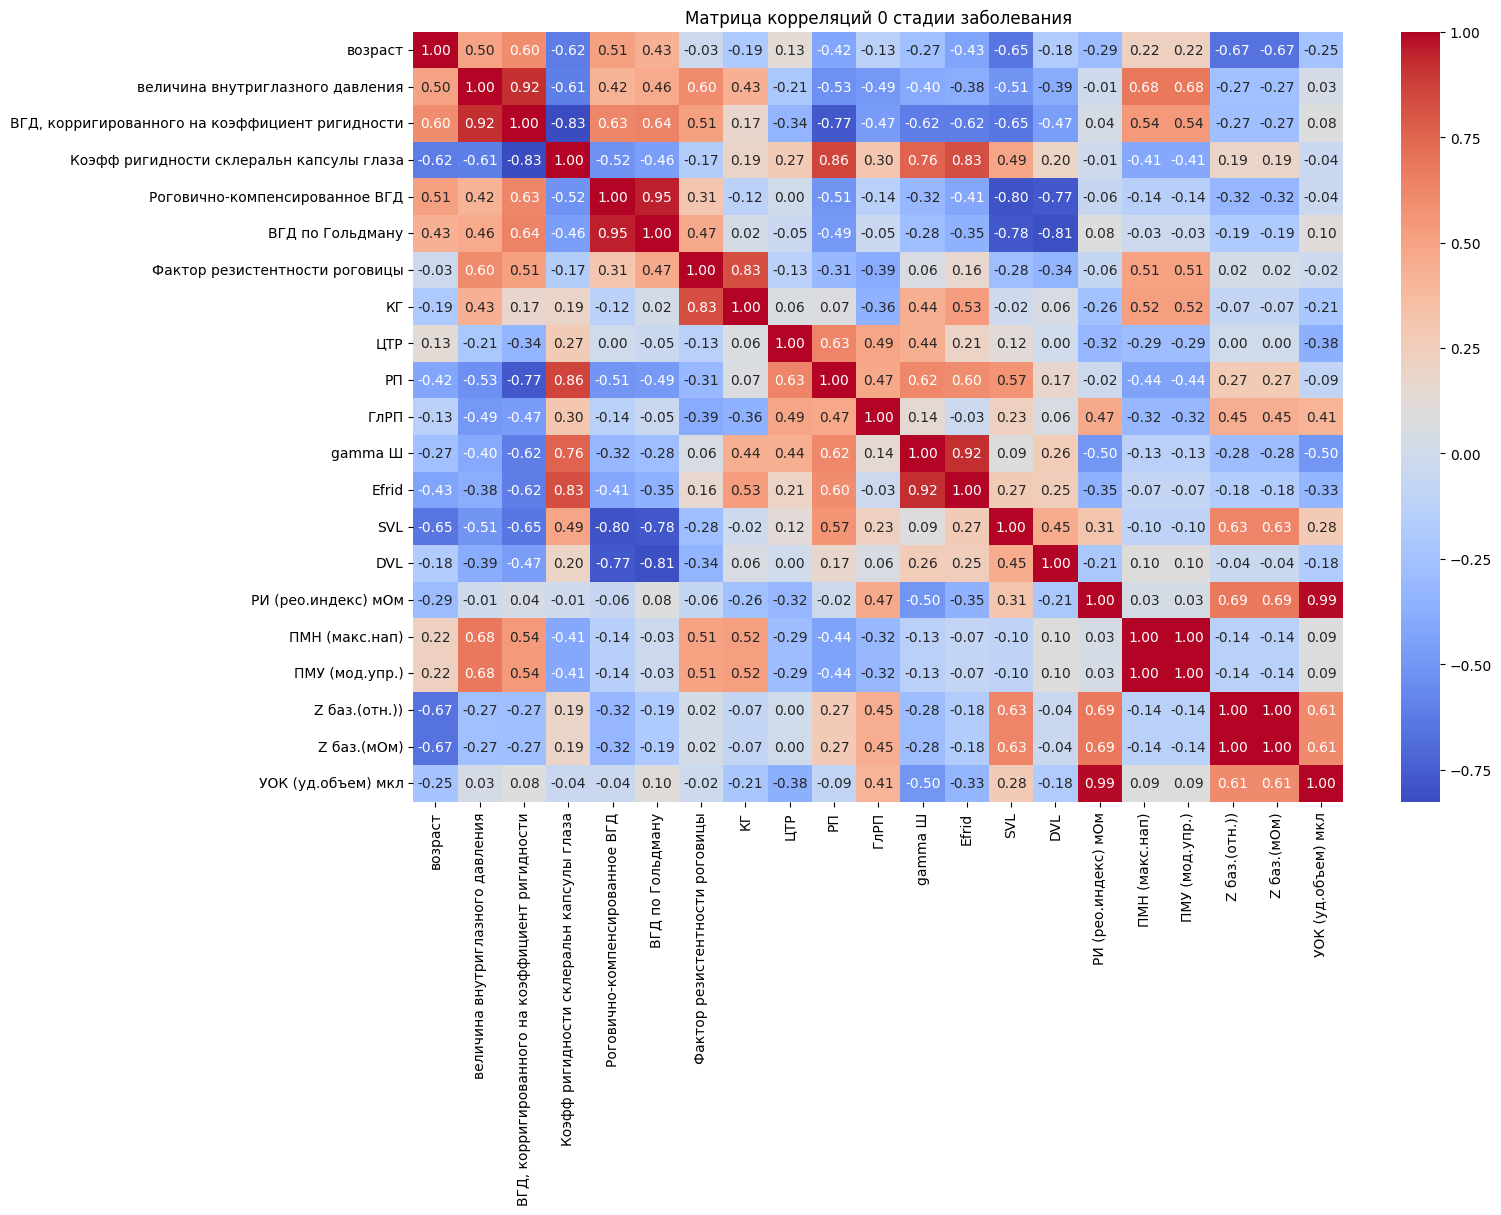

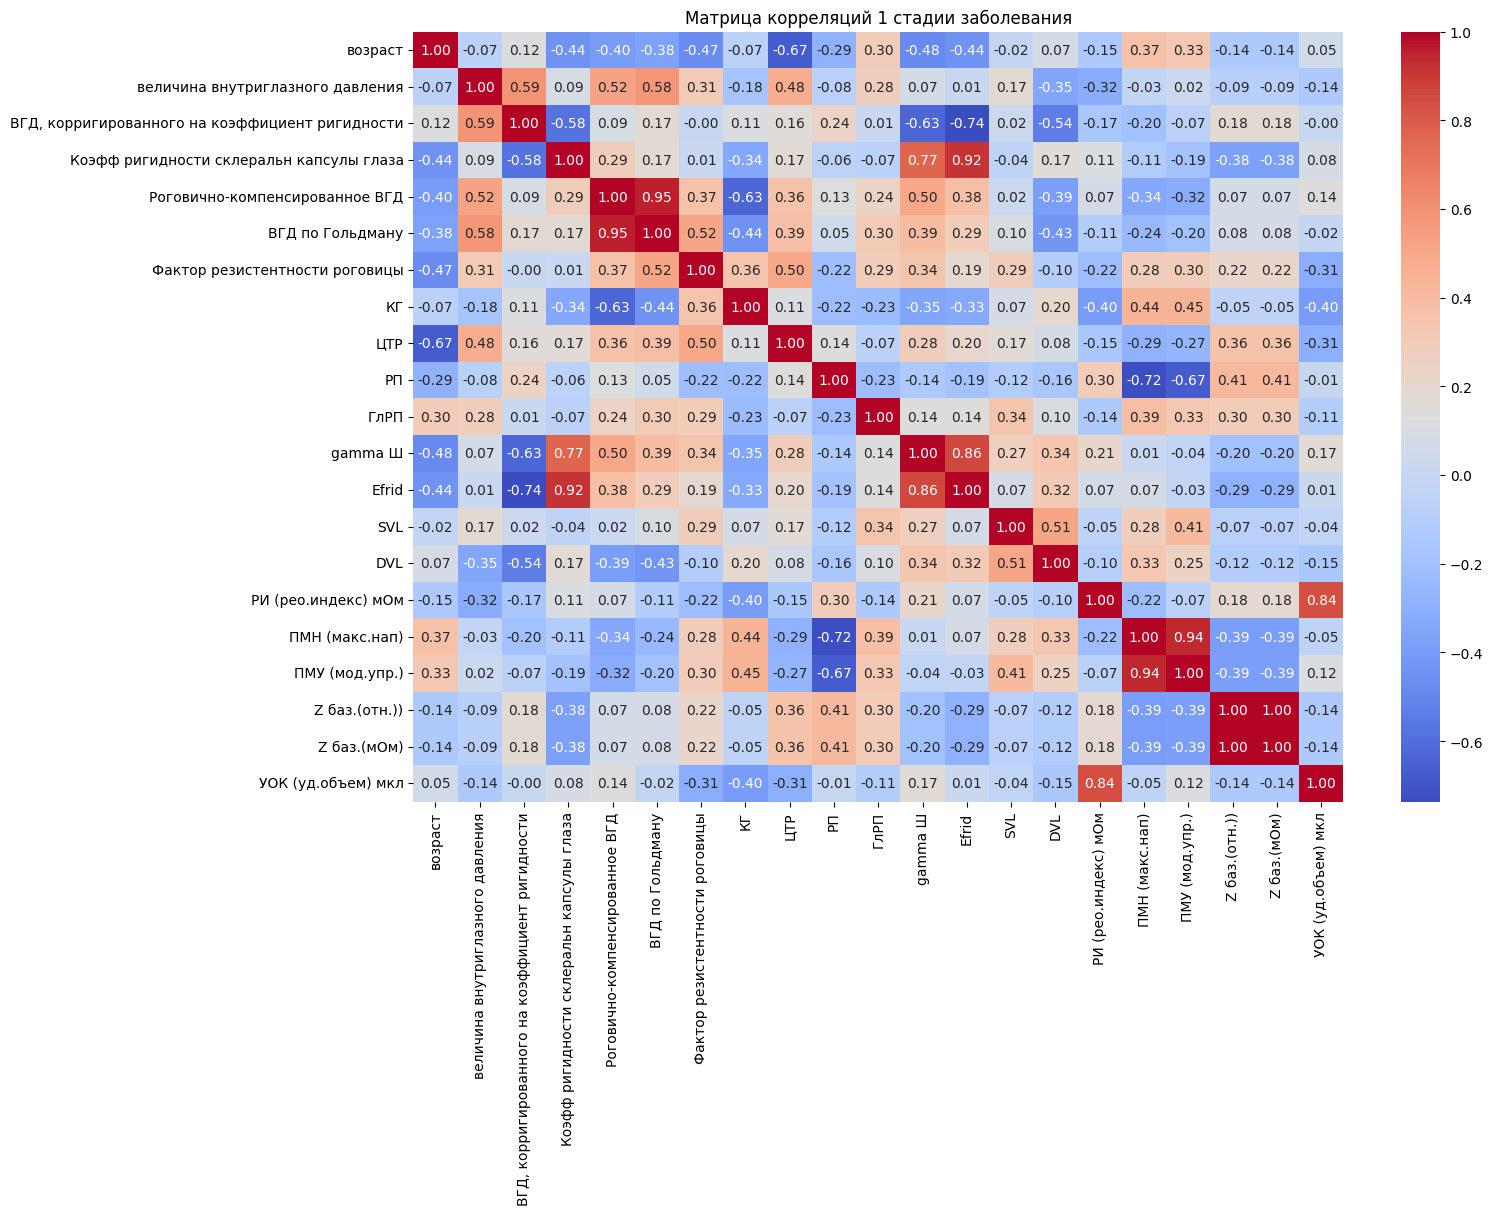

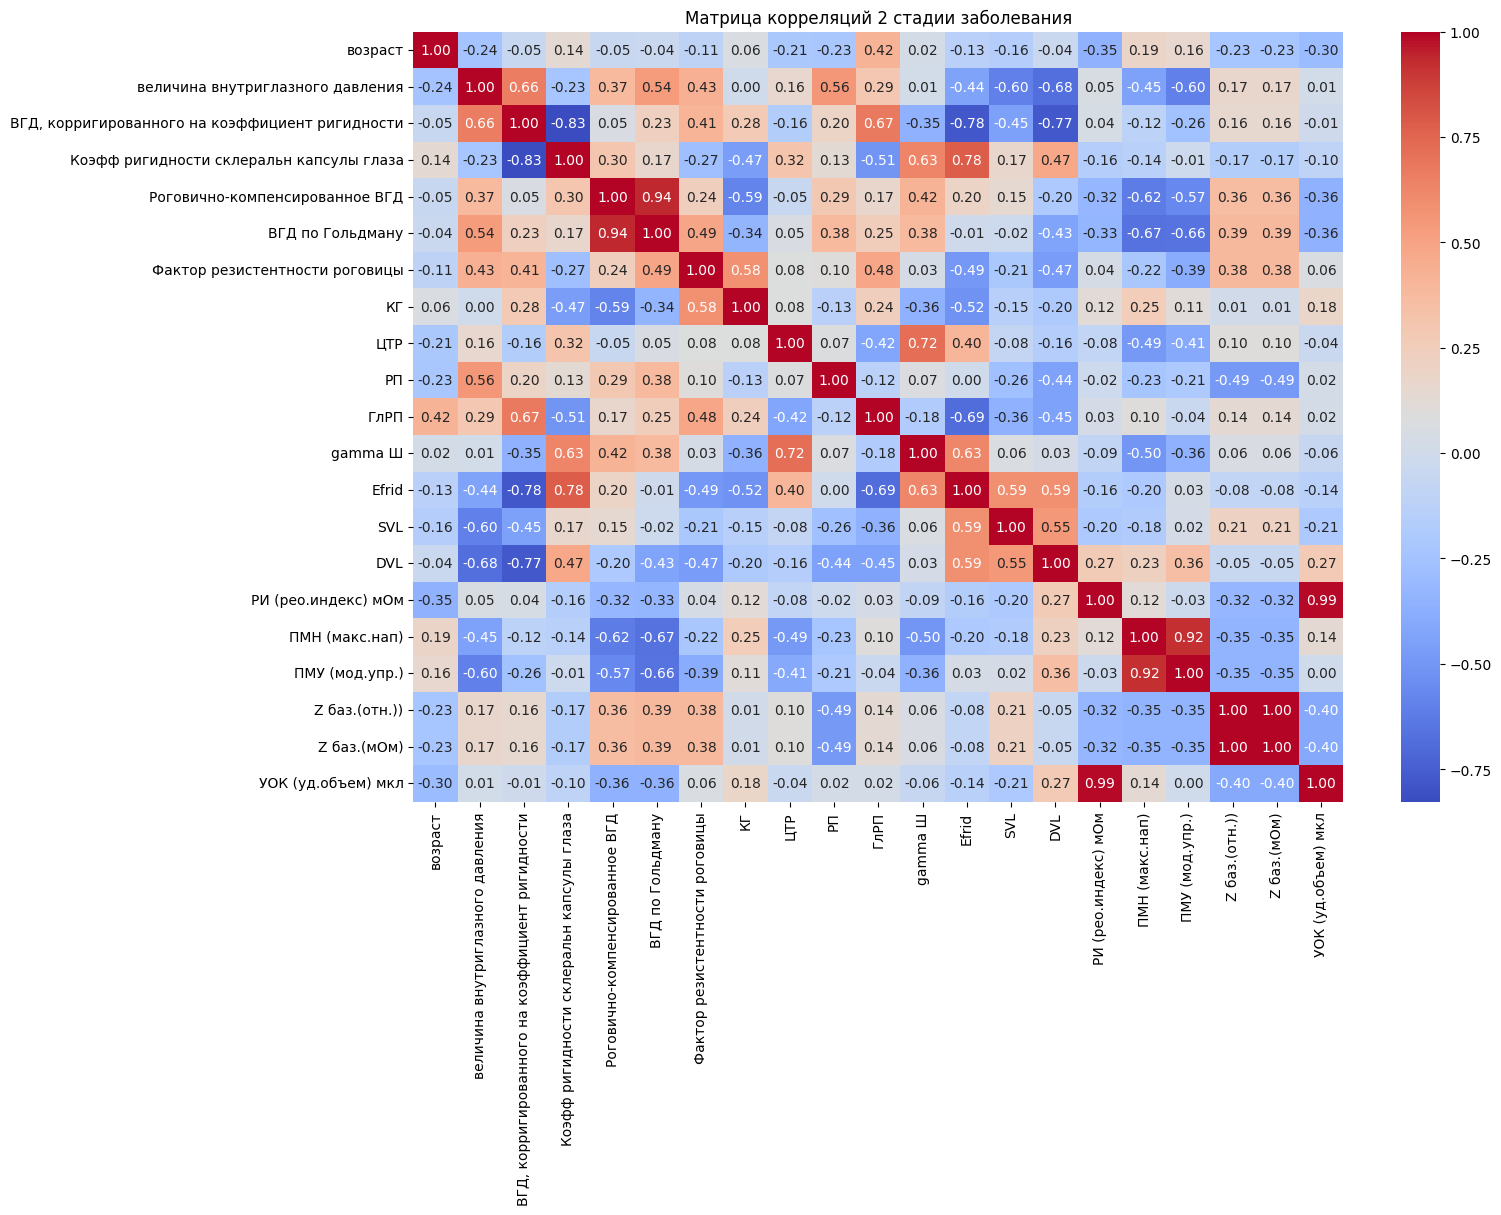

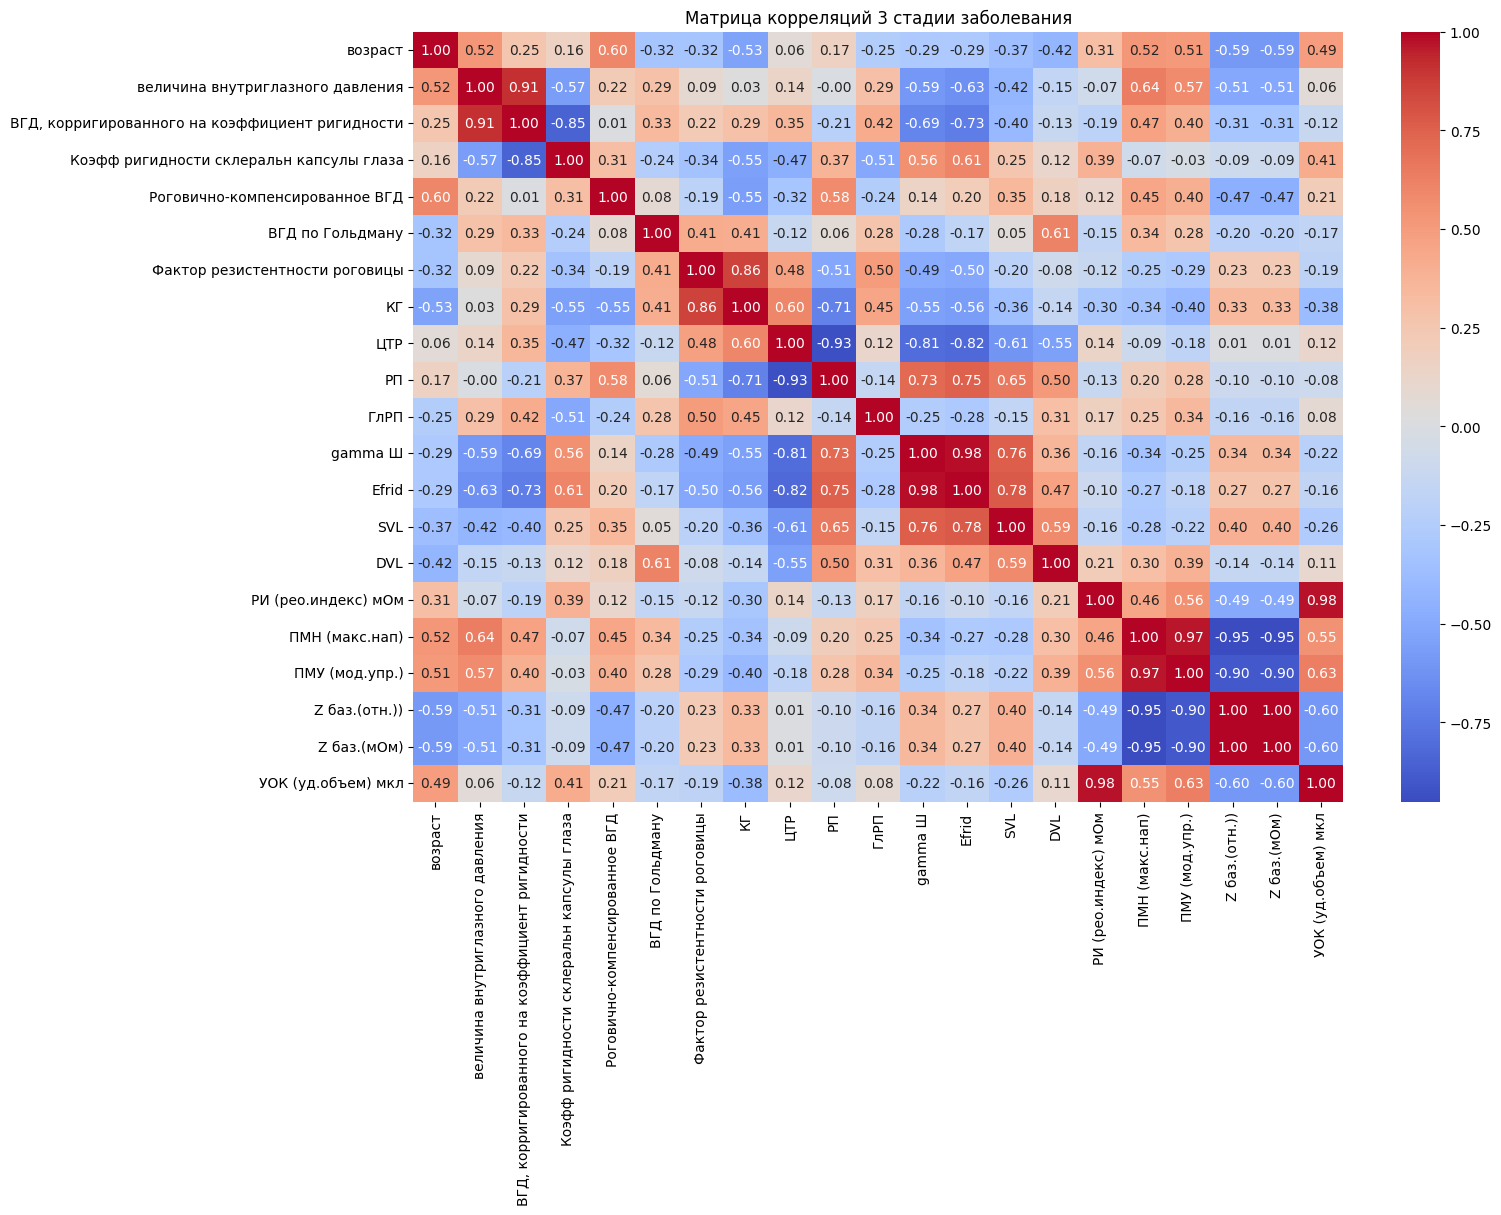

In [ ]:
for group, corr_matrix in group_corrs.items():
    plot_corr_matrix(corr_matrix, f"Матрица корреляций {group} стадии заболевания")


Рассчитаем разницу между корреляциями разных групп

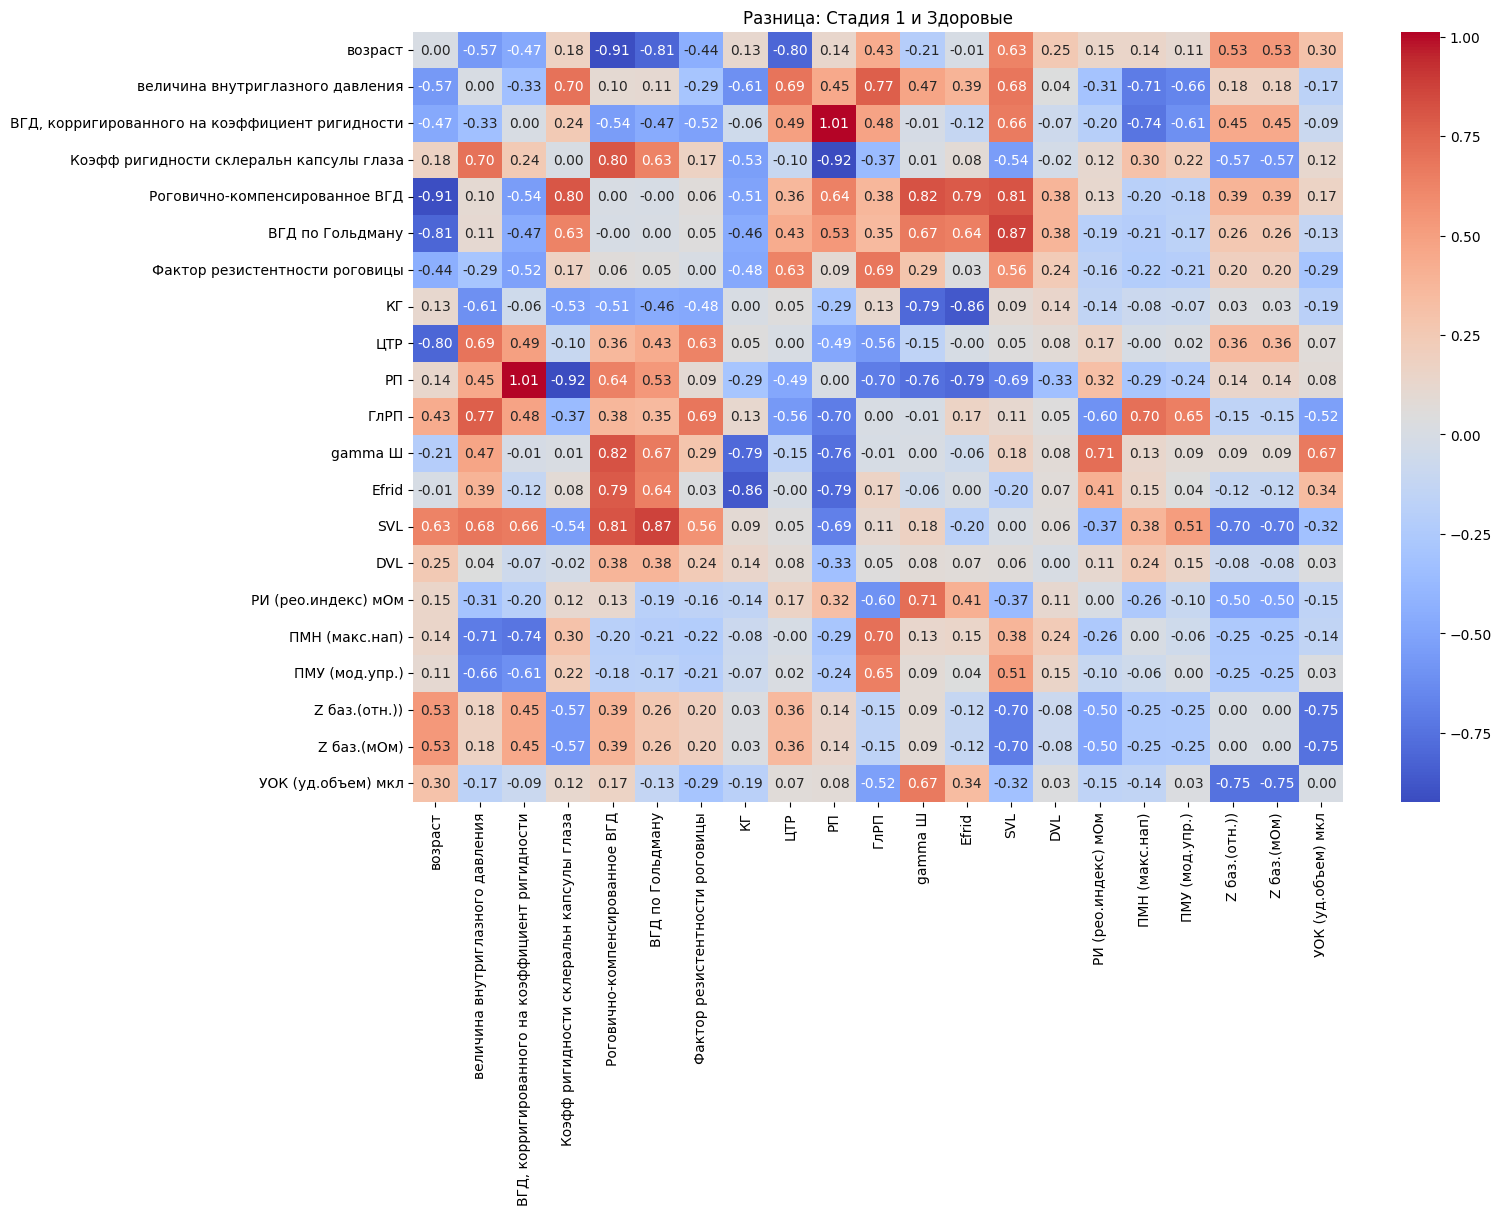

In [ ]:
diff = group_corrs[1] - group_corrs[0]
plot_corr_matrix(diff, "Разница: Стадия 1 и Здоровые")

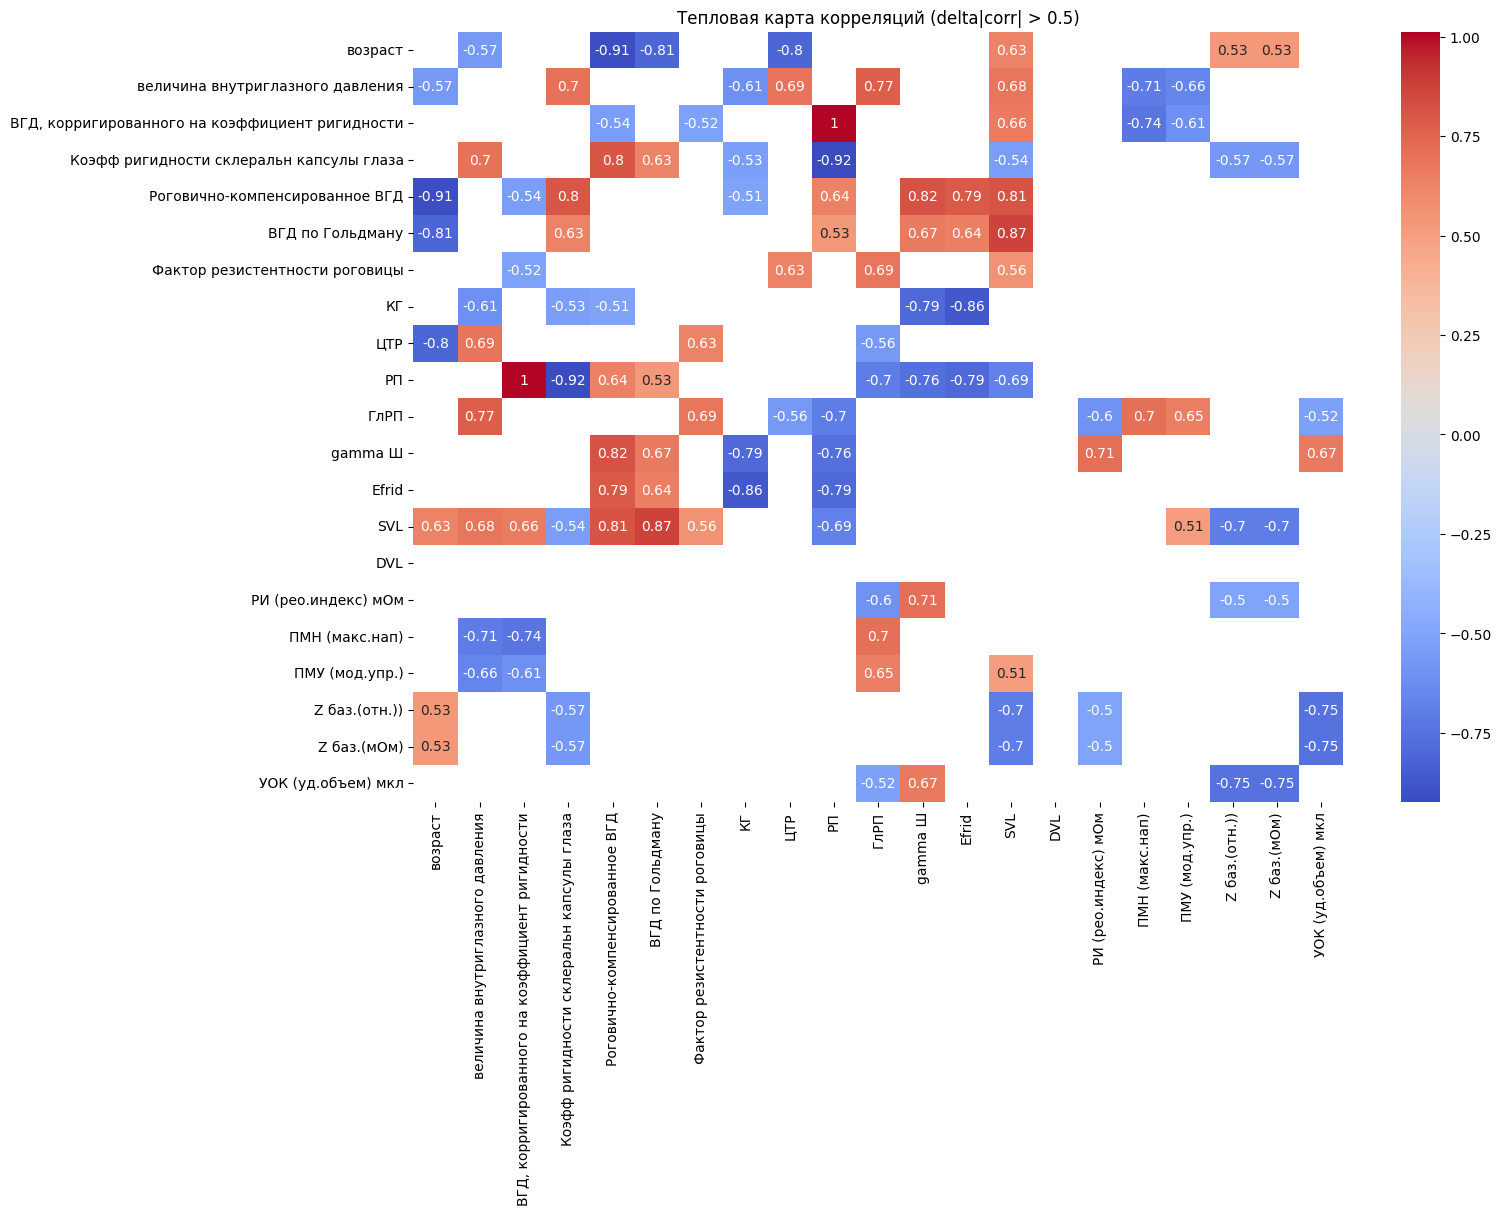

In [ ]:
filtered_diff = diff.copy()
filtered_diff[np.abs(filtered_diff) <= 0.5] = np.nan

#filtered_fiff = diff.where(diff >= 0.5)
plt.figure(figsize=(15, 10))
sns.heatmap(filtered_diff, annot=True, cmap='coolwarm',annot_kws={"size": 10}, cbar=True, mask=filtered_diff.isnull())
plt.title("Тепловая карта корреляций (delta|corr| > 0.5)")
plt.show()

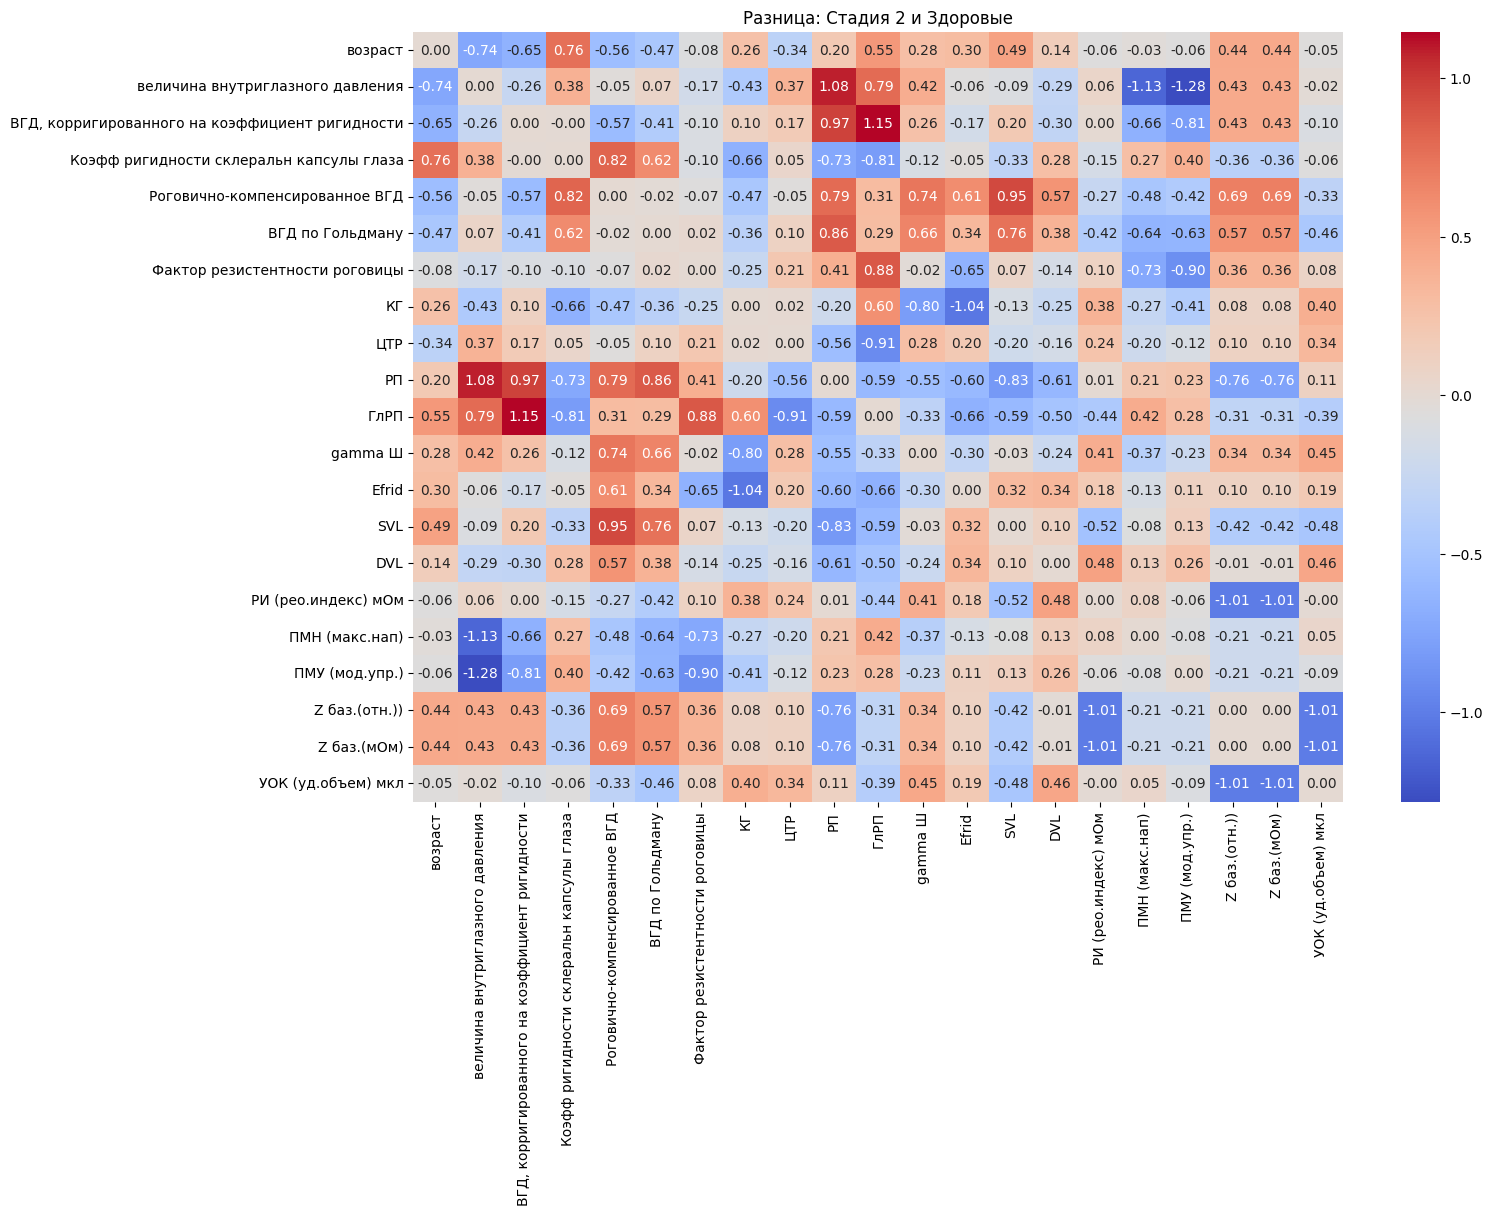

In [ ]:
diff = group_corrs[2] - group_corrs[0]
plot_corr_matrix(diff, "Разница: Стадия 2 и Здоровые")

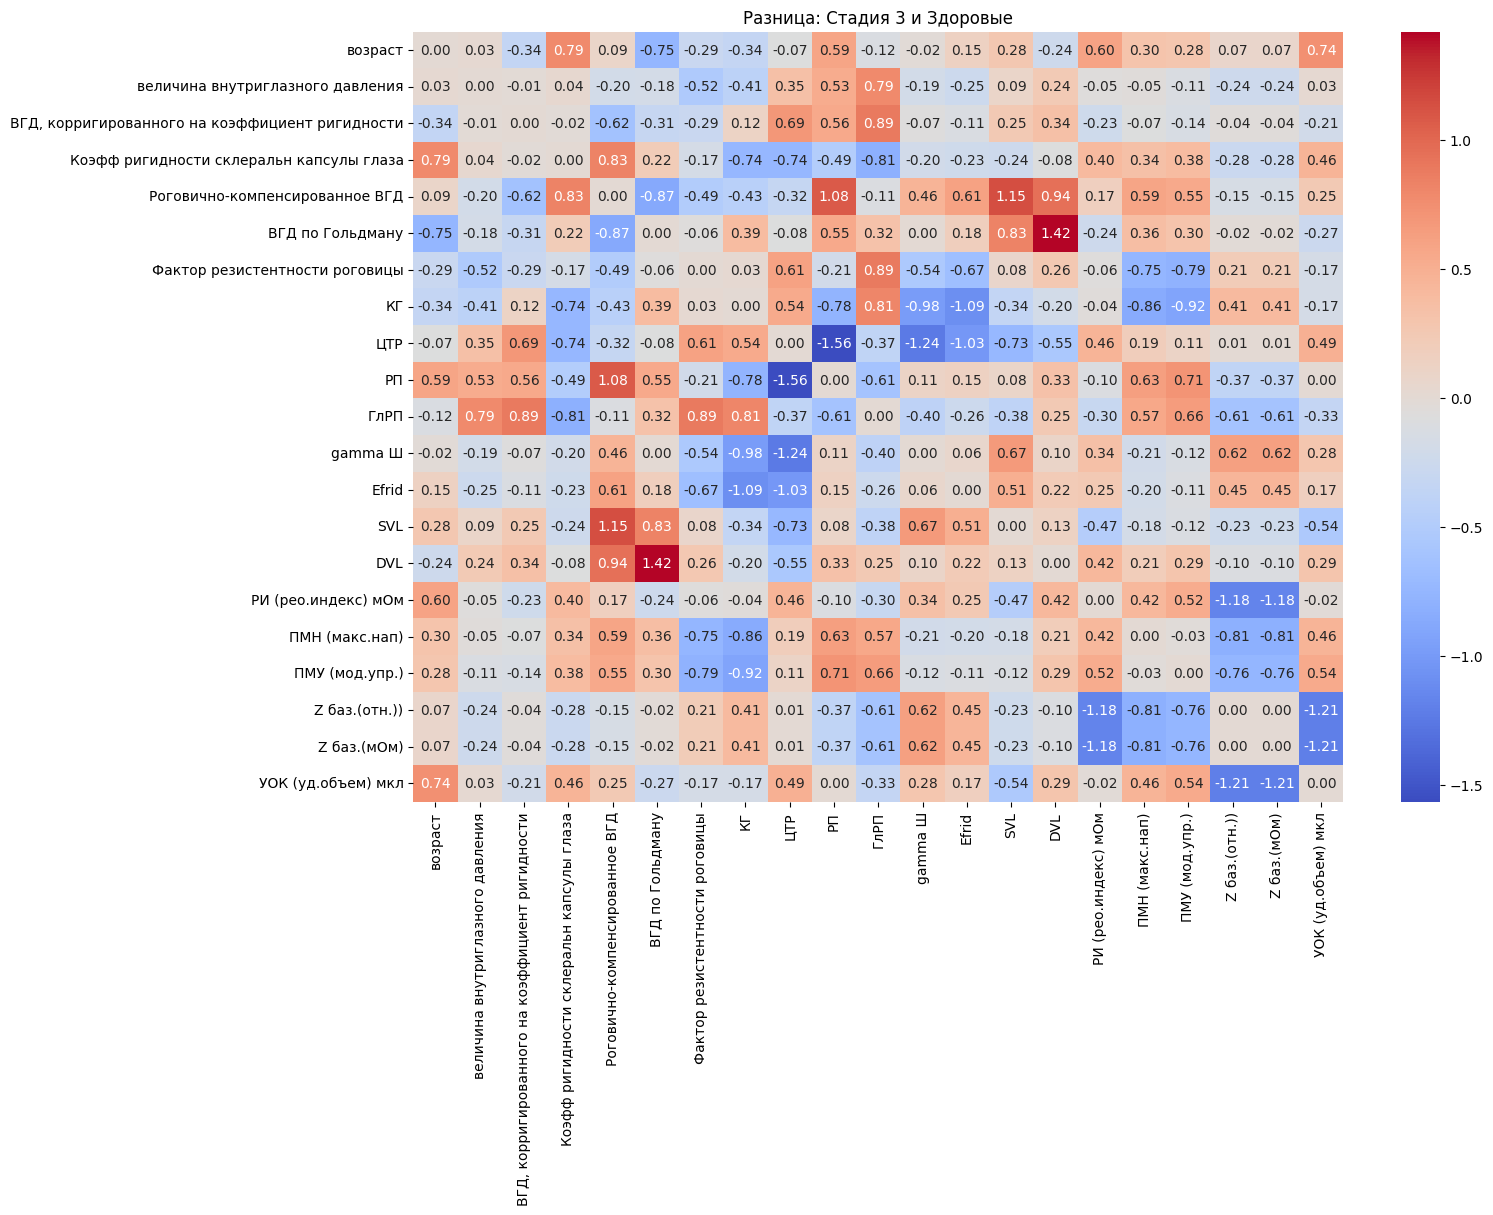

In [ ]:
diff = group_corrs[3] - group_corrs[0]
plot_corr_matrix(diff, "Разница: Стадия 3 и Здоровые")

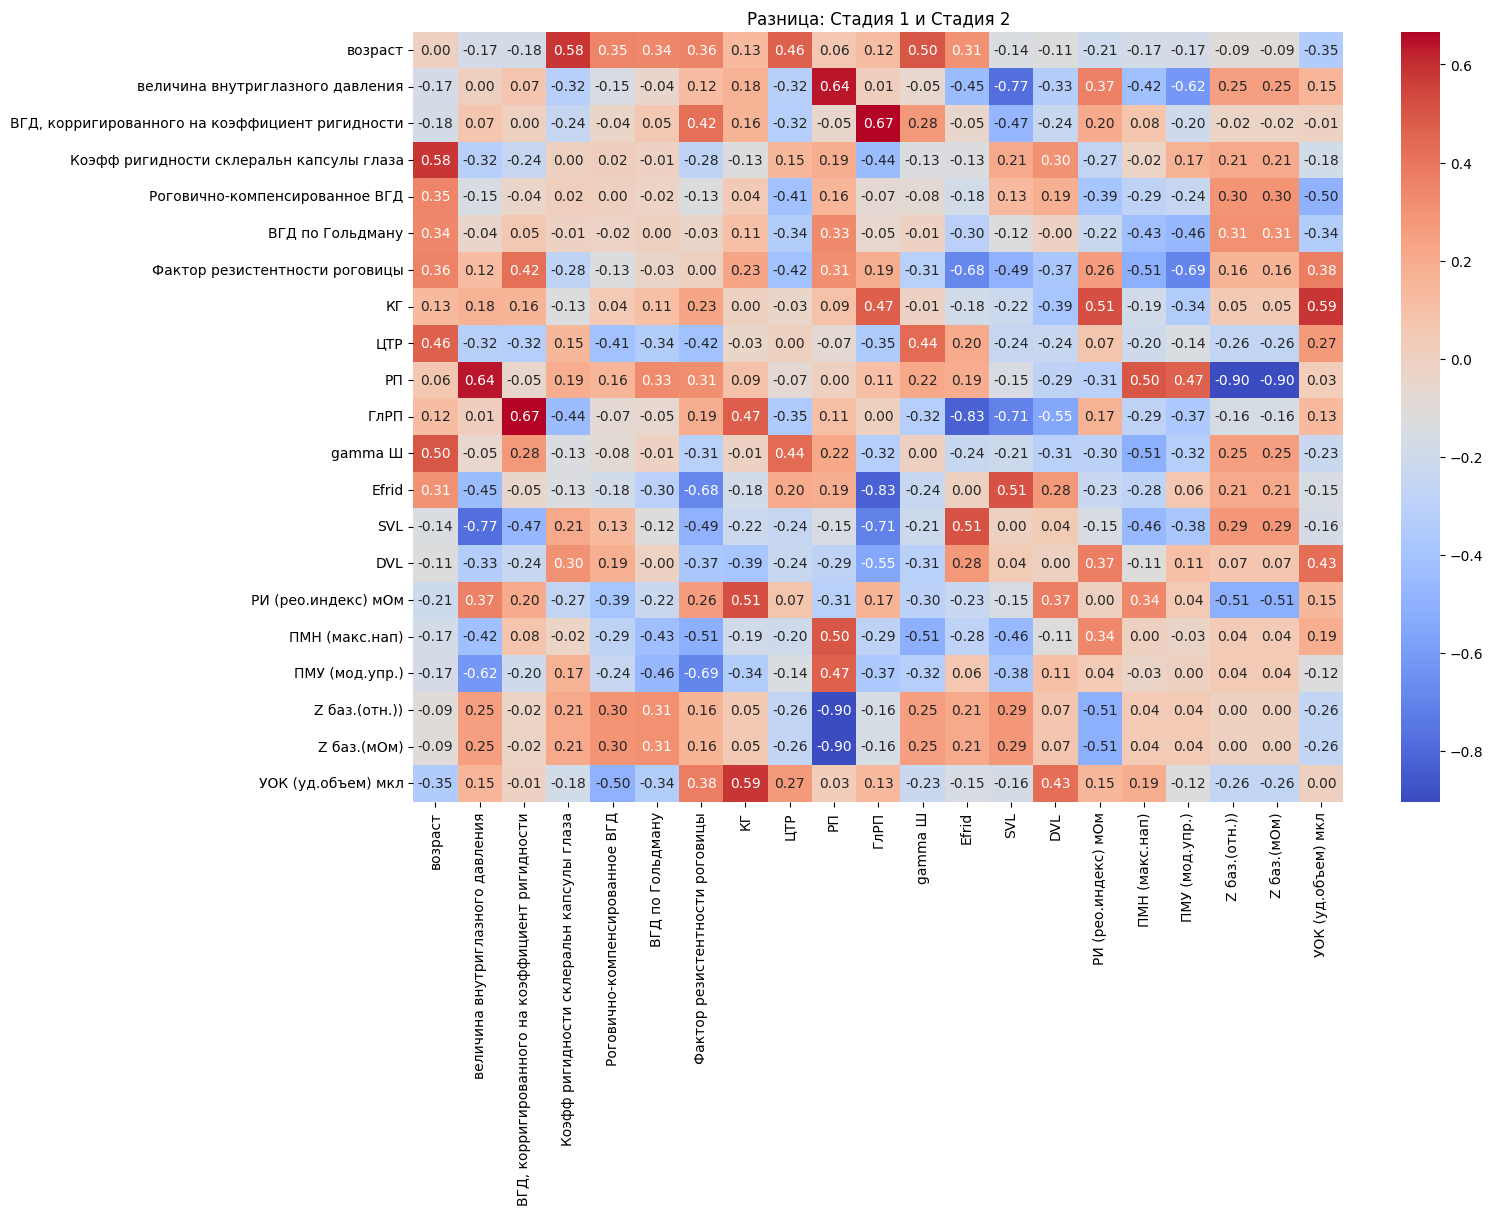

In [ ]:
diff = group_corrs[2] - group_corrs[1]
plot_corr_matrix(diff, "Разница: Стадия 1 и Стадия 2")

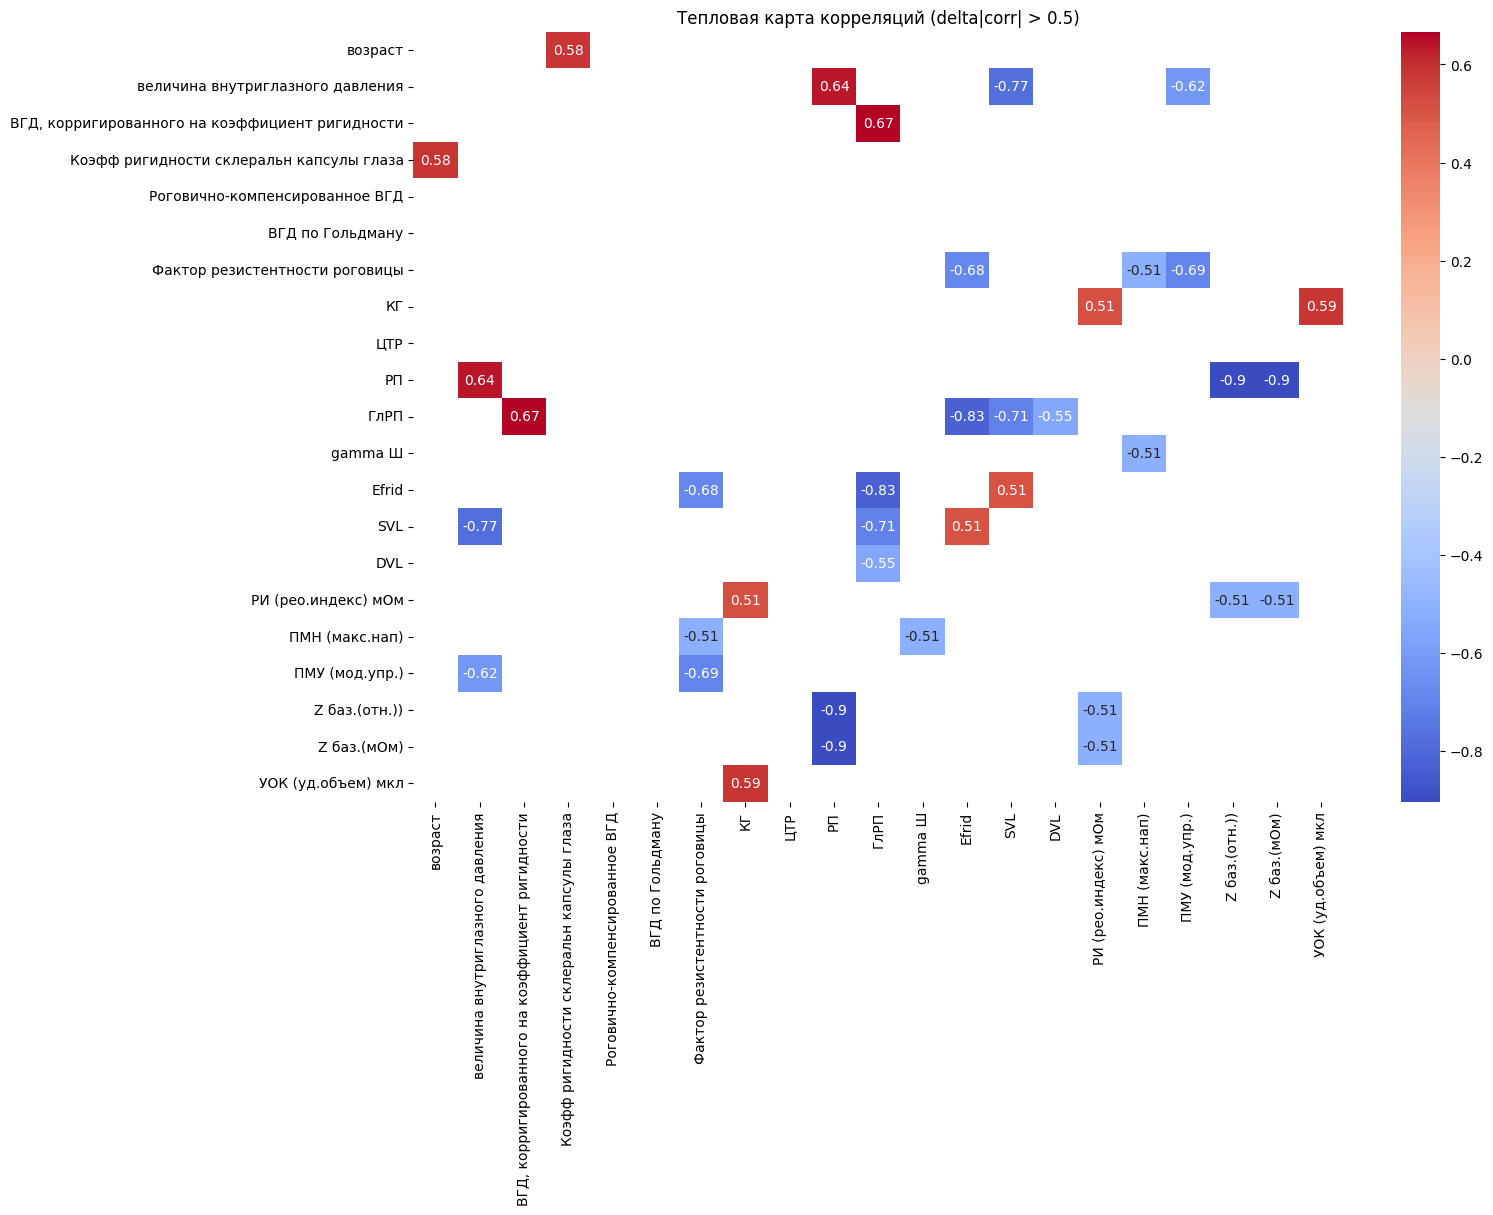

In [ ]:
filtered_diff = diff.copy()
filtered_diff[np.abs(filtered_diff) <= 0.5] = np.nan

#filtered_fiff = diff.where(diff >= 0.5)
plt.figure(figsize=(15, 10))
sns.heatmap(filtered_diff, annot=True, cmap='coolwarm',annot_kws={"size": 10}, cbar=True, mask=filtered_diff.isnull())
plt.title("Тепловая карта корреляций (delta|corr| > 0.5)")
plt.show()

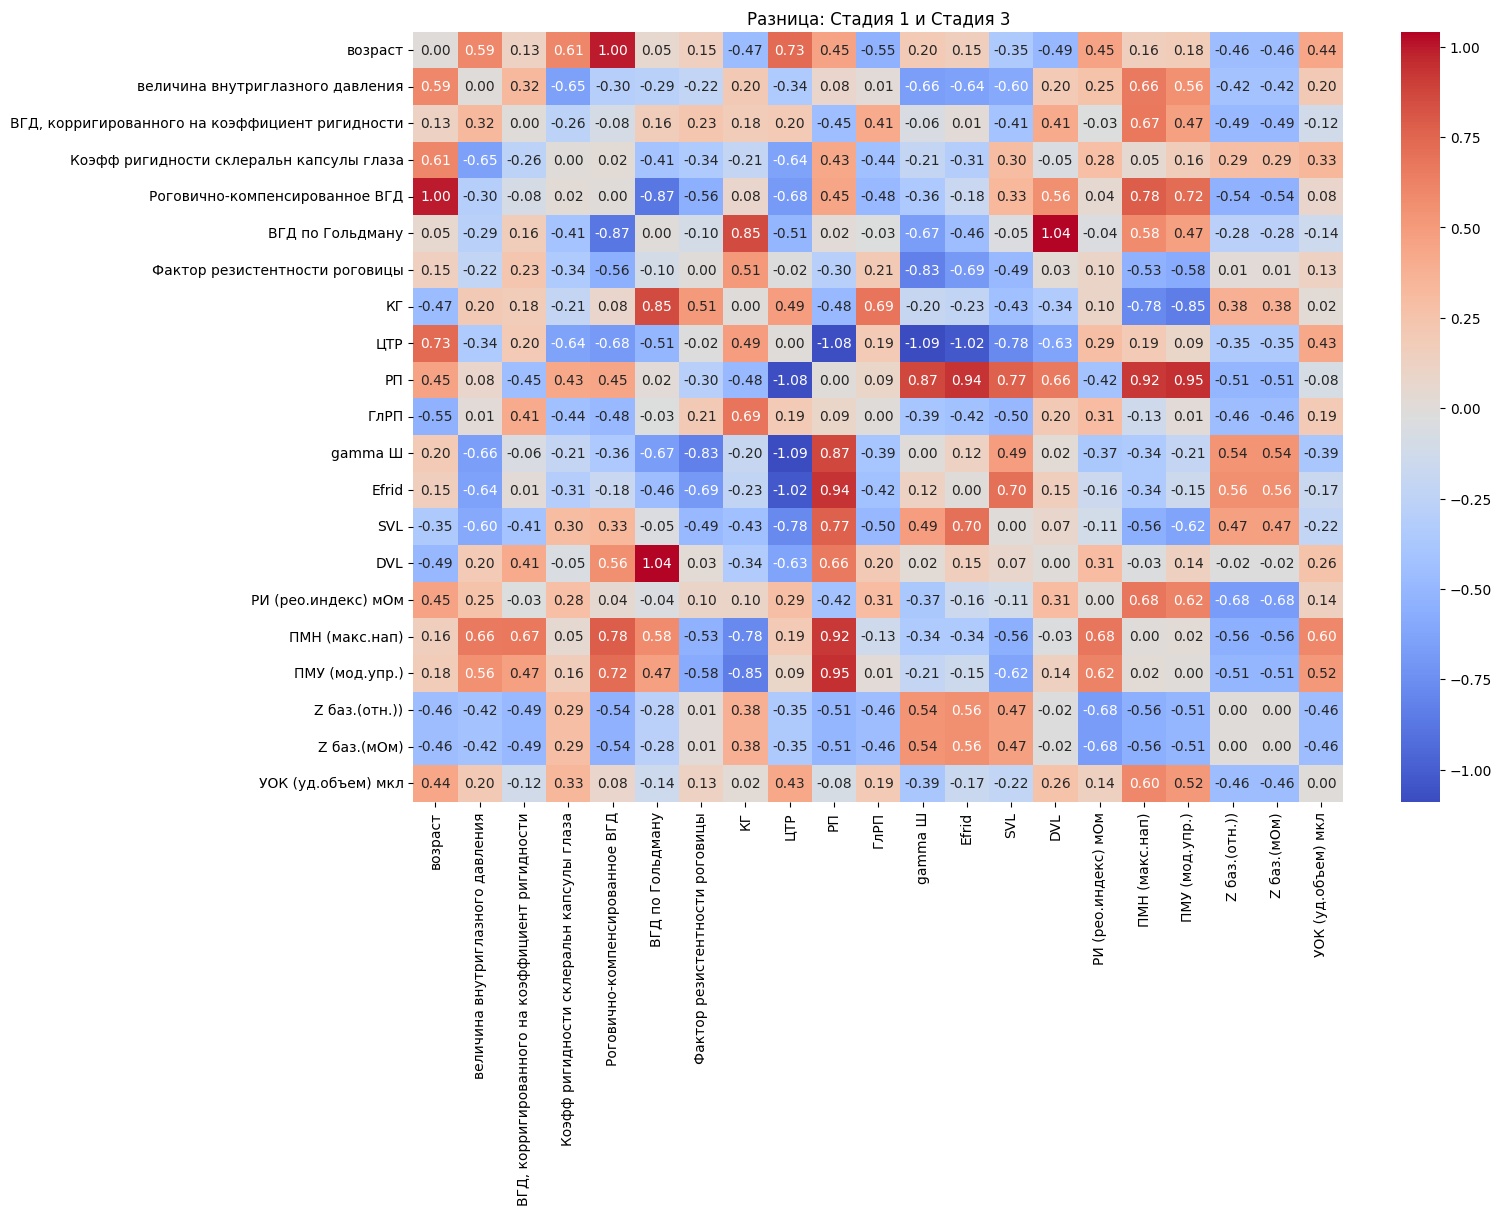

In [ ]:
diff = group_corrs[3] - group_corrs[1]
plot_corr_matrix(diff, "Разница: Стадия 1 и Стадия 3")

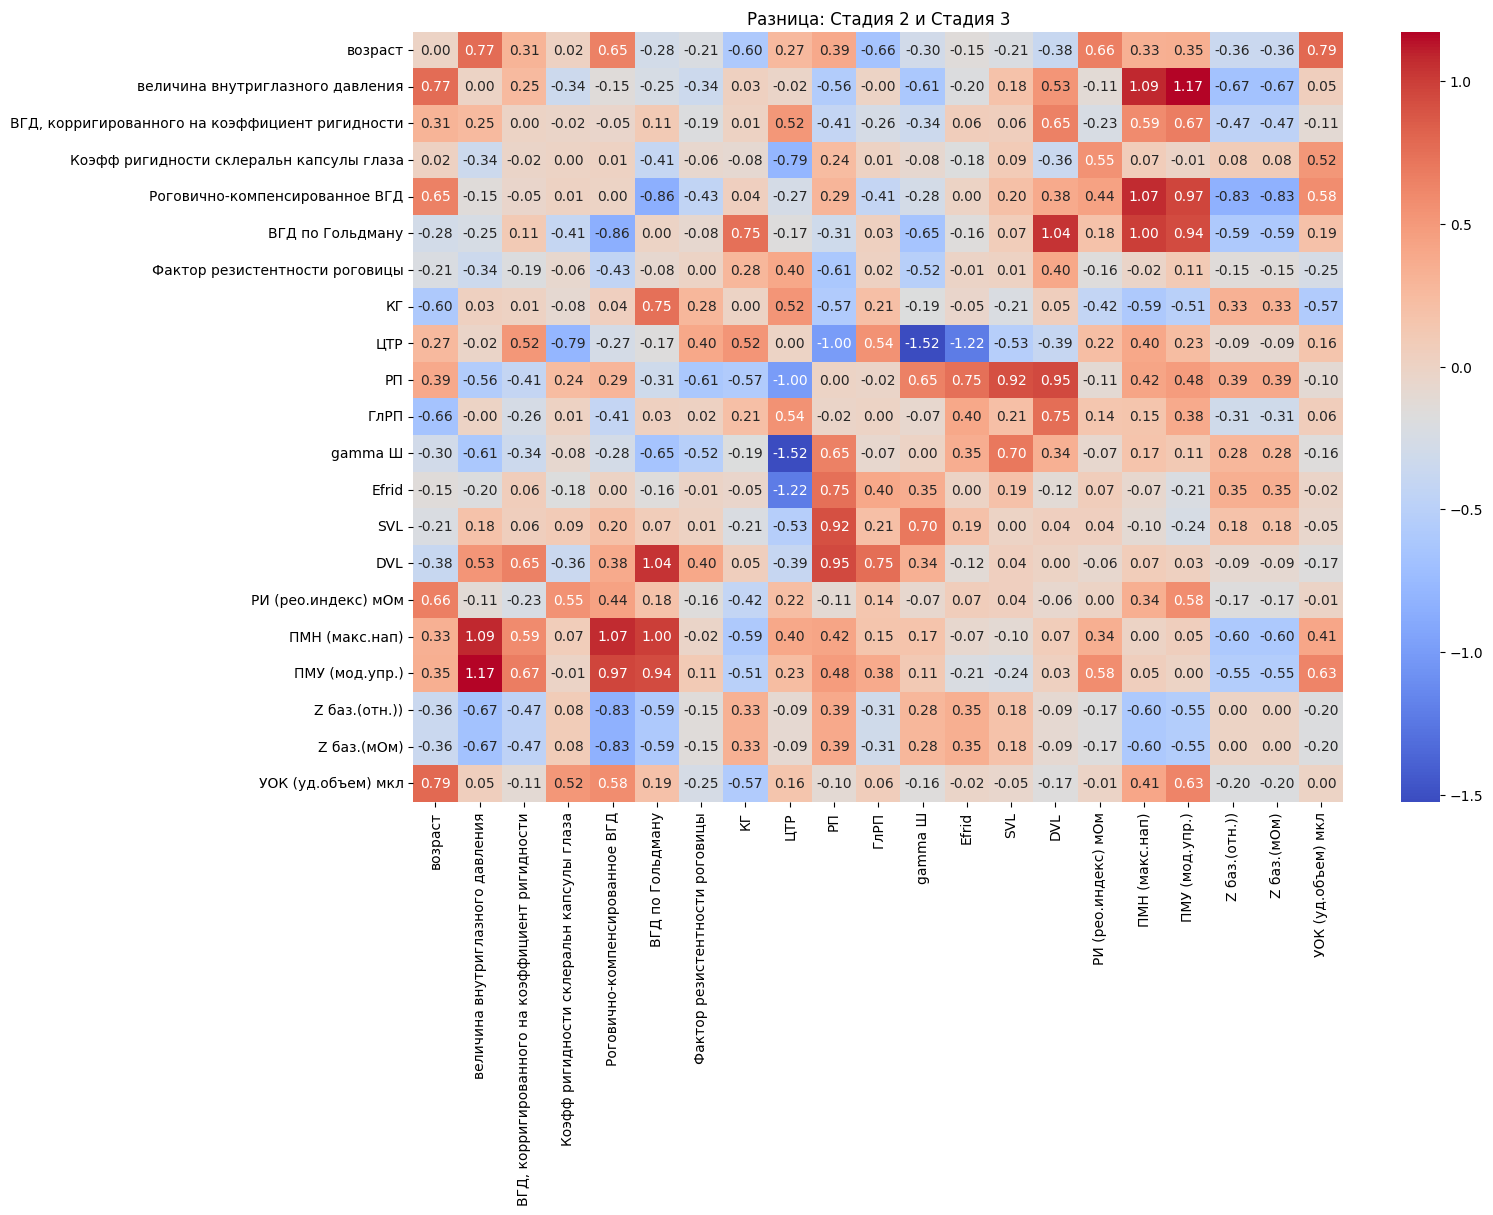

In [ ]:
diff = group_corrs[3] - group_corrs[2]
plot_corr_matrix(diff, "Разница: Стадия 2 и Стадия 3")

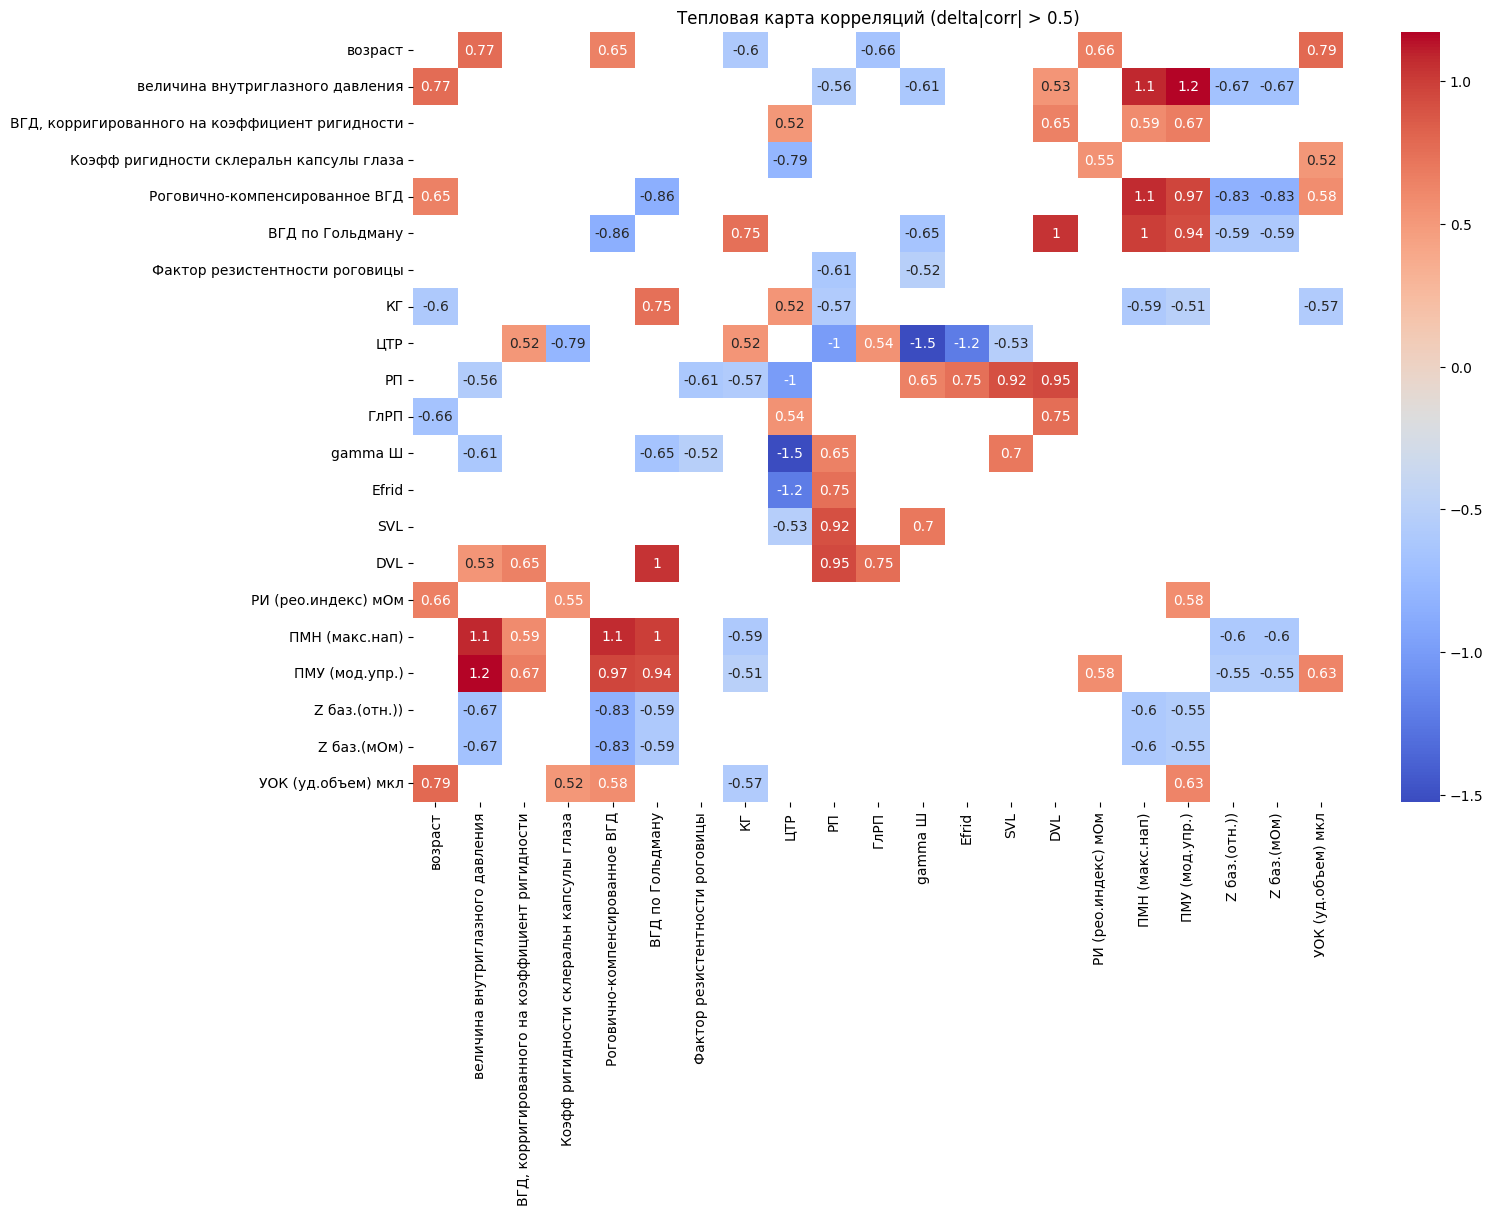

In [ ]:
filtered_diff = diff.copy()
filtered_diff[np.abs(filtered_diff) <= 0.5] = np.nan

#filtered_fiff = diff.where(diff >= 0.5)
plt.figure(figsize=(15, 10))
sns.heatmap(filtered_diff, annot=True, cmap='coolwarm',annot_kws={"size": 10}, cbar=True, mask=filtered_diff.isnull())
plt.title("Тепловая карта корреляций (delta|corr| > 0.5)")
plt.show()